In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import scipy.stats
import warnings
from scipy.stats import norm
warnings.filterwarnings("ignore")
pd.options.display.float_format = '{:.3f}'.format

import pmdarima as pm
import arch
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.forecasting.stl import STLForecast
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# 데이터 불러오기
original = pd.read_csv('c:\\python\\data2(filtered).csv', dtype={2: 'str'}).iloc[:,2:7]

original = original.reset_index(drop = True)
# 신고중량이 0으로 신고된 수입건 제외
original = original.drop(original[original['신고중량'] == 0].index)
# 1년간 수입한 일수가 100일 미만은 품목 제외
#year_ago = original['수리일자'].max() - 10000
#hs_hole = list(original[original['수리일자'] > year_ago]['HS10단위부호'].value_counts()[original[original['수리일자'] > year_ago]['HS10단위부호'].value_counts() < 100].index)
#original = original[~original['HS10단위부호'].isin(hs_hole)]

# 연도_주차 구하기
original['수리일자'] = original['수리일자'].astype(str)
original['수리일자'] = pd.to_datetime(original['수리일자'])
original['연도'] = original['수리일자'].dt.year
original['월'] = original['수리일자'].dt.month
original['주차'] = original['수리일자'].dt.isocalendar().week
original['연도주차'] = original['연도'] * 100 + original['주차']
original['연도주차'][(original['월'] == 1) & (original['주차'] > 5)] -= 100
original['연도주차'][(original['월'] == 12) & (original['주차'] < 5)] += 100
original['연도주차'] = original['연도주차'].apply(lambda x : str(x)[2:4] + '_' + str(x)[4:])

# 전체 연도_주차 데이터 생성
date_index = original['연도주차'].unique()
# 사용하는 컬럼 정리
use_col = ['HS10단위부호', '연도주차', '무역거래처국가코드', '신고중량', '과세가격미화금액']

p_eriod = -52

HS Code : 3102109000
      연도주차    단가         신고중량
0    17_04 0.255  5332959.546
1    17_05 0.262  6013912.829
2    17_06 0.266  5785572.955
3    17_07 0.274  6293268.930
4    17_08 0.273  5994605.184
..     ...   ...          ...
292  22_34 0.685 15555657.293
293  22_35 0.675 15785998.656
294  22_36 0.667 13272932.558
295  22_37 0.668 13644743.548
296  22_38 0.678  8370437.638

[297 rows x 3 columns]
21_40주차
0     5892192.336
1     8621320.361
2    10201257.261
3     8196479.362
4     6882415.227
5     8418110.158
6     7855938.056
7     8487338.055
8     8919522.904
9     4435313.673
10    6660056.188
11    6811887.337
12    7471432.525
13    7864346.467
14    5347890.630
15    7432961.455
16    8070404.966
17    8843312.073
18   10624074.923
19    8296150.698
20    8180610.250
21    8354064.775
22    8072254.700
23    8002639.450
24    8352437.450
25    8854407.613
26   10328720.263
27   11331233.588
28   10156752.738
29   10261927.073
30    9077961.354
31    8502465.854
32    86159

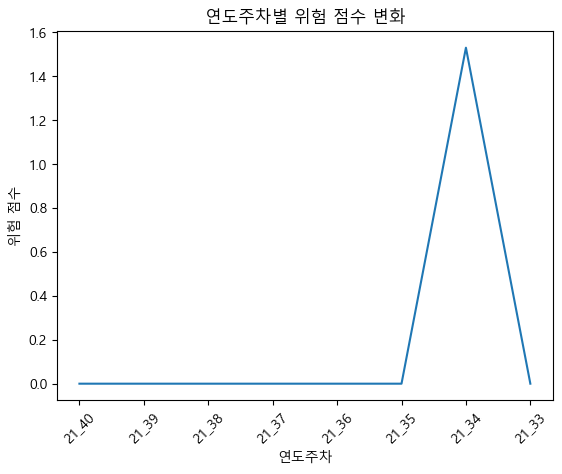

HS Code : 3707901010
      연도주차      단가      신고중량
0    17_04 219.044 17693.709
1    17_05 213.153 21010.400
2    17_06 216.113 19536.734
3    17_07 227.025 18619.221
4    17_08 223.977 18453.471
..     ...     ...       ...
292  22_34 414.585 19852.651
293  22_35 379.294 22915.441
294  22_36 378.936 22876.105
295  22_37 377.473 23998.908
296  22_38 338.724 23399.665

[297 rows x 3 columns]
19_30주차
0    23492.327
1    25873.863
2    23569.524
3    23905.783
4    22048.571
5    23912.596
6    22698.219
7    23856.776
8    21067.980
9    20785.282
10   27609.976
11   27166.385
12   30817.958
13   26050.878
14   22238.050
15   23637.975
16   22112.843
17   23692.447
18   24448.219
19   23265.845
20   26184.196
21   28616.635
22   23505.060
23   23269.247
24   24918.181
25   21452.173
26   26369.655
27   22313.457
28   21298.425
29   20713.954
30   15445.896
31   19374.191
32   17233.539
33   16416.350
34   18044.492
35   16707.494
36   16586.676
37   19796.508
38   21651.176
39   20952.854

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
19_29주차
0    23064.973
1    23492.327
2    25873.863
3    23569.524
4    23905.783
5    22048.571
6    23912.596
7    22698.219
8    23856.776
9    21067.980
10   20785.282
11   27609.976
12   27166.385
13   30817.958
14   26050.878
15   22238.050
16   23637.975
17   22112.843
18   23692.447
19   24448.219
20   23265.845
21   26184.196
22   28616.635
23   23505.060
24   23269.247
25   24918.181
26   21452.173
27   26369.655
28   22313.457
29   21298.425
30   20713.954
31   15445.896
32   19374.191
33   17233.539
34   16416.350
35   18044.492
36   16707.494
37   16586.676
38   19796.508
39   21651.176
40   20952.854
41   19916.705
42   17220.232
43   18771.470
44   21654.570
45   21445.539
46   22872.781
47   23106.035
48   21852.458
49   27028.711
50   30646.667
51   29881.932
Name: 신고중량, dtype: float64
======================= 여기부터 GARCH 모델링 ================================

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
19_27주차
0    21859.940
1    24197.684
2    23064.973
3    23492.327
4    25873.863
5    23569.524
6    23905.783
7    22048.571
8    23912.596
9    22698.219
10   23856.776
11   21067.980
12   20785.282
13   27609.976
14   27166.385
15   30817.958
16   26050.878
17   22238.050
18   23637.975
19   22112.843
20   23692.447
21   24448.219
22   23265.845
23   26184.196
24   28616.635
25   23505.060
26   23269.247
27   24918.181
28   21452.173
29   26369.655
30   22313.457
31   21298.425
32   20713.954
33   15445.896
34   19374.191
35   17233.539
36   16416.350
37   18044.492
38   16707.494
39   16586.676
40   19796.508
41   21651.176
42   20952.854
43   19916.705
44   17220.232
45   18771.470
46   21654.570
47   21445.539
48   22872.781
49   23106.035
50   21852.458
51   27028.711
Name: 신고중량, dtype: float64
======================= 여기부터 GARCH 모델링 ================================

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
19_23주차
0    20864.880
1    20625.178
2    20649.105
3    22119.247
4    21859.940
5    24197.684
6    23064.973
7    23492.327
8    25873.863
9    23569.524
10   23905.783
11   22048.571
12   23912.596
13   22698.219
14   23856.776
15   21067.980
16   20785.282
17   27609.976
18   27166.385
19   30817.958
20   26050.878
21   22238.050
22   23637.975
23   22112.843
24   23692.447
25   24448.219
26   23265.845
27   26184.196
28   28616.635
29   23505.060
30   23269.247
31   24918.181
32   21452.173
33   26369.655
34   22313.457
35   21298.425
36   20713.954
37   15445.896
38   19374.191
39   17233.539
40   16416.350
41   18044.492
42   16707.494
43   16586.676
44   19796.508
45   21651.176
46   20952.854
47   19916.705
48   17220.232
49   18771.470
50   21654.570
51   21445.539
Name: 신고중량, dtype: float64
======================= 여기부터 GARCH 모델링 ================================

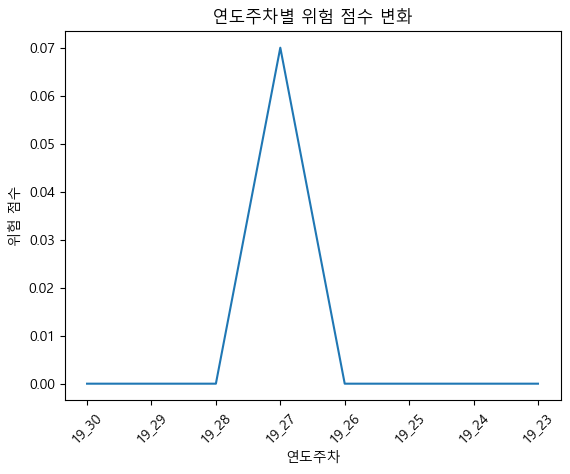

HS Code : 4407191000
      연도주차    단가       신고중량
0    17_04 1.321 239293.247
1    17_05 1.320 250460.747
2    17_06 1.335 267243.948
3    17_07 1.353 205743.000
4    17_08 1.355 166353.875
..     ...   ...        ...
292  22_34 1.459  46860.691
293  22_35 1.597  55567.169
294  22_36 1.587  60067.169
295  22_37 1.328  54362.169
296  22_38 1.313  49607.857

[297 rows x 3 columns]
21_14주차
0    232849.132
1    208142.443
2    212974.443
3    174660.487
4    192153.237
5    174147.462
6    208127.462
7    197927.225
8    169040.725
9    189372.250
10   165649.963
11   171324.713
12   171240.088
13   180231.838
14   141282.547
15   167364.547
16   177168.922
17   156222.672
18   213491.250
19   192786.750
20   188341.750
21   193563.500
22   174705.000
23   172996.750
24   184079.750
25   285911.500
26   259840.750
27   241460.250
28   269135.500
29   163658.500
30   178406.150
31   201221.900
32   191856.150
33   202767.150
34   214060.000
35   232524.750
36   251751.250
37   275461.250
38 

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_10주차
0    188889.978
1    240923.167
2    245405.167
3    255033.016
4    232849.132
5    208142.443
6    212974.443
7    174660.487
8    192153.237
9    174147.462
10   208127.462
11   197927.225
12   169040.725
13   189372.250
14   165649.963
15   171324.713
16   171240.088
17   180231.838
18   141282.547
19   167364.547
20   177168.922
21   156222.672
22   213491.250
23   192786.750
24   188341.750
25   193563.500
26   174705.000
27   172996.750
28   184079.750
29   285911.500
30   259840.750
31   241460.250
32   269135.500
33   163658.500
34   178406.150
35   201221.900
36   191856.150
37   202767.150
38   214060.000
39   232524.750
40   251751.250
41   275461.250
42   300222.750
43   298335.750
44   234772.250
45   256456.250
46   313227.000
47   288588.500
48   311393.500
49   230289.000
50   107791.719
51   123319.969
Name: 신고중량, dtype: float64
===================

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_08주차
0     94948.500
1    138382.343
2    188889.978
3    240923.167
4    245405.167
5    255033.016
6    232849.132
7    208142.443
8    212974.443
9    174660.487
10   192153.237
11   174147.462
12   208127.462
13   197927.225
14   169040.725
15   189372.250
16   165649.963
17   171324.713
18   171240.088
19   180231.838
20   141282.547
21   167364.547
22   177168.922
23   156222.672
24   213491.250
25   192786.750
26   188341.750
27   193563.500
28   174705.000
29   172996.750
30   184079.750
31   285911.500
32   259840.750
33   241460.250
34   269135.500
35   163658.500
36   178406.150
37   201221.900
38   191856.150
39   202767.150
40   214060.000
41   232524.750
42   251751.250
43   275461.250
44   300222.750
45   298335.750
46   234772.250
47   256456.250
48   313227.000
49   288588.500
50   311393.500
51   230289.000
Name: 신고중량, dtype: float64
===================

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


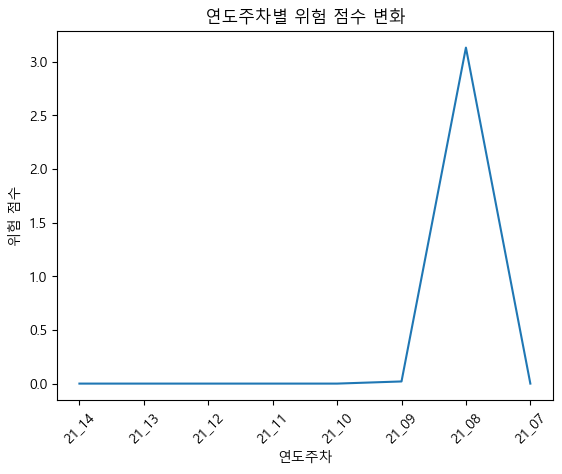

HS Code : 8111000000
      연도주차    단가        신고중량
0    17_04 2.294 1589538.823
1    17_05 2.322 1797062.025
2    17_06 2.349 2135029.125
3    17_07 2.255 2589847.688
4    17_08 2.222 2647460.135
..     ...   ...         ...
292  22_34 2.417 1887338.301
293  22_35 2.470 1322372.493
294  22_36 2.402 1172857.531
295  22_37 2.328 1437803.669
296  22_38 2.315  991759.689

[297 rows x 3 columns]
21_45주차
0    1838912.570
1    1881359.907
2    2331514.192
3    2123058.496
4    1726439.953
5    2127137.453
6    1450353.759
7    1715679.800
8    1913412.288
9    1845113.619
10   1992666.875
11   1927276.746
12   1775287.477
13   1647085.896
14   2087361.094
15   1930276.436
16   1892042.360
17   2327552.947
18   2080499.897
19   1978193.060
20   2013177.680
21   1261457.280
22   1229109.535
23   1599007.763
24   1391967.667
25   1454628.980
26   1914836.804
27   1866438.329
28   2335814.701
29   2427450.519
30   2029275.732
31   2095024.151
32   1781438.359
33   1602083.096
34   1677452.446
35  

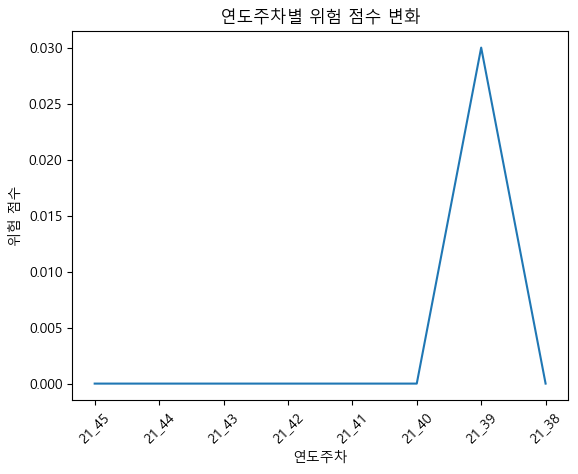

HS Code : 2701129010
      연도주차    단가          신고중량
0    17_04 0.177 163414532.500
1    17_05 0.183 128339537.000
2    17_06 0.187  77542167.000
3    17_07 0.178  87019096.075
4    17_08 0.165 107989167.275
..     ...   ...           ...
292  22_34 0.285 145518255.411
293  22_35 0.274 197342702.911
294  22_36 0.280 214007115.594
295  22_37 0.268 198569715.141
296  22_38 0.273 160074550.041

[297 rows x 3 columns]
21_51주차
0    225731607.798
1    183787999.567
2    224709651.750
3    202500680.500
4    217664043.000
5    242124105.935
6    234179063.435
7    209051809.935
8    270433729.435
9    246078410.135
10   236893702.635
11   274214557.385
12   221917945.020
13   306853383.385
14   279513383.385
15   233950465.885
16   161579432.000
17   130868025.000
18   197016285.000
19   204183060.500
20   221980002.213
21   208183477.213
22   153015439.713
23   199522831.713
24   238091066.250
25   252316802.250
26   277259142.250
27   250790692.250
28   204994413.750
29   171660050.312
30   

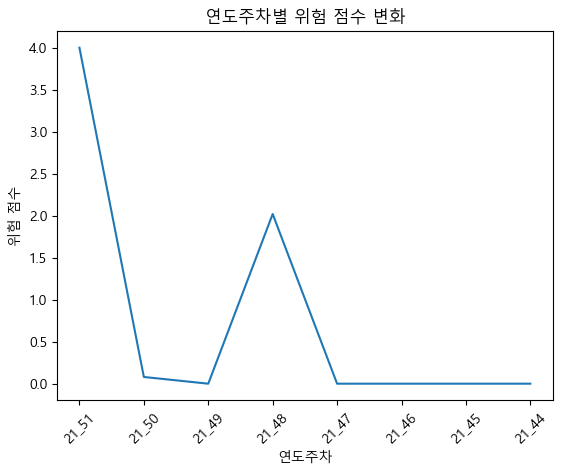

HS Code : 2804701000
      연도주차    단가       신고중량
0    17_04 2.811 160032.550
1    17_05 2.856 164322.550
2    17_06 2.862 142277.500
3    17_07 2.849 143690.000
4    17_08 2.827 128430.000
..     ...   ...        ...
292  22_34 7.502 144652.712
293  22_35 7.193 160465.212
294  22_36 7.270 198465.212
295  22_37 7.206 209505.000
296  22_38 7.230 164662.500

[297 rows x 3 columns]
21_51주차
0    254742.525
1    178310.470
2    196105.482
3    147182.957
4    187867.957
5    262452.513
6    280122.500
7    252057.500
8    253210.000
9    211705.000
10   222757.500
11   283655.000
12   246677.500
13   237352.500
14   224752.500
15   209272.500
16   171292.500
17   187030.000
18   150935.000
19   106027.500
20   161752.750
21   214187.750
22   202865.250
23   249897.750
24   274160.106
25   187000.106
26   197975.106
27   184582.606
28   152185.000
29   207612.500
30   225595.000
31   212912.506
32   234002.506
33   193567.506
34   283595.006
35   243605.000
36   201602.500
37   295390.000
38 

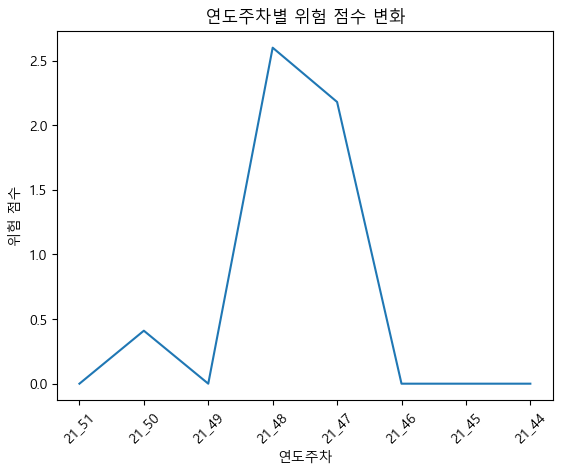

HS Code : 1511901000
      연도주차    단가        신고중량
0    17_04 0.735  936849.355
1    17_05 0.734  930738.055
2    17_06 0.754  893311.305
3    17_07 0.756 1637404.305
4    17_08 0.774 1212247.700
..     ...   ...         ...
292  22_34 1.468  759382.356
293  22_35 1.501  785201.626
294  22_36 1.488  774298.645
295  22_37 1.569  271958.020
296  22_38 1.391  698774.770

[297 rows x 3 columns]
22_02주차
0    1655937.250
1     901391.250
2     973333.000
3    1148300.000
4    1083733.000
5    1088981.800
6     763810.916
7    1151875.166
8    1176337.916
9    1176921.116
10   1216909.500
11    654403.250
12   1242982.505
13   1237151.685
14   1172861.685
15   1246969.185
16    993985.680
17   1034286.500
18   1033762.562
19    959130.562
20    998984.062
21    958687.062
22   1065545.500
23   1065545.000
24    106864.500
25    505444.000
26   1275959.425
27   1275959.425
28   1281584.425
29    987838.425
30    490000.475
31    495087.975
32    489462.975
33    564624.475
34   1008377.250
35  

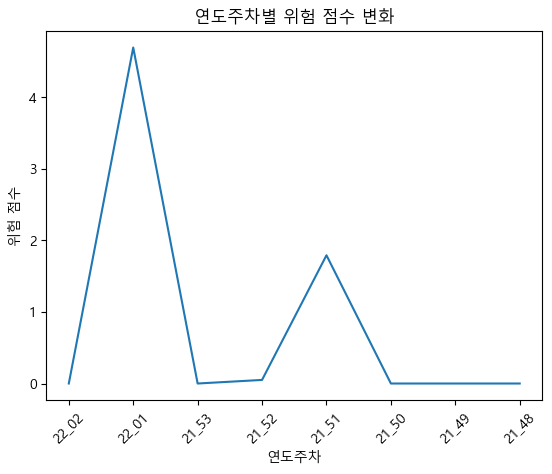

HS Code : 305531000
      연도주차     단가       신고중량
0    17_04 10.143 112739.000
1    17_05 10.020 106671.250
2    17_06  9.953 107973.500
3    17_07  9.665  98612.500
4    17_08  9.570  93437.500
..     ...    ...        ...
292  22_34 10.917 132790.114
293  22_35 10.543 146227.391
294  22_36 10.839 132587.659
295  22_37 10.828 108393.587
296  22_38 10.431  98649.147

[297 rows x 3 columns]
22_07주차
0     94605.349
1    119550.149
2    125476.449
3    146197.870
4    150753.546
5    140290.640
6    128867.112
7    114120.290
8    106992.423
9    101408.020
10   121817.874
11   125381.400
12   152749.953
13   164129.761
14   156312.136
15   155368.886
16   131997.200
17   147524.700
18   141420.950
19   163775.950
20   152476.650
21   135051.675
22   136310.425
23   121478.925
24   122820.025
25   123487.025
26   128552.833
27   134701.334
28   159496.571
29   138344.546
30   135972.598
31   134916.348
32   117055.535
33   141450.535
34   183725.625
35   217210.145
36   250383.895
37   253

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
22_05주차
0    127691.400
1    109895.575
2     94605.349
3    119550.149
4    125476.449
5    146197.870
6    150753.546
7    140290.640
8    128867.112
9    114120.290
10   106992.423
11   101408.020
12   121817.874
13   125381.400
14   152749.953
15   164129.761
16   156312.136
17   155368.886
18   131997.200
19   147524.700
20   141420.950
21   163775.950
22   152476.650
23   135051.675
24   136310.425
25   121478.925
26   122820.025
27   123487.025
28   128552.833
29   134701.334
30   159496.571
31   138344.546
32   135972.598
33   134916.348
34   117055.535
35   141450.535
36   183725.625
37   217210.145
38   250383.895
39   253445.520
40   217404.070
41   188713.705
42   170419.833
43   172665.066
44   163551.146
45   155913.791
46   110987.989
47   108721.130
48    89789.350
49   115454.990
50   129676.618
51   101362.868
Name: 신고중량, dtype: float64
===================

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_53주차
0    177167.290
1    144132.675
2    127121.125
3    144520.875
4    123379.325
5    127691.400
6    109895.575
7     94605.349
8    119550.149
9    125476.449
10   146197.870
11   150753.546
12   140290.640
13   128867.112
14   114120.290
15   106992.423
16   101408.020
17   121817.874
18   125381.400
19   152749.953
20   164129.761
21   156312.136
22   155368.886
23   131997.200
24   147524.700
25   141420.950
26   163775.950
27   152476.650
28   135051.675
29   136310.425
30   121478.925
31   122820.025
32   123487.025
33   128552.833
34   134701.334
35   159496.571
36   138344.546
37   135972.598
38   134916.348
39   117055.535
40   141450.535
41   183725.625
42   217210.145
43   250383.895
44   253445.520
45   217404.070
46   188713.705
47   170419.833
48   172665.066
49   163551.146
50   155913.791
51   110987.989
Name: 신고중량, dtype: float64
===================

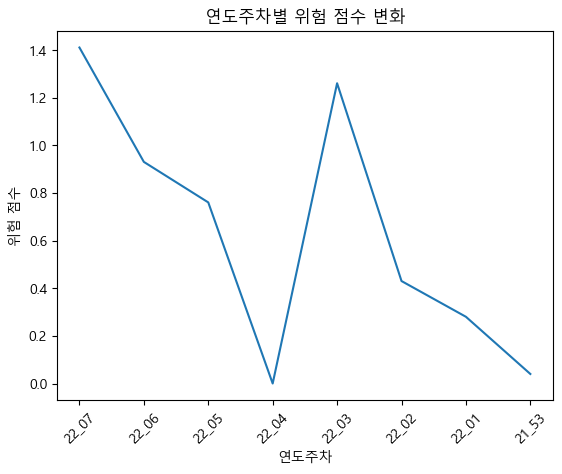

HS Code : 302140000
      연도주차     단가       신고중량
0    17_04 12.297 248997.765
1    17_05 11.776 247770.110
2    17_06 11.204 258943.758
3    17_07 10.781 262438.498
4    17_08 10.400 279016.205
..     ...    ...        ...
292  22_34 13.914 361472.777
293  22_35 13.643 378891.888
294  22_36 13.112 381338.341
295  22_37 12.738 381753.838
296  22_38 12.394 386434.054

[297 rows x 3 columns]
22_08주차
0    615575.662
1    615668.297
2    608740.494
3    627113.382
4    585409.915
5    590562.853
6    581756.949
7    566239.359
8    605266.935
9    607921.714
10   610291.216
11   587542.344
12   568714.768
13   554575.273
14   548016.885
15   551181.215
16   555615.528
17   545638.383
18   529042.071
19   525406.401
20   509545.128
21   500883.440
22   518561.440
23   510946.748
24   514015.178
25   528387.253
26   539033.973
27   631475.125
28   586985.324
29   629805.906
30   642438.201
31   577162.016
32   615438.152
33   569505.405
34   552960.362
35   549822.237
36   571503.554
37   590

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
22_03주차
0    560299.449
1    559853.442
2    567748.774
3    588090.171
4    590361.155
5    615575.662
6    615668.297
7    608740.494
8    627113.382
9    585409.915
10   590562.853
11   581756.949
12   566239.359
13   605266.935
14   607921.714
15   610291.216
16   587542.344
17   568714.768
18   554575.273
19   548016.885
20   551181.215
21   555615.528
22   545638.383
23   529042.071
24   525406.401
25   509545.128
26   500883.440
27   518561.440
28   510946.748
29   514015.178
30   528387.253
31   539033.973
32   631475.125
33   586985.324
34   629805.906
35   642438.201
36   577162.016
37   615438.152
38   569505.405
39   552960.362
40   549822.237
41   571503.554
42   590480.932
43   589051.338
44   565396.492
45   577042.093
46   601337.080
47   632981.690
48   507369.182
49   512505.143
50   475348.563
51   438346.065
Name: 신고중량, dtype: float64


c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
22_02주차
0    556900.944
1    560299.449
2    559853.442
3    567748.774
4    588090.171
5    590361.155
6    615575.662
7    615668.297
8    608740.494
9    627113.382
10   585409.915
11   590562.853
12   581756.949
13   566239.359
14   605266.935
15   607921.714
16   610291.216
17   587542.344
18   568714.768
19   554575.273
20   548016.885
21   551181.215
22   555615.528
23   545638.383
24   529042.071
25   525406.401
26   509545.128
27   500883.440
28   518561.440
29   510946.748
30   514015.178
31   528387.253
32   539033.973
33   631475.125
34   586985.324
35   629805.906
36   642438.201
37   577162.016
38   615438.152
39   569505.405
40   552960.362
41   549822.237
42   571503.554
43   590480.932
44   589051.338
45   565396.492
46   577042.093
47   601337.080
48   632981.690
49   507369.182
50   512505.143
51   475348.563
Name: 신고중량, dtype: float64
===================

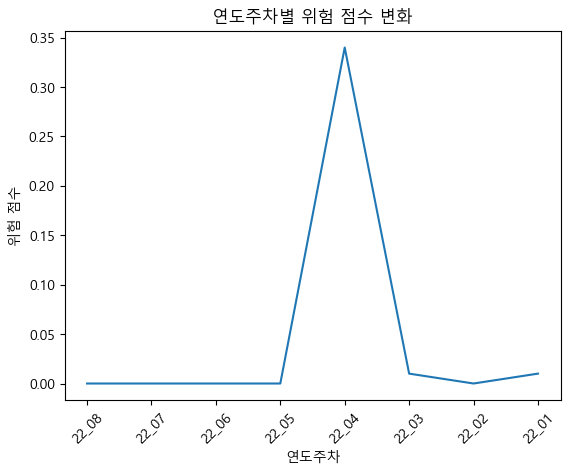

HS Code : 1003901000
      연도주차    단가        신고중량
0    17_04   NaN         NaN
1    17_05   NaN         NaN
2    17_06   NaN         NaN
3    17_07   NaN         NaN
4    17_08 0.288 1533750.000
..     ...   ...         ...
292  22_34 0.474  136245.000
293  22_35 0.442  384820.000
294  22_36 0.448  399849.500
295  22_37 0.461  360794.500
296  22_38 0.454  345794.500

[297 rows x 3 columns]
22_07주차
0     828835.000
1     717547.500
2     615187.500
3     411495.000
4     364135.000
5     267075.000
6     417842.500
7     604052.500
8     648885.000
9     808762.000
10    630552.000
11    520297.000
12    703284.500
13    697550.000
14    855198.250
15    934663.250
16    959354.500
17    805212.000
18    841536.250
19    820790.750
20    843592.000
21   1156483.500
22   1040701.000
23   1188999.000
24    856121.500
25    699435.000
26    543867.500
27    462302.500
28    874930.000
29    718725.000
30    873942.500
31    946175.000
32    533547.500
33    892700.000
34    944717.500
35  

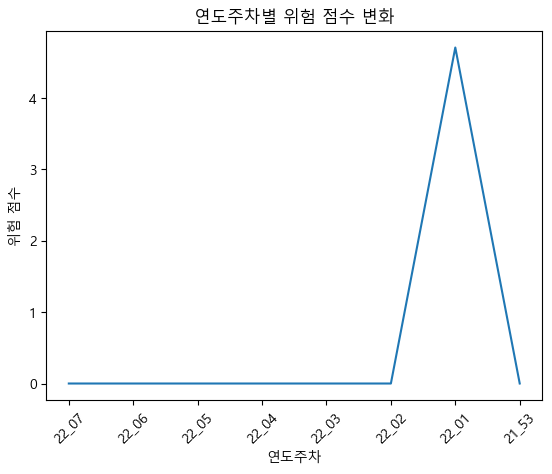

HS Code : 1003902000
      연도주차    단가        신고중량
0    17_04 0.192 3149912.500
1    17_05 0.192 3412412.500
2    17_06 0.192 2054420.000
3    17_07 0.192 1861815.000
4    17_08 0.192  354402.500
..     ...   ...         ...
292  22_34 0.383  183362.562
293  22_35 0.383  183362.562
294  22_36 0.366  116280.000
295  22_37 0.379   75557.500
296  22_38 0.379   75557.500

[297 rows x 3 columns]
22_07주차
0     869097.500
1     683327.500
2     269977.500
3     164995.000
4     298164.750
5     298164.750
6     266651.000
7     235016.000
8     249818.000
9     249818.000
10    249814.250
11    376146.750
12    252635.000
13    380320.000
14    380320.000
15    357498.000
16    360203.750
17    232518.975
18    232518.975
19    156960.975
20    225107.725
21    278897.500
22    278897.500
23    229272.500
24     96159.750
25     42369.750
26    216612.000
27    264614.500
28    347134.750
29    347134.750
30    227985.000
31    278295.000
32    244757.000
33    362449.500
34    340447.000
35  

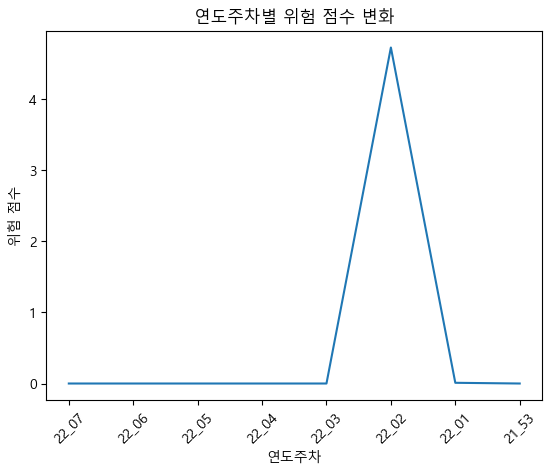

HS Code : 1104230000
      연도주차    단가       신고중량
0    17_04 0.389  38475.125
1    17_05 0.430 166375.125
2    17_06 0.477 415325.600
3    17_07 0.478 462700.475
4    17_08 0.475 537900.475
..     ...   ...        ...
292  22_34 0.451 446502.199
293  22_35 0.448 560500.000
294  22_36 0.447 413250.000
295  22_37 0.465 337250.000
296  22_38 0.473 231750.000

[297 rows x 3 columns]
22_07주차
0    432751.167
1    475500.542
2    323250.542
3    405750.000
4    345500.125
5    364500.125
6    295501.375
7    255501.375
8    341751.250
9    467001.250
10   424251.000
11   394501.000
12   285251.000
13    98251.000
14   131500.000
15   213750.000
16   237500.000
17   266000.000
18   300750.000
19   262750.000
20   206000.000
21   353250.000
22   485000.000
23   442250.000
24   418250.000
25   399250.000
26   213750.000
27   285000.000
28   285000.000
29   228000.000
30   285000.000
31   237500.000
32   280250.000
33   223250.000
34   180500.000
35   166251.350
36   294501.350
37   275501.350
38 

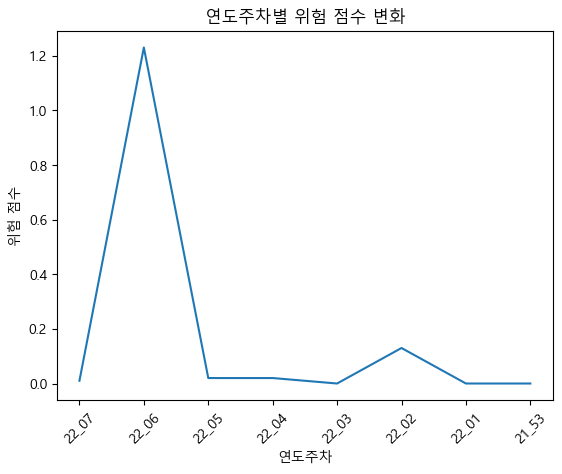

HS Code : 2710121000
      연도주차    단가         신고중량
0    17_04 0.551  2149886.250
1    17_05 0.550  4114309.500
2    17_06 0.549  6381111.750
3    17_07 0.549  4234150.250
4    17_08 0.547  9687853.750
..     ...   ...          ...
292  22_34 0.801 16626932.000
293  22_35 0.955  9728367.250
294  22_36 0.916  8810688.000
295  22_37 0.916  8810688.000
296  22_38 0.713 14231087.750

[297 rows x 3 columns]
22_07주차
0    12704250.250
1     5539971.250
2     5569408.000
3      177156.750
4     1138045.250
5     7136791.200
6     8301232.700
7    11013298.730
8    14520791.730
9     8523733.280
10   11248927.030
11    8536861.000
12    3920911.075
13    4805742.575
14    3517106.575
15    4965419.825
16    4965268.250
17    4274324.250
18    1866883.750
19     418570.500
20    1410867.750
21    9980065.750
22   10202026.250
23   10202026.250
24    9209729.000
25     444956.000
26    3372983.000
27    3372983.000
28    3461937.025
29    7450133.775
30    4077150.775
31    4080928.025
32    54850

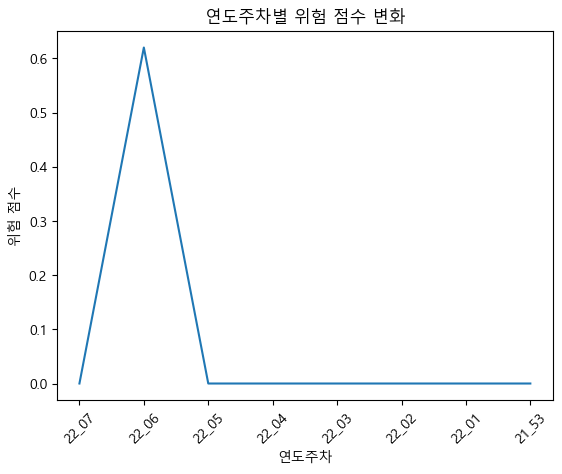

HS Code : 3104200000
      연도주차    단가         신고중량
0    17_04 0.299 11374102.375
1    17_05 0.298 16317880.400
2    17_06 0.291 12415604.100
3    17_07 0.291 10819745.700
4    17_08 0.289 11582318.950
..     ...   ...          ...
292  22_34 0.992 29386228.624
293  22_35 1.007  9666683.242
294  22_36 1.006  9627907.123
295  22_37 1.007  9785683.655
296  22_38 1.010  2767031.598

[297 rows x 3 columns]
22_07주차
0    10848408.987
1    10939364.025
2    17474054.190
3     9429601.715
4    23952649.830
5    23754948.883
6    16850661.767
7    17458618.276
8     3554086.133
9    12218383.606
10   12107366.281
11   11516935.784
12   10898136.424
13    2380387.074
14   12491971.349
15   13279410.200
16   21462436.948
17   21448138.023
18   18889077.523
19   32493832.810
20   27363068.125
21   28248164.212
22   19755683.589
23   12855464.362
24   11266343.705
25    8980520.543
26   15271725.124
27    8758476.601
28    8075621.746
29    8125543.596
30   15975057.496
31   15181597.234
32   145531

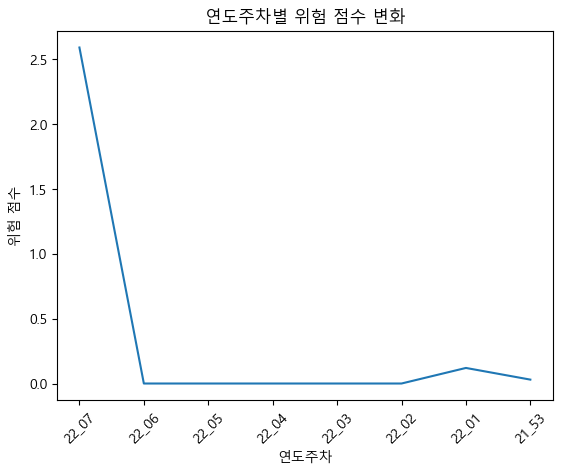

HS Code : 2905172000
      연도주차    단가       신고중량
0    17_04 1.801  49211.300
1    17_05 1.754  65983.925
2    17_06 1.838  79977.625
3    17_07 1.857  61760.131
4    17_08 1.863  63759.256
..     ...   ...        ...
292  22_34 3.054 100640.853
293  22_35 3.011 131752.708
294  22_36 2.871 136344.133
295  22_37 2.882  95667.133
296  22_38 2.817  62904.505

[297 rows x 3 columns]
22_16주차
0    104593.403
1    103831.328
2    105693.828
3     74423.258
4     78403.830
5     91800.905
6     79802.405
7     68082.700
8     95649.625
9     88584.375
10   110632.875
11   104293.025
12   106678.025
13    75903.300
14    97053.180
15   122183.780
16    87141.280
17   103501.257
18    70622.625
19    58022.625
20    50237.625
21    52562.625
22    61041.878
23    82435.753
24    99243.253
25    89308.001
26    96727.526
27    65742.525
28    58675.775
29    85142.028
30    74414.746
31    90915.052
32    90009.327
33    76833.325
34    97113.232
35    84427.926
36   100970.401
37   103185.761
38 

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
22_10주차
0    114662.050
1    105335.050
2     90309.875
3     77989.250
4     59863.625
5    102581.150
6    104593.403
7    103831.328
8    105693.828
9     74423.258
10    78403.830
11    91800.905
12    79802.405
13    68082.700
14    95649.625
15    88584.375
16   110632.875
17   104293.025
18   106678.025
19    75903.300
20    97053.180
21   122183.780
22    87141.280
23   103501.257
24    70622.625
25    58022.625
26    50237.625
27    52562.625
28    61041.878
29    82435.753
30    99243.253
31    89308.001
32    96727.526
33    65742.525
34    58675.775
35    85142.028
36    74414.746
37    90915.052
38    90009.327
39    76833.325
40    97113.232
41    84427.926
42   100970.401
43   103185.761
44    81704.994
45   108125.469
46   125458.219
47   123127.732
48   122870.850
49   106302.875
50    82512.625
51    82890.551
Name: 신고중량, dtype: float64
===================

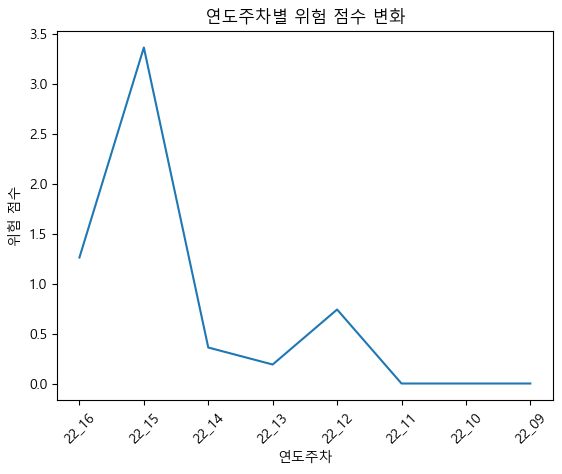

[np.float64(1.53), np.float64(0.07), np.float64(3.13), np.float64(0.03), np.float64(4.0), np.float64(2.6), np.float64(4.69), np.float64(1.41), np.float64(0.34), np.float64(4.71), np.float64(4.73), np.float64(1.23), np.float64(0.62), np.float64(2.59), np.float64(3.36)]
[57, 169, 83, 52, 40, 43, 37, 31, 34, 37, 36, 32, 32, 31, 23]


In [2]:
추출용 = [3102109000,3707901010,4407191000,8111000000,2701129010,2804701000,1511901000,305531000,302140000,1003901000,1003902000,1104230000,2710121000,3104200000,2905172000]
b = [59, 174, 85, 54, 48, 48, 44, 39, 38, 39, 39, 39, 39, 39, 30]

z = []
c = []
e = []
k = []
o = []
z_x = []
z_y = []

for i in range(0, len(추출용)):
  z.append(0) # 품목별 Highest CV를 반영하기 위해 List 생성
  c.append(0) # 품목별 CV값이 임계값 이상인 경우의 횟수를 반영하기 위한 List 생성
  k.append(0) # 임계값을 넘는 횟수
  o.append(0) # 위험경보 여부
  z_x.append(0) # Highest CV의 X값
  z_y.append(0) # Highest CV의 y값

for i in range(0, 8):
  e.append(0) # 품목별 8주간 CV값을 반영하기 위한 List 생성성
  
j = 0

for i in 추출용:
    print(f'HS Code : {i}')
    original[original['HS10단위부호'] == str(i)].sort_values(by = '수리일자', ascending = False)
    data = pd.DataFrame(columns = use_col)
    data = pd.concat([data, original[original['HS10단위부호'] == str(i)]])
    data = data.reset_index(drop=True)

    data = data.sort_values(by='수리일자', ascending=True).reset_index(drop=True)
    
    #
    ## 최근 52주간 수입단가(직전4주평균) 추이 파악
    #
    df_price = data[['연도주차', '과세가격미화금액', '신고중량']]
    df_price_week = df_price.groupby('연도주차')[['과세가격미화금액', '신고중량']].agg(['sum']).reset_index()
    df_price_week.columns = ['연도주차', '과세가격미화금액', '신고중량']


    # 수입이 없는 주차의 값을 0으로 생성
    df_price_week_hole = pd.DataFrame(columns = df_price_week.columns)
    for wk in set(date_index) - set(df_price_week['연도주차'].unique()):
        df_price_week_hole = pd.concat([df_price_week_hole, pd.DataFrame([{'연도주차': wk, '과세가격미화금액': 0, '신고중량': 0}])], ignore_index=True)
    df_price_week_total = pd.concat([df_price_week, df_price_week_hole]).sort_values('연도주차')

    # 해당 주차의 데이터를 직전 4주간 평균으로 대체
    price_w4 = []
    kg_w4 = []
    for x in range(0, len(df_price_week_total) - 3):
        price_w4.append(df_price_week_total[['과세가격미화금액']].iloc[x : x + 4].mean().iloc[0])
        kg_w4.append(df_price_week_total[['신고중량']].iloc[x : x + 4].mean().iloc[0])
    df_price_4w = df_price_week_total[3:]
    df_price_4w['과세가격미화금액'] = price_w4
    df_price_4w['신고중량'] = kg_w4
    df_price_4w = df_price_4w.reset_index(drop = True)
    df_price_4w['과세가격미화금액'] = df_price_4w['과세가격미화금액'].replace(0, np.nan).ffill()
    df_price_4w['신고중량'] = df_price_4w['신고중량'].replace(0, np.nan).ffill()
    df_price_4w['단가'] = df_price_4w['과세가격미화금액'] / df_price_4w['신고중량']
    df_price_4w = df_price_4w[['연도주차', '단가', '신고중량']]
    print(df_price_4w)
    
   
    for l in range(b[j]-8,b[j]):

        print(df_price_4w['연도주차'].iloc[-1-l] + '주차')
        #=================== 단가 percertile 구하기 ====================
        data_mean = df_price_4w.iloc[p_eriod-l:-l]['단가'].mean()
        data_std = df_price_4w.iloc[p_eriod-l:-l]['단가'].std()
        stand_quant = (df_price_4w.iloc[-1-l]['단가'] - data_mean) / data_std
        y=np.exp((scipy.stats.norm.cdf(stand_quant)*100 - 95)*np.log(5)/5)

      #=================== 신고중량 ======================
         
        res_resid = df_price_4w['신고중량'].iloc[p_eriod-l:-l]
        res_resid = res_resid.reset_index(drop=True)
        
        print(res_resid)
        n_test = 1
        
        train_y, test_y = res_resid[:-n_test], res_resid[-n_test:]

        model = SARIMAX(train_y, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12), 
                        enforce_stationarity=False, enforce_invertibility=False)
        model_fit = model.fit(disp=False)
        forecast1 = model_fit.forecast(steps=1)
                
        print('======================= 여기부터 GARCH 모델링 =================================')
        est_residuals = model_fit.resid
                
        # NaN 또는 inf가 있는 경우 제거하거나 대체
        est_residuals = est_residuals.replace([np.inf, -np.inf], np.nan)
        est_residuals = est_residuals.dropna()

        # GARCH에 적용
        if len(est_residuals) > 0:
            garch = arch.arch_model(est_residuals, vol="GARCH", p=1, q=1)
            garch_fit = garch.fit(disp="off", options={"maxiter": 1000})
        else:
            print("⚠ GARCH 입력 데이터가 부족합니다. 모델링 생략")
        
        print('=========== GARCH forecast =============')
        garch_forecast = garch_fit.forecast(horizon = n_test, reindex=True)
        garch_std = np.sqrt(garch_forecast.variance.iloc[-1,0])
        stand_quant = (test_y.iloc[0] - forecast1.iloc[0])/ garch_std

        if(scipy.stats.norm.cdf(stand_quant)>0.5):
            x=np.exp((scipy.stats.norm.cdf(stand_quant)*100 - 95)*np.log(5)/5)
        else:
            x=np.exp(((1-scipy.stats.norm.cdf(stand_quant))*100 - 95)*np.log(5)/5)
        
        e[(l-b[j]+8)] = round(2/(1/y+1/x), 2)
        if(round(2/(1/y+1/x), 2)>1.85):
            k[j] += 1
        if(z[j] < round(2/(1/y+1/x), 2)):
            z[j] = round(2/(1/y+1/x), 2)
            c[j] = l
            
        if(z_x[j] < x):
            z_x[j] = x
            
        if(z_y[j] < y):
            z_y[j] = y
      
    if(z[j]>1.85):
        o[j] = 1
 
    import matplotlib.font_manager as fm

    plt.rc('font', family='Malgun Gothic')  # Windows (맑은 고딕)
    plt.rc('axes', unicode_minus=False)  # 마이너스(-) 기호 깨짐 방지
    
    x_labels = [df_price_4w['연도주차'].iloc[-1-l] for l in range(b[j]-8,b[j])]  # x축 라벨 생성
    plt.plot(x_labels, e)  # x축을 연도주차 값으로 설정
    plt.xticks(rotation=45)  # x축 라벨 회전 (가독성 개선)
    plt.xlabel("연도주차")  # x축 제목 추가
    plt.ylabel("위험 점수")  # y축 제목 추가
    plt.title("연도주차별 위험 점수 변화")  # 그래프 제목 추가
    plt.show()
    
    j += 1
print(z)
print(c)


# 구글드라이브에 있는 엑셀 파일을 불러와서 점수결과 저장하기
collect = pd.read_excel('c:\python\Compare_Models.xlsx', sheet_name="점수")
collect = pd.DataFrame(collect)
collect.loc[:14, 'Model17(1)'] = o
collect.loc[15, 'Model17(1)'] = np.sum(o)
collect.loc[:14, 'Model17(2)'] = z
collect.loc[15, 'Model17(2)'] = np.mean(z)
collect.to_excel('c:\python\Compare_Models.xlsx', sheet_name="점수", index=False)

collect1 = pd.read_excel('c:\python\Collectroc(t).xlsx', sheet_name="점수")
collect1 = pd.DataFrame(collect1)
collect1.loc[:14, 'y_scores[18]'] = z
collect1.to_excel('c:\python\Collectroc(t).xlsx', sheet_name="점수", index=False)

collect2 = pd.read_excel('c:\python\Collectroc(x).xlsx', sheet_name="점수")
collect2 = pd.DataFrame(collect2)
collect2.loc[:14, 'y_scores[18]'] = z_x
collect2.to_excel('c:\python\Collectroc(x).xlsx', sheet_name="점수", index=False)

collect3 = pd.read_excel('c:\python\Collectroc(y).xlsx', sheet_name="점수")
collect3 = pd.DataFrame(collect3)
collect3.loc[:14, 'y_scores[18]'] = z_y
collect3.to_excel('c:\python\Collectroc(y).xlsx', sheet_name="점수", index=False)

HS Code : 3926909000
21_49주차
0    1819475.697
1    1759198.849
2    1702628.788
3    1772732.696
4    1801110.265
5    1942272.072
6    2063378.412
7    2135877.091
8    1910684.931
9    1698594.161
10   1497006.522
11   1216500.177
12   1387471.016
13   1557317.076
14   1733684.614
15   1946767.614
16   2011353.845
17   2040727.035
18   2103305.349
19   2129829.188
20   2062311.091
21   2044849.603
22   1955011.476
23   1939171.723
24   1918588.422
25   1881981.178
26   1850456.215
27   1771389.791
28   1784857.980
29   1773956.662
30   1795661.931
31   1861654.184
32   1857961.823
33   1846204.722
34   1896762.862
35   1794810.335
36   1869589.479
37   1878669.796
38   1893962.304
39   1966106.705
40   1759797.708
41   1856764.017
42   1732404.326
43   1697385.546
44   1834109.354
45   1785889.886
46   1913378.676
47   1930866.467
48   1985621.832
49   1947465.647
50   1929595.306
51   2031017.054
Name: 신고중량, dtype: float64
======================= 여기부터 GARCH 모델링 =====================

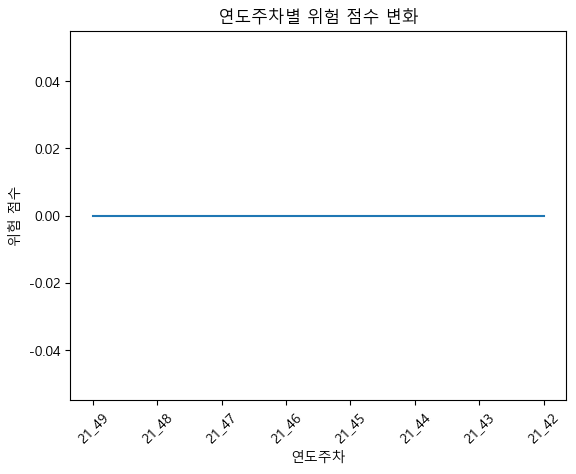

HS Code : 7326909000
21_49주차
0     9794627.961
1     9478324.210
2     9022161.538
3     9422341.837
4     8958114.316
5     9136034.447
6     9371354.125
7     9026954.088
8     8496187.737
9     8498653.435
10    7805880.210
11    7345828.460
12    7944217.924
13    8059489.703
14    9088337.616
15    9725865.154
16    9843348.104
17   10461909.664
18   10516870.233
19   10660959.379
20   10823314.582
21   10418023.225
22   10193539.467
23   10480084.041
24   10635030.073
25   10389724.092
26   10231758.284
27    9751462.372
28    9509626.703
29    9397969.806
30    9961440.152
31   10335565.766
32    9873671.660
33    9655675.481
34    9109766.998
35    8584630.329
36    9117232.692
37    9747339.496
38    9708618.958
39    9864434.209
40    8778994.153
41    8761410.720
42    8807710.327
43    8747199.427
44    9505631.447
45    9300774.848
46    9556558.352
47    9453523.929
48    9770830.761
49    9515615.696
50    9719919.951
51   10141052.744
Name: 신고중량, dtype: float64
========

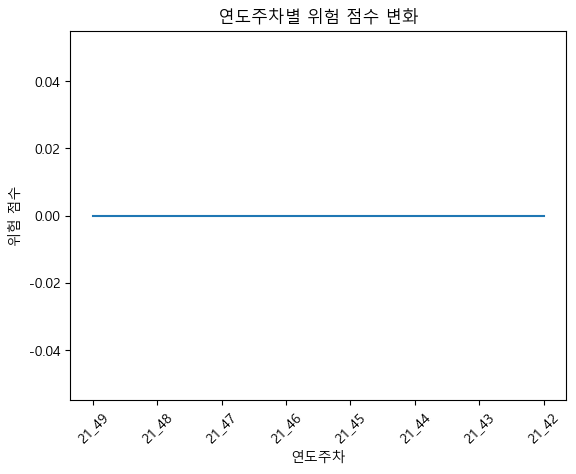

HS Code : 8708999000
21_49주차
0    1147660.053
1    1060236.535
2     997432.779
3    1080343.683
4    1058891.039
5    1151357.071
6    1199251.204
7    1138334.547
8    1048002.693
9    1046140.631
10    976627.393
11    894438.853
12   1077237.978
13   1113352.156
14   1229534.614
15   1307775.964
16   1180429.764
17   1155041.842
18   1090928.599
19   1038416.335
20   1024048.681
21    983070.550
22   1033698.270
23   1109445.525
24   1159773.967
25   1190345.384
26   1123803.251
27   1117668.599
28   1078423.856
29   1077162.885
30   1180097.572
31   1172265.875
32   1153859.640
33   1023783.038
34   1008650.690
35    993780.542
36   1059122.093
37   1185970.623
38   1103439.657
39   1080228.512
40    946105.909
41   1040592.970
42   1056417.755
43   1052176.844
44   1088443.171
45    983110.775
46   1034989.680
47    991276.171
48   1065242.159
49   1050623.024
50   1024759.462
51   1106171.440
Name: 신고중량, dtype: float64
======================= 여기부터 GARCH 모델링 =====================

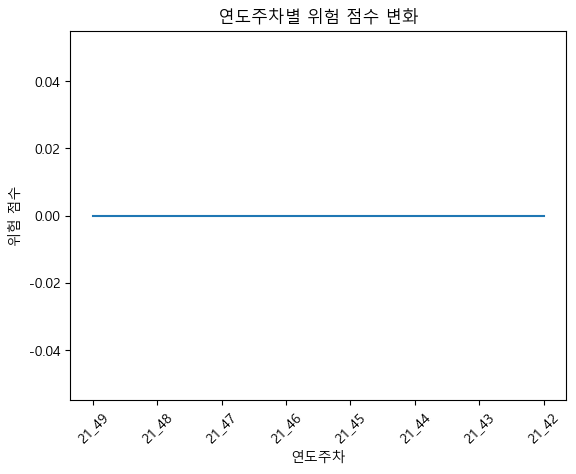

HS Code : 2106909099
21_49주차
0    1390671.633
1    1425981.735
2    1350678.512
3    1474688.966
4    1415681.133
5    1364841.412
6    1553107.167
7    1534554.360
8    1459785.140
9    1534417.363
10   1539912.319
11   1468109.150
12   1723540.423
13   1785415.611
14   1841932.449
15   1937097.027
16   1890610.736
17   1756093.744
18   1789778.667
19   1698466.847
20   1631714.081
21   1780501.389
22   1644895.390
23   1761011.467
24   1949838.122
25   1890891.464
26   1958184.733
27   1906565.297
28   1772892.223
29   1808104.031
30   1807024.343
31   1806961.038
32   1836575.289
33   1868881.091
34   1919855.379
35   1994051.698
36   1918346.347
37   1725725.437
38   1601808.376
39   1530774.596
40   1355010.495
41   1605566.474
42   1630927.086
43   1561069.045
44   1791972.254
45   1585092.786
46   1556211.379
47   1558201.960
48   1468454.774
49   1503518.564
50   1453456.416
51   1535941.930
Name: 신고중량, dtype: float64
======================= 여기부터 GARCH 모델링 =====================

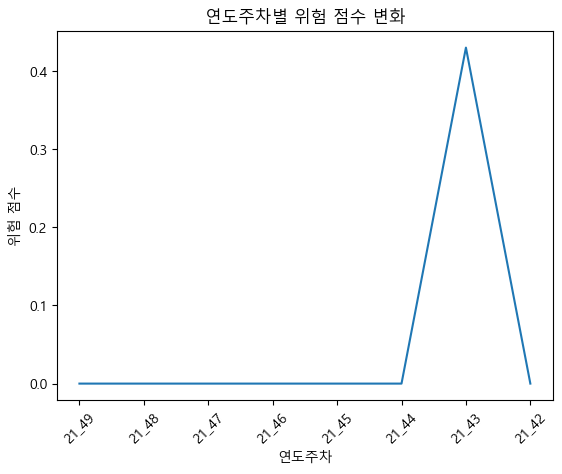

HS Code : 4911990000
21_49주차
0    31987.349
1    31920.607
2    31671.601
3    34234.887
4    31260.776
5    34954.207
6    47627.303
7    50995.766
8    45683.273
9    39107.184
10   35738.056
11   31846.155
12   30913.891
13   38750.404
14   34721.116
15   35188.926
16   37032.027
17   33044.941
18   42030.655
19   45695.521
20   42908.317
21   42501.615
22   34417.483
23   42464.689
24   43555.230
25   44156.331
26   42523.815
27   36675.460
28   36301.648
29   37859.513
30   39021.552
31   32634.367
32   33512.701
33   30641.472
34   35376.392
35   35386.881
36   38317.745
37   37702.641
38   29278.220
39   30673.554
40   33443.827
41   39760.620
42   41884.238
43   38732.110
44   36932.444
45   30671.492
46   38173.572
47   41700.433
48   43991.419
49   45769.655
50   38796.773
51   39028.844
Name: 신고중량, dtype: float64
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_48주차
0    24080.367
1    31987.349
2    31920.6

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_47주차
0    35547.719
1    24080.367
2    31987.349
3    31920.607
4    31671.601
5    34234.887
6    31260.776
7    34954.207
8    47627.303
9    50995.766
10   45683.273
11   39107.184
12   35738.056
13   31846.155
14   30913.891
15   38750.404
16   34721.116
17   35188.926
18   37032.027
19   33044.941
20   42030.655
21   45695.521
22   42908.317
23   42501.615
24   34417.483
25   42464.689
26   43555.230
27   44156.331
28   42523.815
29   36675.460
30   36301.648
31   37859.513
32   39021.552
33   32634.367
34   33512.701
35   30641.472
36   35376.392
37   35386.881
38   38317.745
39   37702.641
40   29278.220
41   30673.554
42   33443.827
43   39760.620
44   41884.238
45   38732.110
46   36932.444
47   30671.492
48   38173.572
49   41700.433
50   43991.419
51   45769.655
Name: 신고중량, dtype: float64
======================= 여기부터 GARCH 모델링 ================================

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


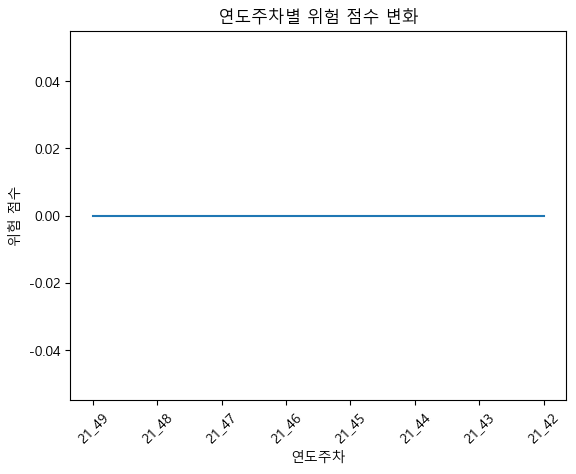

HS Code : 6403999000
21_49주차
0    198311.164
1    175366.949
2    152396.321
3    170796.983
4    167876.837
5    188928.668
6    211172.313
7    228826.520
8    226487.680
9    223980.398
10   192257.358
11   149261.509
12   152139.095
13   156269.393
14   187880.168
15   200660.488
16   205405.231
17   189411.643
18   176598.295
19   179478.138
20   176979.336
21   194145.809
22   205295.028
23   195456.959
24   212772.457
25   217841.734
26   218682.024
27   223989.285
28   199180.026
29   188918.611
30   179352.688
31   182767.727
32   188786.063
33   184185.342
34   192432.930
35   203234.962
36   205521.795
37   225247.443
38   217302.086
39   219814.068
40   212203.655
41   200144.419
42   214928.326
43   192098.482
44   186003.176
45   180867.923
46   174774.205
47   177966.628
48   192173.427
49   201199.847
50   198539.988
51   207957.862
Name: 신고중량, dtype: float64
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast ============

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_47주차
0    197149.150
1    199147.776
2    198311.164
3    175366.949
4    152396.321
5    170796.983
6    167876.837
7    188928.668
8    211172.313
9    228826.520
10   226487.680
11   223980.398
12   192257.358
13   149261.509
14   152139.095
15   156269.393
16   187880.168
17   200660.488
18   205405.231
19   189411.643
20   176598.295
21   179478.138
22   176979.336
23   194145.809
24   205295.028
25   195456.959
26   212772.457
27   217841.734
28   218682.024
29   223989.285
30   199180.026
31   188918.611
32   179352.688
33   182767.727
34   188786.063
35   184185.342
36   192432.930
37   203234.962
38   205521.795
39   225247.443
40   217302.086
41   219814.068
42   212203.655
43   200144.419
44   214928.326
45   192098.482
46   186003.176
47   180867.923
48   174774.205
49   177966.628
50   192173.427
51   201199.847
Name: 신고중량, dtype: float64
===================

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_44주차
0    129962.521
1    144262.954
2    169456.410
3    197149.150
4    199147.776
5    198311.164
6    175366.949
7    152396.321
8    170796.983
9    167876.837
10   188928.668
11   211172.313
12   228826.520
13   226487.680
14   223980.398
15   192257.358
16   149261.509
17   152139.095
18   156269.393
19   187880.168
20   200660.488
21   205405.231
22   189411.643
23   176598.295
24   179478.138
25   176979.336
26   194145.809
27   205295.028
28   195456.959
29   212772.457
30   217841.734
31   218682.024
32   223989.285
33   199180.026
34   188918.611
35   179352.688
36   182767.727
37   188786.063
38   184185.342
39   192432.930
40   203234.962
41   205521.795
42   225247.443
43   217302.086
44   219814.068
45   212203.655
46   200144.419
47   214928.326
48   192098.482
49   186003.176
50   180867.923
51   174774.205
Name: 신고중량, dtype: float64


c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_43주차
0    128461.305
1    129962.521
2    144262.954
3    169456.410
4    197149.150
5    199147.776
6    198311.164
7    175366.949
8    152396.321
9    170796.983
10   167876.837
11   188928.668
12   211172.313
13   228826.520
14   226487.680
15   223980.398
16   192257.358
17   149261.509
18   152139.095
19   156269.393
20   187880.168
21   200660.488
22   205405.231
23   189411.643
24   176598.295
25   179478.138
26   176979.336
27   194145.809
28   205295.028
29   195456.959
30   212772.457
31   217841.734
32   218682.024
33   223989.285
34   199180.026
35   188918.611
36   179352.688
37   182767.727
38   188786.063
39   184185.342
40   192432.930
41   203234.962
42   205521.795
43   225247.443
44   217302.086
45   219814.068
46   212203.655
47   200144.419
48   214928.326
49   192098.482
50   186003.176
51   180867.923
Name: 신고중량, dtype: float64


c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_42주차
0    158728.234
1    128461.305
2    129962.521
3    144262.954
4    169456.410
5    197149.150
6    199147.776
7    198311.164
8    175366.949
9    152396.321
10   170796.983
11   167876.837
12   188928.668
13   211172.313
14   228826.520
15   226487.680
16   223980.398
17   192257.358
18   149261.509
19   152139.095
20   156269.393
21   187880.168
22   200660.488
23   205405.231
24   189411.643
25   176598.295
26   179478.138
27   176979.336
28   194145.809
29   205295.028
30   195456.959
31   212772.457
32   217841.734
33   218682.024
34   223989.285
35   199180.026
36   188918.611
37   179352.688
38   182767.727
39   188786.063
40   184185.342
41   192432.930
42   203234.962
43   205521.795
44   225247.443
45   217302.086
46   219814.068
47   212203.655
48   200144.419
49   214928.326
50   192098.482
51   186003.176
Name: 신고중량, dtype: float64
===================

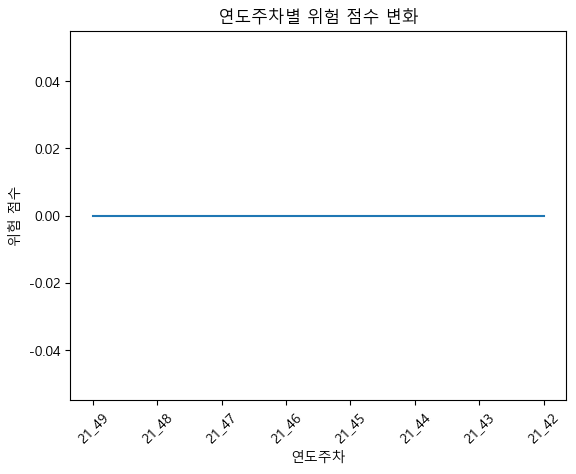

HS Code : 9031809099
21_49주차
0    159405.718
1    141906.169
2    123214.065
3    126757.859
4    128244.977
5    140214.064
6    155771.288
7    151962.699
8    137154.806
9    130821.274
10   129683.456
11   110399.881
12   125451.235
13   141869.405
14   143993.436
15   157473.529
16   154579.937
17   156843.965
18   197484.775
19   195251.764
20   196854.655
21   188420.641
22   142856.363
23   137485.545
24   154333.737
25   143744.136
26   152436.631
27   171015.941
28   185553.374
29   197324.026
30   197407.913
31   186206.204
32   137341.897
33   117648.834
34   114618.603
35   107369.644
36   123654.412
37   147558.789
38   144334.777
39   159664.859
40   154787.597
41   166204.231
42   164067.074
43   156857.698
44   156343.535
45   135971.268
46   154007.791
47   139872.852
48   146089.369
49   152011.951
50   135723.514
51   145023.962
Name: 신고중량, dtype: float64
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast ============

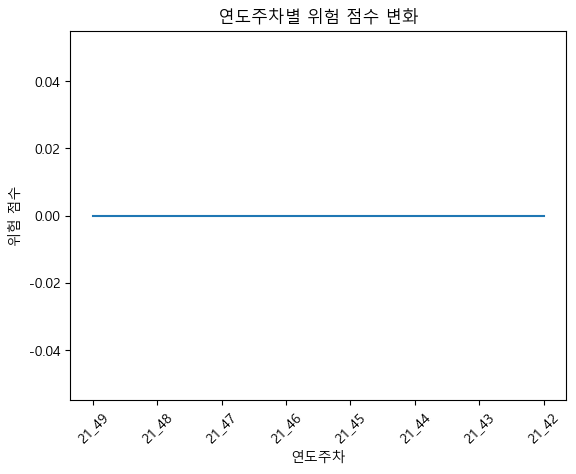

HS Code : 8542391000
21_49주차
0    63850.649
1    60700.283
2    54490.840
3    53577.814
4    53873.643
5    58031.125
6    63704.304
7    64717.662
8    61313.521
9    56214.816
10   57786.492
11   56139.240
12   60781.844
13   65919.997
14   65911.369
15   68338.959
16   66497.641
17   69192.029
18   68168.037
19   68613.718
20   69126.845
21   66327.720
22   66368.793
23   66461.467
24   70040.871
25   69350.386
26   67404.706
27   66710.575
28   64802.143
29   65727.213
30   67994.939
31   66357.801
32   64729.049
33   62670.979
34   62764.928
35   61666.443
36   63515.818
37   64609.687
38   63312.367
39   65664.024
40   58722.211
41   66125.856
42   63802.615
43   60651.957
44   66794.558
45   62136.644
46   66518.878
47   68799.376
48   67955.561
49   65520.139
50   66154.036
51   67221.632
Name: 신고중량, dtype: float64


c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_48주차
0    62889.529
1    63850.649
2    60700.283
3    54490.840
4    53577.814
5    53873.643
6    58031.125
7    63704.304
8    64717.662
9    61313.521
10   56214.816
11   57786.492
12   56139.240
13   60781.844
14   65919.997
15   65911.369
16   68338.959
17   66497.641
18   69192.029
19   68168.037
20   68613.718
21   69126.845
22   66327.720
23   66368.793
24   66461.467
25   70040.871
26   69350.386
27   67404.706
28   66710.575
29   64802.143
30   65727.213
31   67994.939
32   66357.801
33   64729.049
34   62670.979
35   62764.928
36   61666.443
37   63515.818
38   64609.687
39   63312.367
40   65664.024
41   58722.211
42   66125.856
43   63802.615
44   60651.957
45   66794.558
46   62136.644
47   66518.878
48   68799.376
49   67955.561
50   65520.139
51   66154.036
Name: 신고중량, dtype: float64


c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_47주차
0    60032.578
1    62889.529
2    63850.649
3    60700.283
4    54490.840
5    53577.814
6    53873.643
7    58031.125
8    63704.304
9    64717.662
10   61313.521
11   56214.816
12   57786.492
13   56139.240
14   60781.844
15   65919.997
16   65911.369
17   68338.959
18   66497.641
19   69192.029
20   68168.037
21   68613.718
22   69126.845
23   66327.720
24   66368.793
25   66461.467
26   70040.871
27   69350.386
28   67404.706
29   66710.575
30   64802.143
31   65727.213
32   67994.939
33   66357.801
34   64729.049
35   62670.979
36   62764.928
37   61666.443
38   63515.818
39   64609.687
40   63312.367
41   65664.024
42   58722.211
43   66125.856
44   63802.615
45   60651.957
46   66794.558
47   62136.644
48   66518.878
49   68799.376
50   67955.561
51   65520.139
Name: 신고중량, dtype: float64


c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_46주차
0    58544.978
1    60032.578
2    62889.529
3    63850.649
4    60700.283
5    54490.840
6    53577.814
7    53873.643
8    58031.125
9    63704.304
10   64717.662
11   61313.521
12   56214.816
13   57786.492
14   56139.240
15   60781.844
16   65919.997
17   65911.369
18   68338.959
19   66497.641
20   69192.029
21   68168.037
22   68613.718
23   69126.845
24   66327.720
25   66368.793
26   66461.467
27   70040.871
28   69350.386
29   67404.706
30   66710.575
31   64802.143
32   65727.213
33   67994.939
34   66357.801
35   64729.049
36   62670.979
37   62764.928
38   61666.443
39   63515.818
40   64609.687
41   63312.367
42   65664.024
43   58722.211
44   66125.856
45   63802.615
46   60651.957
47   66794.558
48   62136.644
49   66518.878
50   68799.376
51   67955.561
Name: 신고중량, dtype: float64
======================= 여기부터 GARCH 모델링 ================================

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_43주차
0    59766.603
1    59326.701
2    58986.152
3    58544.978
4    60032.578
5    62889.529
6    63850.649
7    60700.283
8    54490.840
9    53577.814
10   53873.643
11   58031.125
12   63704.304
13   64717.662
14   61313.521
15   56214.816
16   57786.492
17   56139.240
18   60781.844
19   65919.997
20   65911.369
21   68338.959
22   66497.641
23   69192.029
24   68168.037
25   68613.718
26   69126.845
27   66327.720
28   66368.793
29   66461.467
30   70040.871
31   69350.386
32   67404.706
33   66710.575
34   64802.143
35   65727.213
36   67994.939
37   66357.801
38   64729.049
39   62670.979
40   62764.928
41   61666.443
42   63515.818
43   64609.687
44   63312.367
45   65664.024
46   58722.211
47   66125.856
48   63802.615
49   60651.957
50   66794.558
51   62136.644
Name: 신고중량, dtype: float64
======================= 여기부터 GARCH 모델링 ================================

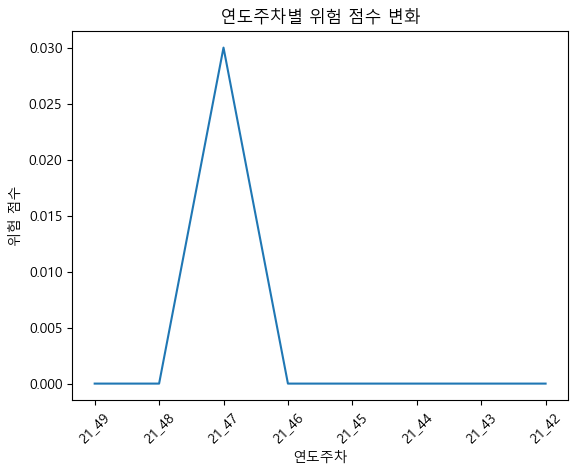

HS Code : 6109101000
21_49주차
0    236235.962
1    249461.332
2    257769.357
3    347943.414
4    374962.800
5    440008.921
6    492790.831
7    496272.931
8    502448.792
9    556054.944
10   618732.455
11   604435.674
12   665011.716
13   712068.731
14   715810.698
15   872650.426
16   939812.717
17   928789.693
18   948204.910
19   882514.715
20   807553.246
21   742778.464
22   693137.735
23   616960.170
24   598763.631
25   618013.041
26   578206.952
27   516612.442
28   477899.593
29   433605.195
30   414416.509
31   416730.944
32   399856.540
33   354893.190
34   364071.580
35   350954.751
36   322802.760
37   328195.826
38   298013.337
39   302975.294
40   284270.597
41   285894.570
42   275910.890
43   247733.421
44   258139.695
45   234853.324
46   246033.362
47   244611.004
48   236942.482
49   226831.598
50   220407.882
51   222357.802
Name: 신고중량, dtype: float64
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast ============

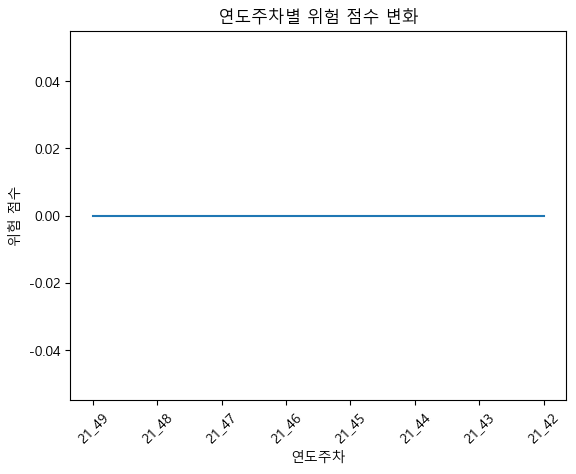

HS Code : 2934996000
21_49주차
0    18821.383
1    18862.281
2    15048.863
3    18815.891
4     7939.427
5     7909.596
6     7988.876
7    24979.876
8    25106.271
9    28840.466
10   35379.893
11   14619.165
12   10737.063
13   11520.767
14   16077.730
15   19829.516
16   22395.917
17   17856.616
18   24042.410
19   24064.265
20   22490.047
21   33740.466
22   20222.153
23   19011.696
24   19208.707
25   23707.086
26   23735.447
27   25083.470
28   23931.782
29    8168.822
30   16122.345
31   13146.499
32   13098.660
33   13099.198
34    5096.711
35    4156.396
36   20414.128
37   20403.587
38   16699.682
39   18103.931
40    1846.871
41   11630.620
42   15298.976
43   14043.247
44   14100.284
45    4422.167
46   10853.736
47   14521.340
48   18280.420
49   32932.036
50   26736.364
51   31285.905
Name: 신고중량, dtype: float64
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_48주차
0    17366.822
1    18821.383
2    18862.2

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_45주차
0    26142.180
1    22404.916
2    21163.375
3    17366.822
4    18821.383
5    18862.281
6    15048.863
7    18815.891
8     7939.427
9     7909.596
10    7988.876
11   24979.876
12   25106.271
13   28840.466
14   35379.893
15   14619.165
16   10737.063
17   11520.767
18   16077.730
19   19829.516
20   22395.917
21   17856.616
22   24042.410
23   24064.265
24   22490.047
25   33740.466
26   20222.153
27   19011.696
28   19208.707
29   23707.086
30   23735.447
31   25083.470
32   23931.782
33    8168.822
34   16122.345
35   13146.499
36   13098.660
37   13099.198
38    5096.711
39    4156.396
40   20414.128
41   20403.587
42   16699.682
43   18103.931
44    1846.871
45   11630.620
46   15298.976
47   14043.247
48   14100.284
49    4422.167
50   10853.736
51   14521.340
Name: 신고중량, dtype: float64
======================= 여기부터 GARCH 모델링 ================================

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_42주차
0    18375.873
1    14844.505
2    18603.185
3    26142.180
4    22404.916
5    21163.375
6    17366.822
7    18821.383
8    18862.281
9    15048.863
10   18815.891
11    7939.427
12    7909.596
13    7988.876
14   24979.876
15   25106.271
16   28840.466
17   35379.893
18   14619.165
19   10737.063
20   11520.767
21   16077.730
22   19829.516
23   22395.917
24   17856.616
25   24042.410
26   24064.265
27   22490.047
28   33740.466
29   20222.153
30   19011.696
31   19208.707
32   23707.086
33   23735.447
34   25083.470
35   23931.782
36    8168.822
37   16122.345
38   13146.499
39   13098.660
40   13099.198
41    5096.711
42    4156.396
43   20414.128
44   20403.587
45   16699.682
46   18103.931
47    1846.871
48   11630.620
49   15298.976
50   14043.247
51   14100.284
Name: 신고중량, dtype: float64
======================= 여기부터 GARCH 모델링 ================================

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


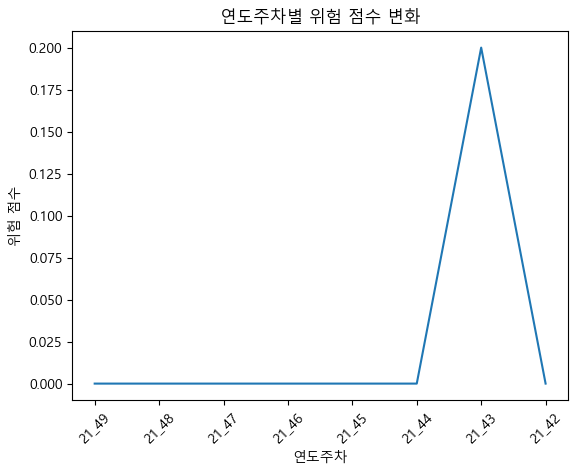

HS Code : 4016930000
21_49주차
0    100267.242
1     99946.791
2     97372.175
3     92455.967
4     94689.610
5     98809.827
6    104727.600
7    118160.091
8    112979.570
9     99891.753
10    92513.230
11    78766.203
12    80476.561
13    86805.219
14    93231.855
15    97816.822
16    94632.125
17    91410.564
18    83980.870
19    92772.956
20    91332.883
21    98136.791
22    97795.592
23    84961.463
24    88424.403
25    87811.152
26    92481.733
27    93346.291
28    96319.930
29    89162.166
30    89937.742
31    92982.405
32    85868.084
33    76576.080
34    85049.873
35    78698.679
36    79619.849
37    82744.229
38    70493.739
39    76204.696
40    68148.034
41    81537.011
42    77189.122
43    73995.291
44    79867.820
45    68833.236
46    71708.041
47    79219.858
48    87393.748
49    83756.169
50    99139.198
51    93992.402
Name: 신고중량, dtype: float64
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast ============

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_46주차
0    108444.327
1    104504.576
2     98283.787
3    100267.242
4     99946.791
5     97372.175
6     92455.967
7     94689.610
8     98809.827
9    104727.600
10   118160.091
11   112979.570
12    99891.753
13    92513.230
14    78766.203
15    80476.561
16    86805.219
17    93231.855
18    97816.822
19    94632.125
20    91410.564
21    83980.870
22    92772.956
23    91332.883
24    98136.791
25    97795.592
26    84961.463
27    88424.403
28    87811.152
29    92481.733
30    93346.291
31    96319.930
32    89162.166
33    89937.742
34    92982.405
35    85868.084
36    76576.080
37    85049.873
38    78698.679
39    79619.849
40    82744.229
41    70493.739
42    76204.696
43    68148.034
44    81537.011
45    77189.122
46    73995.291
47    79867.820
48    68833.236
49    71708.041
50    79219.858
51    87393.748
Name: 신고중량, dtype: float64
===================

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_42주차
0     86449.324
1     92859.179
2    101207.066
3    103475.251
4    108444.327
5    104504.576
6     98283.787
7    100267.242
8     99946.791
9     97372.175
10    92455.967
11    94689.610
12    98809.827
13   104727.600
14   118160.091
15   112979.570
16    99891.753
17    92513.230
18    78766.203
19    80476.561
20    86805.219
21    93231.855
22    97816.822
23    94632.125
24    91410.564
25    83980.870
26    92772.956
27    91332.883
28    98136.791
29    97795.592
30    84961.463
31    88424.403
32    87811.152
33    92481.733
34    93346.291
35    96319.930
36    89162.166
37    89937.742
38    92982.405
39    85868.084
40    76576.080
41    85049.873
42    78698.679
43    79619.849
44    82744.229
45    70493.739
46    76204.696
47    68148.034
48    81537.011
49    77189.122
50    73995.291
51    79867.820
Name: 신고중량, dtype: float64
===================

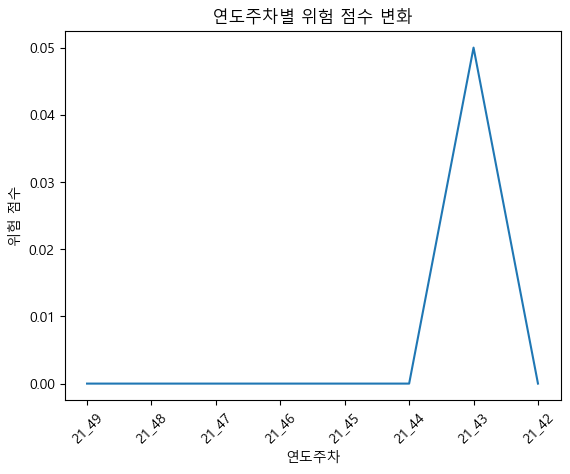

HS Code : 6110200000
21_49주차
0    299498.548
1    275640.367
2    297390.431
3    345911.408
4    363089.810
5    410319.862
6    437522.196
7    399271.177
8    377510.736
9    348515.607
10   285424.524
11   224653.800
12   196720.530
13   171201.544
14   151640.493
15   150454.720
16   127296.838
17   113382.112
18   106552.030
19    88683.924
20    78035.576
21    71602.144
22    76149.564
23    73984.084
24    82991.325
25    98366.740
26    93972.626
27   113234.487
28   150542.702
29   167251.436
30   218450.401
31   257252.360
32   318330.466
33   349277.878
34   413485.334
35   433176.196
36   440033.079
37   485690.108
38   516623.422
39   588906.316
40   557804.868
41   584349.055
42   527365.771
43   470512.983
44   510904.485
45   468842.053
46   467987.442
47   439229.849
48   383991.080
49   381517.140
50   390321.410
51   402581.720
Name: 신고중량, dtype: float64
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast ============

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_46주차
0    294241.149
1    274341.984
2    290656.063
3    299498.548
4    275640.367
5    297390.431
6    345911.408
7    363089.810
8    410319.862
9    437522.196
10   399271.177
11   377510.736
12   348515.607
13   285424.524
14   224653.800
15   196720.530
16   171201.544
17   151640.493
18   150454.720
19   127296.838
20   113382.112
21   106552.030
22    88683.924
23    78035.576
24    71602.144
25    76149.564
26    73984.084
27    82991.325
28    98366.740
29    93972.626
30   113234.487
31   150542.702
32   167251.436
33   218450.401
34   257252.360
35   318330.466
36   349277.878
37   413485.334
38   433176.196
39   440033.079
40   485690.108
41   516623.422
42   588906.316
43   557804.868
44   584349.055
45   527365.771
46   470512.983
47   510904.485
48   468842.053
49   467987.442
50   439229.849
51   383991.080
Name: 신고중량, dtype: float64
===================

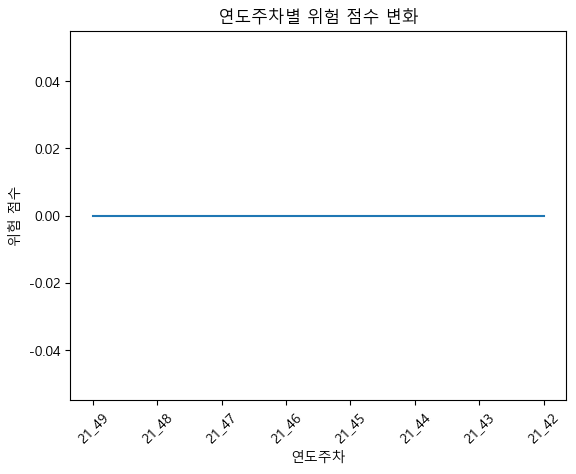

HS Code : 6211499000
21_49주차
0    26930.459
1    24421.996
2    25027.774
3    21604.538
4    22161.393
5    22568.227
6    26826.899
7    28972.130
8    25455.630
9    27769.148
10   21867.247
11   18280.738
12   19556.000
13   18692.384
14   20379.634
15   24753.296
16   25092.587
17   25113.794
18   26347.047
19   23875.302
20   25154.702
21   26195.039
22   24931.866
23   26747.747
24   27421.702
25   26681.170
26   25954.544
27   24207.117
28   24995.344
29   23005.472
30   26285.071
31   27927.277
32   28003.912
33   30946.812
34   27645.858
35   27631.550
36   25543.089
37   23822.939
38   23490.415
39   23577.738
40   22772.998
41   24642.840
42   27567.414
43   28357.225
44   31992.191
45   32554.913
46   34226.559
47   32949.703
48   30370.130
49   27891.669
50   25590.161
51   27028.707
Name: 신고중량, dtype: float64


c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_48주차
0    25623.370
1    26930.459
2    24421.996
3    25027.774
4    21604.538
5    22161.393
6    22568.227
7    26826.899
8    28972.130
9    25455.630
10   27769.148
11   21867.247
12   18280.738
13   19556.000
14   18692.384
15   20379.634
16   24753.296
17   25092.587
18   25113.794
19   26347.047
20   23875.302
21   25154.702
22   26195.039
23   24931.866
24   26747.747
25   27421.702
26   26681.170
27   25954.544
28   24207.117
29   24995.344
30   23005.472
31   26285.071
32   27927.277
33   28003.912
34   30946.812
35   27645.858
36   27631.550
37   25543.089
38   23822.939
39   23490.415
40   23577.738
41   22772.998
42   24642.840
43   27567.414
44   28357.225
45   31992.191
46   32554.913
47   34226.559
48   32949.703
49   30370.130
50   27891.669
51   25590.161
Name: 신고중량, dtype: float64
======================= 여기부터 GARCH 모델링 ================================

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_44주차
0    23725.444
1    21761.330
2    24586.038
3    22767.428
4    25623.370
5    26930.459
6    24421.996
7    25027.774
8    21604.538
9    22161.393
10   22568.227
11   26826.899
12   28972.130
13   25455.630
14   27769.148
15   21867.247
16   18280.738
17   19556.000
18   18692.384
19   20379.634
20   24753.296
21   25092.587
22   25113.794
23   26347.047
24   23875.302
25   25154.702
26   26195.039
27   24931.866
28   26747.747
29   27421.702
30   26681.170
31   25954.544
32   24207.117
33   24995.344
34   23005.472
35   26285.071
36   27927.277
37   28003.912
38   30946.812
39   27645.858
40   27631.550
41   25543.089
42   23822.939
43   23490.415
44   23577.738
45   22772.998
46   24642.840
47   27567.414
48   28357.225
49   31992.191
50   32554.913
51   34226.559
Name: 신고중량, dtype: float64


c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_43주차
0    24157.113
1    23725.444
2    21761.330
3    24586.038
4    22767.428
5    25623.370
6    26930.459
7    24421.996
8    25027.774
9    21604.538
10   22161.393
11   22568.227
12   26826.899
13   28972.130
14   25455.630
15   27769.148
16   21867.247
17   18280.738
18   19556.000
19   18692.384
20   20379.634
21   24753.296
22   25092.587
23   25113.794
24   26347.047
25   23875.302
26   25154.702
27   26195.039
28   24931.866
29   26747.747
30   27421.702
31   26681.170
32   25954.544
33   24207.117
34   24995.344
35   23005.472
36   26285.071
37   27927.277
38   28003.912
39   30946.812
40   27645.858
41   27631.550
42   25543.089
43   23822.939
44   23490.415
45   23577.738
46   22772.998
47   24642.840
48   27567.414
49   28357.225
50   31992.191
51   32554.913
Name: 신고중량, dtype: float64
======================= 여기부터 GARCH 모델링 ================================

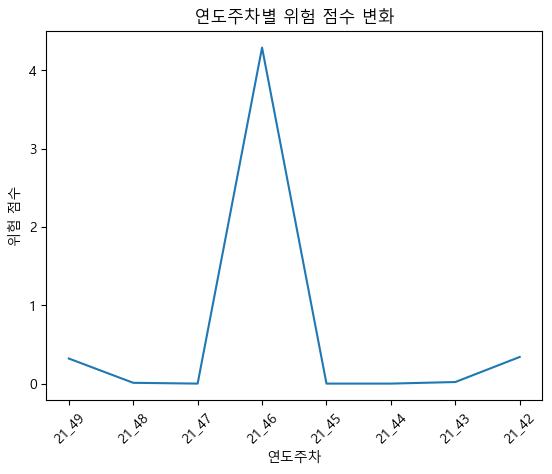

HS Code : 4202999000
21_49주차
0    66723.245
1    67152.349
2    61066.964
3    55428.709
4    55706.149
5    63913.987
6    68270.610
7    69112.077
8    62976.340
9    47304.053
10   39131.426
11   31463.999
12   32201.121
13   43691.699
14   53012.843
15   59486.694
16   65225.049
17   61583.547
18   55881.757
19   57716.022
20   59666.627
21   58611.340
22   59282.937
23   63785.790
24   59075.356
25   62289.757
26   60217.443
27   50010.755
28   49202.336
29   49535.937
30   53348.804
31   52855.733
32   58966.901
33   50958.578
34   48476.045
35   47847.189
36   40827.168
37   39361.320
38   39138.140
39   44134.174
40   41307.308
41   47215.491
42   50667.020
43   49886.807
44   57060.781
45   58751.327
46   57035.059
47   60770.331
48   58016.397
49   52566.602
50   54655.934
51   52582.912
Name: 신고중량, dtype: float64


c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_48주차
0    64727.059
1    66723.245
2    67152.349
3    61066.964
4    55428.709
5    55706.149
6    63913.987
7    68270.610
8    69112.077
9    62976.340
10   47304.053
11   39131.426
12   31463.999
13   32201.121
14   43691.699
15   53012.843
16   59486.694
17   65225.049
18   61583.547
19   55881.757
20   57716.022
21   59666.627
22   58611.340
23   59282.937
24   63785.790
25   59075.356
26   62289.757
27   60217.443
28   50010.755
29   49202.336
30   49535.937
31   53348.804
32   52855.733
33   58966.901
34   50958.578
35   48476.045
36   47847.189
37   40827.168
38   39361.320
39   39138.140
40   44134.174
41   41307.308
42   47215.491
43   50667.020
44   49886.807
45   57060.781
46   58751.327
47   57035.059
48   60770.331
49   58016.397
50   52566.602
51   54655.934
Name: 신고중량, dtype: float64
======================= 여기부터 GARCH 모델링 ================================

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_46주차
0    59285.395
1    63827.313
2    64727.059
3    66723.245
4    67152.349
5    61066.964
6    55428.709
7    55706.149
8    63913.987
9    68270.610
10   69112.077
11   62976.340
12   47304.053
13   39131.426
14   31463.999
15   32201.121
16   43691.699
17   53012.843
18   59486.694
19   65225.049
20   61583.547
21   55881.757
22   57716.022
23   59666.627
24   58611.340
25   59282.937
26   63785.790
27   59075.356
28   62289.757
29   60217.443
30   50010.755
31   49202.336
32   49535.937
33   53348.804
34   52855.733
35   58966.901
36   50958.578
37   48476.045
38   47847.189
39   40827.168
40   39361.320
41   39138.140
42   44134.174
43   41307.308
44   47215.491
45   50667.020
46   49886.807
47   57060.781
48   58751.327
49   57035.059
50   60770.331
51   58016.397
Name: 신고중량, dtype: float64


c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_45주차
0    58431.123
1    59285.395
2    63827.313
3    64727.059
4    66723.245
5    67152.349
6    61066.964
7    55428.709
8    55706.149
9    63913.987
10   68270.610
11   69112.077
12   62976.340
13   47304.053
14   39131.426
15   31463.999
16   32201.121
17   43691.699
18   53012.843
19   59486.694
20   65225.049
21   61583.547
22   55881.757
23   57716.022
24   59666.627
25   58611.340
26   59282.937
27   63785.790
28   59075.356
29   62289.757
30   60217.443
31   50010.755
32   49202.336
33   49535.937
34   53348.804
35   52855.733
36   58966.901
37   50958.578
38   48476.045
39   47847.189
40   40827.168
41   39361.320
42   39138.140
43   44134.174
44   41307.308
45   47215.491
46   50667.020
47   49886.807
48   57060.781
49   58751.327
50   57035.059
51   60770.331
Name: 신고중량, dtype: float64
======================= 여기부터 GARCH 모델링 ================================

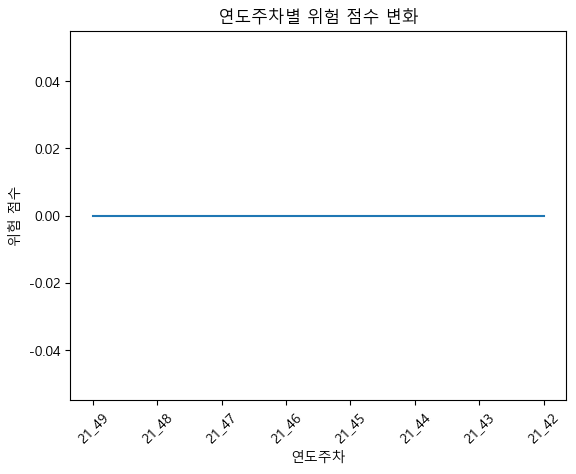

HS Code : 3304991000
21_49주차
0    895898.917
1    863778.879
2    773564.771
3    737856.007
4    693434.264
5    648984.694
6    752263.109
7    762292.448
8    712792.733
9    707502.222
10   791944.354
11   851615.701
12   946542.836
13   911068.268
14   788309.735
15   678862.908
16   609830.681
17   614372.756
18   657510.563
19   616650.975
20   710133.699
21   812113.305
22   791814.180
23   822443.864
24   684679.278
25   594627.936
26   633933.438
27   800177.722
28   853352.563
29   938352.973
30   961776.628
31   802083.205
32   845855.793
33   804272.893
34   835240.049
35   927412.114
36   926436.445
37   883914.840
38   947810.825
39   903737.995
40   833809.597
41   931299.077
42   831421.180
43   804589.785
44   948225.543
45   827092.531
46   753091.475
47   758944.448
48   707855.415
49   782178.237
50   821018.883
51   868145.065
Name: 신고중량, dtype: float64
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast ============

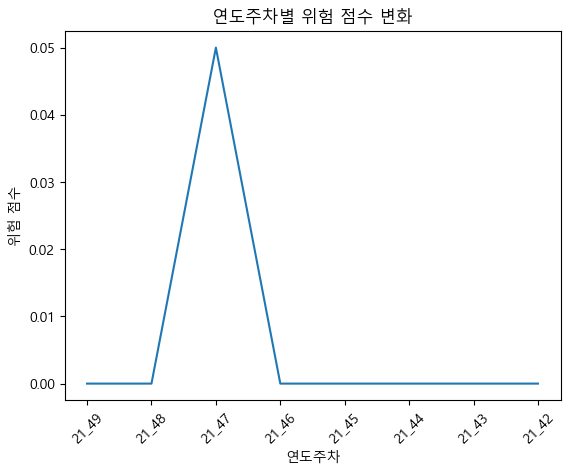

HS Code : 8544429090
21_49주차
0    101156.466
1    104575.839
2     90694.047
3     91340.301
4     97390.501
5     93108.943
6    108288.520
7    114102.541
8    107743.333
9    110252.016
10    94104.531
11    73504.044
12    70308.645
13    72606.482
14    96151.522
15   106836.255
16   119633.426
17   134854.356
18   133557.645
19   138059.527
20   139239.920
21   121560.253
22   113327.270
23   114838.293
24   128562.463
25   127314.430
26   137821.567
27   136035.254
28   121862.583
29   129366.433
30   129812.106
31   127527.540
32   118953.236
33   113053.112
34   107584.864
35   113903.773
36   118003.728
37   133489.267
38   138924.272
39   134654.537
40   132284.163
41   128772.008
42   110506.666
43   113239.637
44   105713.957
45    91314.781
46    95608.976
47    87138.171
48   112774.511
49   117301.278
50   124998.120
51   128890.633
Name: 신고중량, dtype: float64
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast ============

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


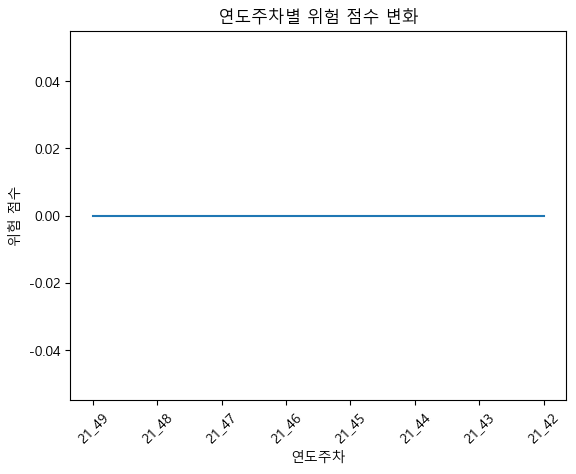

HS Code : 8481801090
21_49주차
0    745657.387
1    735916.234
2    656786.258
3    626885.485
4    699180.763
5    718567.250
6    860693.386
7    905105.367
8    816191.459
9    853771.850
10   731216.577
11   686092.307
12   675586.253
13   616090.162
14   744523.519
15   775825.052
16   853465.530
17   856390.379
18   782330.475
19   790164.627
20   768365.829
21   869983.630
22   885629.355
23   955128.728
24   960218.899
25   910728.845
26   939013.289
27   902560.562
28   833864.725
29   829148.369
30   757008.066
31   715641.028
32   759853.742
33   671579.128
34   703141.498
35   670483.630
36   642616.048
37   718841.949
38   724158.294
39   754568.091
40   729300.417
41   731993.066
42   692933.386
43   711410.008
44   773027.618
45   770501.627
46   832751.237
47   797777.639
48   785679.960
49   750064.345
50   736592.198
51   766775.330
Name: 신고중량, dtype: float64
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast ============

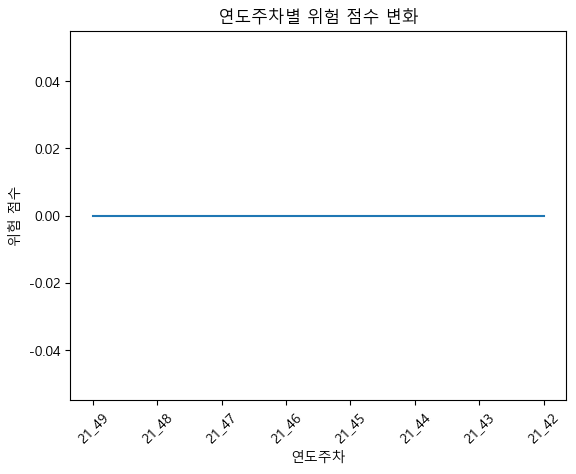

HS Code : 3304999000
21_49주차
0    69085.617
1    69945.386
2    63323.314
3    55280.012
4    58239.447
5    65541.687
6    77103.102
7    83607.440
8    76749.692
9    78091.016
10   72623.321
11   66754.132
12   68426.881
13   72709.815
14   66355.998
15   65671.971
16   61989.013
17   57669.616
18   66968.734
19   69269.887
20   67478.111
21   68916.611
22   65299.890
23   63595.200
24   65044.903
25   61328.417
26   56158.347
27   61009.977
28   59997.862
29   55924.739
30   60633.841
31   54774.001
32   59999.179
33   59201.526
34   64398.654
35   65276.598
36   61356.113
37   61398.719
38   51998.954
39   59043.005
40   57436.288
41   57358.990
42   63865.247
43   61862.042
44   64290.606
45   62892.462
46   58195.679
47   55871.336
48   54202.907
49   55450.908
50   57417.412
51   61359.202
Name: 신고중량, dtype: float64
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_48주차
0    73544.588
1    69085.617
2    69945.3

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_47주차
0    68809.707
1    73544.588
2    69085.617
3    69945.386
4    63323.314
5    55280.012
6    58239.447
7    65541.687
8    77103.102
9    83607.440
10   76749.692
11   78091.016
12   72623.321
13   66754.132
14   68426.881
15   72709.815
16   66355.998
17   65671.971
18   61989.013
19   57669.616
20   66968.734
21   69269.887
22   67478.111
23   68916.611
24   65299.890
25   63595.200
26   65044.903
27   61328.417
28   56158.347
29   61009.977
30   59997.862
31   55924.739
32   60633.841
33   54774.001
34   59999.179
35   59201.526
36   64398.654
37   65276.598
38   61356.113
39   61398.719
40   51998.954
41   59043.005
42   57436.288
43   57358.990
44   63865.247
45   61862.042
46   64290.606
47   62892.462
48   58195.679
49   55871.336
50   54202.907
51   55450.908
Name: 신고중량, dtype: float64
======================= 여기부터 GARCH 모델링 ================================

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_42주차
0    68751.597
1    58996.159
2    57295.920
3    70734.980
4    64969.723
5    68809.707
6    73544.588
7    69085.617
8    69945.386
9    63323.314
10   55280.012
11   58239.447
12   65541.687
13   77103.102
14   83607.440
15   76749.692
16   78091.016
17   72623.321
18   66754.132
19   68426.881
20   72709.815
21   66355.998
22   65671.971
23   61989.013
24   57669.616
25   66968.734
26   69269.887
27   67478.111
28   68916.611
29   65299.890
30   63595.200
31   65044.903
32   61328.417
33   56158.347
34   61009.977
35   59997.862
36   55924.739
37   60633.841
38   54774.001
39   59999.179
40   59201.526
41   64398.654
42   65276.598
43   61356.113
44   61398.719
45   51998.954
46   59043.005
47   57436.288
48   57358.990
49   63865.247
50   61862.042
51   64290.606
Name: 신고중량, dtype: float64
======================= 여기부터 GARCH 모델링 ================================

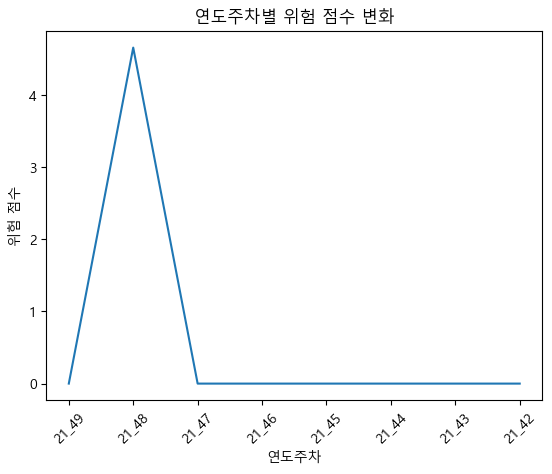

HS Code : 8543709090
21_49주차
0    114901.258
1    123705.927
2    118801.859
3    117365.541
4    114685.115
5    105548.869
6    107293.353
7    111569.125
8    103047.654
9    108044.975
10   111914.667
11   113309.133
12   126381.161
13   121721.579
14   118515.808
15   115308.265
16   125048.361
17   146069.620
18   160046.076
19   177543.913
20   191165.981
21   194055.995
22   201794.345
23   204975.944
24   217648.304
25   220474.764
26   239269.731
27   233514.368
28   224155.764
29   222957.758
30   203619.436
31   199763.627
32   193058.753
33   186304.523
34   180711.979
35   160550.785
36   158228.313
37   157483.594
38   142126.238
39   145411.160
40   126185.512
41   114960.827
42   110234.427
43   106899.182
44   108213.567
45    93291.519
46   106784.399
47   113036.191
48   107451.101
49   126009.944
50   111435.873
51   107860.957
Name: 신고중량, dtype: float64
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast ============

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_47주차
0    110911.685
1    114700.425
2    114901.258
3    123705.927
4    118801.859
5    117365.541
6    114685.115
7    105548.869
8    107293.353
9    111569.125
10   103047.654
11   108044.975
12   111914.667
13   113309.133
14   126381.161
15   121721.579
16   118515.808
17   115308.265
18   125048.361
19   146069.620
20   160046.076
21   177543.913
22   191165.981
23   194055.995
24   201794.345
25   204975.944
26   217648.304
27   220474.764
28   239269.731
29   233514.368
30   224155.764
31   222957.758
32   203619.436
33   199763.627
34   193058.753
35   186304.523
36   180711.979
37   160550.785
38   158228.313
39   157483.594
40   142126.238
41   145411.160
42   126185.512
43   114960.827
44   110234.427
45   106899.182
46   108213.567
47    93291.519
48   106784.399
49   113036.191
50   107451.101
51   126009.944
Name: 신고중량, dtype: float64
===================

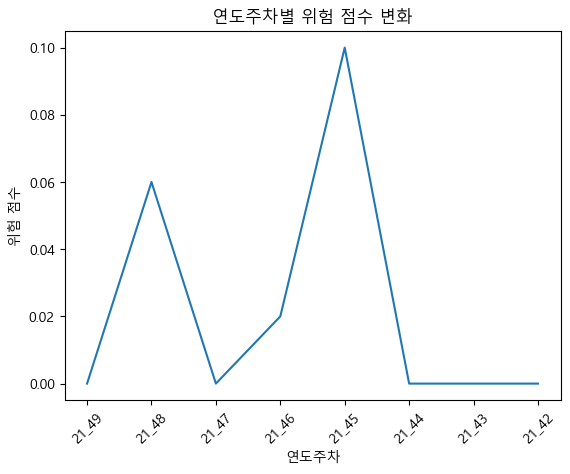

HS Code : 6404199000
21_49주차
0    520404.531
1    480924.053
2    447449.153
3    430692.927
4    420553.085
5    465878.654
6    515497.552
7    626515.750
8    610039.417
9    646050.059
10   621615.471
11   453071.774
12   451326.013
13   419521.646
14   458434.889
15   513141.071
16   531603.020
17   565620.770
18   567039.904
19   593108.625
20   586081.361
21   580144.762
22   526949.444
23   522894.222
24   532576.828
25   488479.528
26   470996.684
27   445754.218
28   452429.346
29   416223.727
30   439234.867
31   415301.195
32   397445.383
33   406966.966
34   399100.480
35   398622.968
36   383169.667
37   430987.492
38   410569.484
39   496142.057
40   459212.666
41   462817.919
42   522960.336
43   448142.256
44   473476.519
45   452314.845
46   414007.313
47   433659.240
48   456589.722
49   474747.505
50   497479.498
51   480855.530
Name: 신고중량, dtype: float64
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast ============

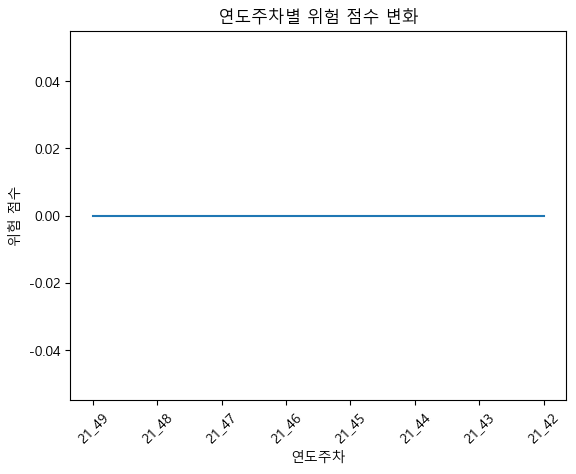

HS Code : 3004909900
21_49주차
0     949155.776
1     884812.030
2     927750.900
3    1065655.376
4    1027494.291
5     998972.053
6    1128644.685
7    1067489.233
8     972902.547
9    1012630.833
10   1050135.055
11   1043717.554
12   1190000.295
13   1397844.594
14   1247817.151
15   1270493.676
16   1277965.616
17   1055536.420
18   1051105.706
19   1004817.653
20    900701.415
21   1127843.845
22   1198294.538
23   1249240.160
24   1242657.547
25   1115945.667
26    968106.127
27   1046822.982
28   1095854.790
29   1043910.511
30   1085118.332
31   1122807.477
32   1070099.580
33   1225273.587
34   1276076.698
35   1159680.355
36   1145971.005
37   1138257.570
38   1091298.170
39   1124451.854
40   1138836.319
41   1249408.647
42   1310582.297
43   1230162.957
44   1321952.663
45   1148860.570
46   1117226.300
47   1126124.575
48   1050016.868
49   1013102.833
50   1053043.879
51   1125835.898
Name: 신고중량, dtype: float64
======================= 여기부터 GARCH 모델링 =====================

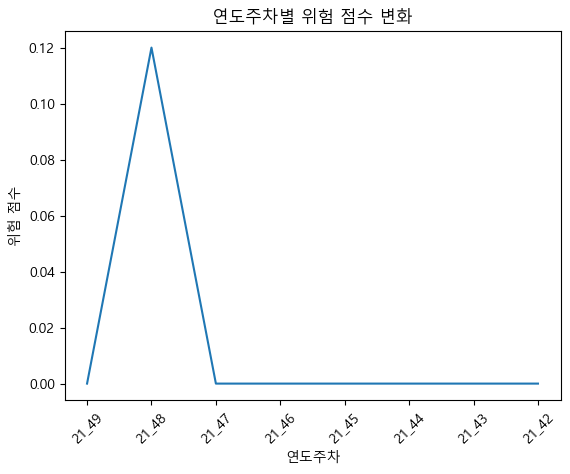

HS Code : 8542311000
21_49주차
0    64384.203
1    62173.378
2    57198.122
3    61487.767
4    61511.488
5    65438.606
6    70028.356
7    68452.137
8    64407.045
9    61374.746
10   65206.844
11   63760.082
12   67543.976
13   68729.274
14   65637.259
15   66427.610
16   67031.380
17   67588.560
18   69169.640
19   69432.934
20   69572.576
21   71266.783
22   69456.767
23   69431.319
24   71243.606
25   71328.368
26   72416.649
27   74970.085
28   73745.767
29   73840.328
30   76541.100
31   75173.277
32   77319.022
33   76234.009
34   74833.554
35   75964.275
36   76851.709
37   79110.584
38   79356.265
39   79255.989
40   72573.602
41   75578.934
42   74523.138
43   73890.965
44   79425.077
45   76878.020
46   79316.463
47   78406.627
48   77071.275
49   75322.473
50   73693.566
51   74000.547
Name: 신고중량, dtype: float64
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_48주차
0    62317.675
1    64384.203
2    62173.3

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_46주차
0    63739.507
1    63014.762
2    62317.675
3    64384.203
4    62173.378
5    57198.122
6    61487.767
7    61511.488
8    65438.606
9    70028.356
10   68452.137
11   64407.045
12   61374.746
13   65206.844
14   63760.082
15   67543.976
16   68729.274
17   65637.259
18   66427.610
19   67031.380
20   67588.560
21   69169.640
22   69432.934
23   69572.576
24   71266.783
25   69456.767
26   69431.319
27   71243.606
28   71328.368
29   72416.649
30   74970.085
31   73745.767
32   73840.328
33   76541.100
34   75173.277
35   77319.022
36   76234.009
37   74833.554
38   75964.275
39   76851.709
40   79110.584
41   79356.265
42   79255.989
43   72573.602
44   75578.934
45   74523.138
46   73890.965
47   79425.077
48   76878.020
49   79316.463
50   78406.627
51   77071.275
Name: 신고중량, dtype: float64


c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_45주차
0    64701.537
1    63739.507
2    63014.762
3    62317.675
4    64384.203
5    62173.378
6    57198.122
7    61487.767
8    61511.488
9    65438.606
10   70028.356
11   68452.137
12   64407.045
13   61374.746
14   65206.844
15   63760.082
16   67543.976
17   68729.274
18   65637.259
19   66427.610
20   67031.380
21   67588.560
22   69169.640
23   69432.934
24   69572.576
25   71266.783
26   69456.767
27   69431.319
28   71243.606
29   71328.368
30   72416.649
31   74970.085
32   73745.767
33   73840.328
34   76541.100
35   75173.277
36   77319.022
37   76234.009
38   74833.554
39   75964.275
40   76851.709
41   79110.584
42   79356.265
43   79255.989
44   72573.602
45   75578.934
46   74523.138
47   73890.965
48   79425.077
49   76878.020
50   79316.463
51   78406.627
Name: 신고중량, dtype: float64
======================= 여기부터 GARCH 모델링 ================================

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


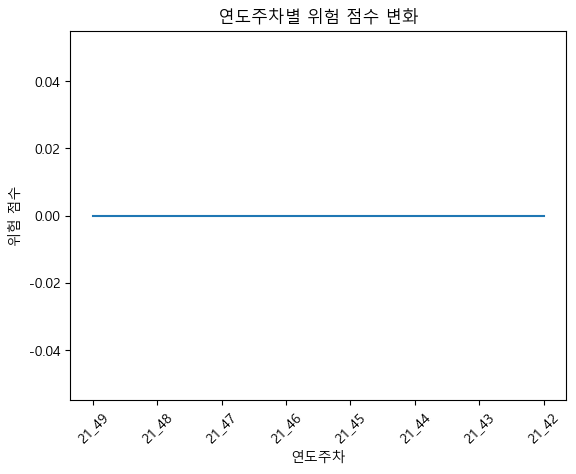

HS Code : 4901999000
21_49주차
0    156112.714
1    146759.967
2    145173.954
3    162615.894
4    131172.290
5    144767.654
6    145953.964
7    147626.903
8    138382.624
9    131102.591
10   144898.737
11   128096.758
12   146242.413
13   149179.005
14   146818.156
15   146186.027
16   131721.284
17   122242.320
18   103508.030
19    99488.739
20   113927.592
21   118790.850
22   127594.879
23   138000.539
24   125582.861
25   109948.093
26   110078.550
27   112299.863
28   108977.843
29   126470.397
30   122653.449
31   115024.460
32   116001.479
33   117609.965
34   125133.436
35   118852.895
36   123557.456
37   134308.964
38   123579.268
39   117259.097
40   122517.436
41   116375.785
42   114705.423
43   140500.295
44   131214.905
45   110794.927
46   111379.585
47    86175.741
48    83803.100
49    84560.444
50    84297.157
51   102763.297
Name: 신고중량, dtype: float64
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast ============

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_44주차
0    112135.630
1    106325.159
2    107845.811
3    112533.566
4    120910.071
5    156112.714
6    146759.967
7    145173.954
8    162615.894
9    131172.290
10   144767.654
11   145953.964
12   147626.903
13   138382.624
14   131102.591
15   144898.737
16   128096.758
17   146242.413
18   149179.005
19   146818.156
20   146186.027
21   131721.284
22   122242.320
23   103508.030
24    99488.739
25   113927.592
26   118790.850
27   127594.879
28   138000.539
29   125582.861
30   109948.093
31   110078.550
32   112299.863
33   108977.843
34   126470.397
35   122653.449
36   115024.460
37   116001.479
38   117609.965
39   125133.436
40   118852.895
41   123557.456
42   134308.964
43   123579.268
44   117259.097
45   122517.436
46   116375.785
47   114705.423
48   140500.295
49   131214.905
50   110794.927
51   111379.585
Name: 신고중량, dtype: float64


c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_43주차
0    122758.050
1    112135.630
2    106325.159
3    107845.811
4    112533.566
5    120910.071
6    156112.714
7    146759.967
8    145173.954
9    162615.894
10   131172.290
11   144767.654
12   145953.964
13   147626.903
14   138382.624
15   131102.591
16   144898.737
17   128096.758
18   146242.413
19   149179.005
20   146818.156
21   146186.027
22   131721.284
23   122242.320
24   103508.030
25    99488.739
26   113927.592
27   118790.850
28   127594.879
29   138000.539
30   125582.861
31   109948.093
32   110078.550
33   112299.863
34   108977.843
35   126470.397
36   122653.449
37   115024.460
38   116001.479
39   117609.965
40   125133.436
41   118852.895
42   123557.456
43   134308.964
44   123579.268
45   117259.097
46   122517.436
47   116375.785
48   114705.423
49   140500.295
50   131214.905
51   110794.927
Name: 신고중량, dtype: float64
===================

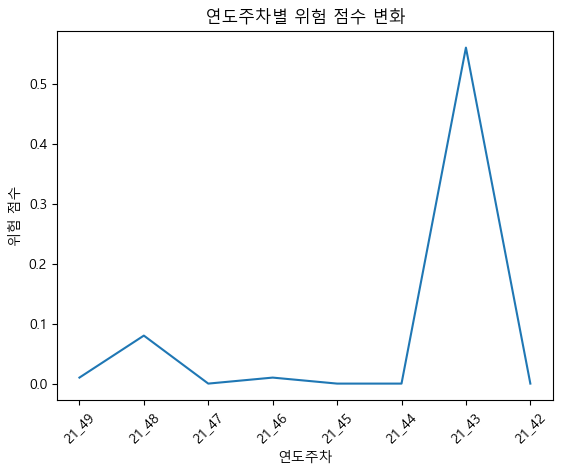

HS Code : 8473309090
21_49주차
0     91610.984
1     92051.675
2     77842.865
3     86542.998
4    100110.152
5    101947.967
6    117595.562
7    116982.294
8    107676.617
9    101035.314
10    97998.599
11    88765.762
12    92721.788
13    94079.364
14    91236.670
15    91985.670
16   100437.050
17    96740.772
18   103494.308
19   110084.233
20   112279.497
21   125013.417
22   129312.819
23   120107.387
24   117170.698
25   104144.267
26   107118.506
27   105750.325
28    97224.462
29   109545.895
30    89423.803
31    90840.655
32    85641.878
33    76660.066
34    88613.516
35    88669.811
36    94908.269
37    96888.480
38   102080.564
39    97627.307
40    94620.352
41   102444.507
42   102370.516
43   109530.033
44   117315.367
45   116302.247
46   114120.287
47   122478.686
48   117002.318
49   110201.079
50   113660.328
51   114775.596
Name: 신고중량, dtype: float64
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast ============

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_43주차
0     78045.328
1     79077.487
2     84780.416
3     95244.880
4     96277.207
5     95794.771
6     91610.984
7     92051.675
8     77842.865
9     86542.998
10   100110.152
11   101947.967
12   117595.562
13   116982.294
14   107676.617
15   101035.314
16    97998.599
17    88765.762
18    92721.788
19    94079.364
20    91236.670
21    91985.670
22   100437.050
23    96740.772
24   103494.308
25   110084.233
26   112279.497
27   125013.417
28   129312.819
29   120107.387
30   117170.698
31   104144.267
32   107118.506
33   105750.325
34    97224.462
35   109545.895
36    89423.803
37    90840.655
38    85641.878
39    76660.066
40    88613.516
41    88669.811
42    94908.269
43    96888.480
44   102080.564
45    97627.307
46    94620.352
47   102444.507
48   102370.516
49   109530.033
50   117315.367
51   116302.247
Name: 신고중량, dtype: float64


c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_42주차
0     82740.746
1     78045.328
2     79077.487
3     84780.416
4     95244.880
5     96277.207
6     95794.771
7     91610.984
8     92051.675
9     77842.865
10    86542.998
11   100110.152
12   101947.967
13   117595.562
14   116982.294
15   107676.617
16   101035.314
17    97998.599
18    88765.762
19    92721.788
20    94079.364
21    91236.670
22    91985.670
23   100437.050
24    96740.772
25   103494.308
26   110084.233
27   112279.497
28   125013.417
29   129312.819
30   120107.387
31   117170.698
32   104144.267
33   107118.506
34   105750.325
35    97224.462
36   109545.895
37    89423.803
38    90840.655
39    85641.878
40    76660.066
41    88613.516
42    88669.811
43    94908.269
44    96888.480
45   102080.564
46    97627.307
47    94620.352
48   102444.507
49   102370.516
50   109530.033
51   117315.367
Name: 신고중량, dtype: float64
===================

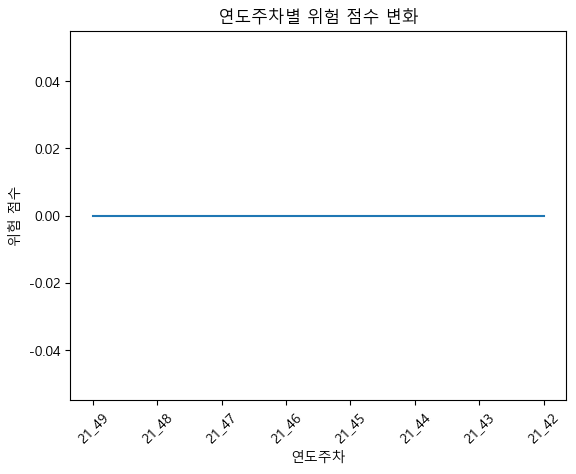

HS Code : 6307909000
21_49주차
0    900164.355
1    855200.547
2    860998.015
3    834873.097
4    807575.211
5    835761.196
6    827035.271
7    833551.007
8    757710.825
9    636615.410
10   526757.970
11   412525.561
12   418786.510
13   463819.705
14   550360.442
15   642785.004
16   686437.830
17   743660.789
18   738486.643
19   757444.456
20   773526.171
21   715247.841
22   713885.225
23   723029.542
24   732956.413
25   741670.551
26   726380.746
27   700386.878
28   667879.781
29   686270.619
30   701378.728
31   658479.693
32   646674.623
33   633453.625
34   643856.038
35   632335.006
36   627332.719
37   637452.332
38   603954.242
39   626212.656
40   589607.893
41   613309.255
42   600403.613
43   610250.728
44   701341.977
45   665559.071
46   699592.725
47   703276.673
48   724126.880
49   717603.245
50   727904.306
51   764428.909
Name: 신고중량, dtype: float64


c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_48주차
0    926480.144
1    900164.355
2    855200.547
3    860998.015
4    834873.097
5    807575.211
6    835761.196
7    827035.271
8    833551.007
9    757710.825
10   636615.410
11   526757.970
12   412525.561
13   418786.510
14   463819.705
15   550360.442
16   642785.004
17   686437.830
18   743660.789
19   738486.643
20   757444.456
21   773526.171
22   715247.841
23   713885.225
24   723029.542
25   732956.413
26   741670.551
27   726380.746
28   700386.878
29   667879.781
30   686270.619
31   701378.728
32   658479.693
33   646674.623
34   633453.625
35   643856.038
36   632335.006
37   627332.719
38   637452.332
39   603954.242
40   626212.656
41   589607.893
42   613309.255
43   600403.613
44   610250.728
45   701341.977
46   665559.071
47   699592.725
48   703276.673
49   724126.880
50   717603.245
51   727904.306
Name: 신고중량, dtype: float64
===================

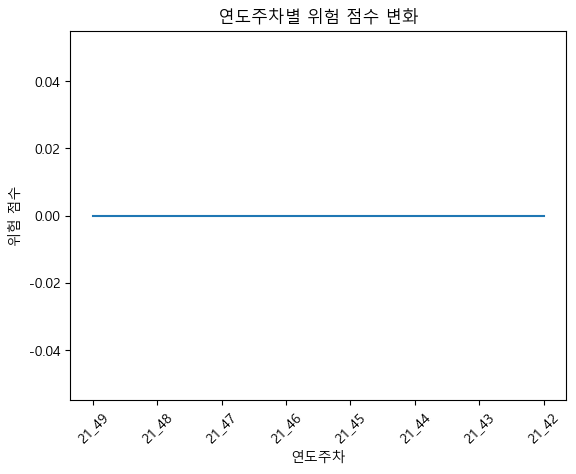

HS Code : 4202211090
21_49주차
0    52263.671
1    47838.790
2    43435.399
3    44503.772
4    42555.229
5    49707.213
6    56121.919
7    68872.104
8    71236.824
9    66766.088
10   64530.305
11   49156.903
12   48663.179
13   48036.599
14   50878.901
15   53759.516
16   51964.728
17   55250.921
18   54807.624
19   60789.986
20   62347.020
21   64190.178
22   61902.435
23   57922.386
24   57161.986
25   58930.013
26   57014.098
27   56651.065
28   57567.049
29   54416.429
30   59474.312
31   56963.876
32   55882.202
33   52134.267
34   51819.952
35   55624.114
36   55300.264
37   57703.269
38   59241.577
39   64137.902
40   61144.544
41   67722.705
42   60762.855
43   50604.607
44   59065.515
45   56297.069
46   64801.019
47   67281.234
48   65701.979
49   63666.548
50   59248.963
51   57506.936
Name: 신고중량, dtype: float64


c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_48주차
0    51930.337
1    52263.671
2    47838.790
3    43435.399
4    44503.772
5    42555.229
6    49707.213
7    56121.919
8    68872.104
9    71236.824
10   66766.088
11   64530.305
12   49156.903
13   48663.179
14   48036.599
15   50878.901
16   53759.516
17   51964.728
18   55250.921
19   54807.624
20   60789.986
21   62347.020
22   64190.178
23   61902.435
24   57922.386
25   57161.986
26   58930.013
27   57014.098
28   56651.065
29   57567.049
30   54416.429
31   59474.312
32   56963.876
33   55882.202
34   52134.267
35   51819.952
36   55624.114
37   55300.264
38   57703.269
39   59241.577
40   64137.902
41   61144.544
42   67722.705
43   60762.855
44   50604.607
45   59065.515
46   56297.069
47   64801.019
48   67281.234
49   65701.979
50   63666.548
51   59248.963
Name: 신고중량, dtype: float64
======================= 여기부터 GARCH 모델링 ================================

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_46주차
0    50706.137
1    51482.715
2    51930.337
3    52263.671
4    47838.790
5    43435.399
6    44503.772
7    42555.229
8    49707.213
9    56121.919
10   68872.104
11   71236.824
12   66766.088
13   64530.305
14   49156.903
15   48663.179
16   48036.599
17   50878.901
18   53759.516
19   51964.728
20   55250.921
21   54807.624
22   60789.986
23   62347.020
24   64190.178
25   61902.435
26   57922.386
27   57161.986
28   58930.013
29   57014.098
30   56651.065
31   57567.049
32   54416.429
33   59474.312
34   56963.876
35   55882.202
36   52134.267
37   51819.952
38   55624.114
39   55300.264
40   57703.269
41   59241.577
42   64137.902
43   61144.544
44   67722.705
45   60762.855
46   50604.607
47   59065.515
48   56297.069
49   64801.019
50   67281.234
51   65701.979
Name: 신고중량, dtype: float64
======================= 여기부터 GARCH 모델링 ================================

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_44주차
0    58603.191
1    49528.982
2    50706.137
3    51482.715
4    51930.337
5    52263.671
6    47838.790
7    43435.399
8    44503.772
9    42555.229
10   49707.213
11   56121.919
12   68872.104
13   71236.824
14   66766.088
15   64530.305
16   49156.903
17   48663.179
18   48036.599
19   50878.901
20   53759.516
21   51964.728
22   55250.921
23   54807.624
24   60789.986
25   62347.020
26   64190.178
27   61902.435
28   57922.386
29   57161.986
30   58930.013
31   57014.098
32   56651.065
33   57567.049
34   54416.429
35   59474.312
36   56963.876
37   55882.202
38   52134.267
39   51819.952
40   55624.114
41   55300.264
42   57703.269
43   59241.577
44   64137.902
45   61144.544
46   67722.705
47   60762.855
48   50604.607
49   59065.515
50   56297.069
51   64801.019
Name: 신고중량, dtype: float64
======================= 여기부터 GARCH 모델링 ================================

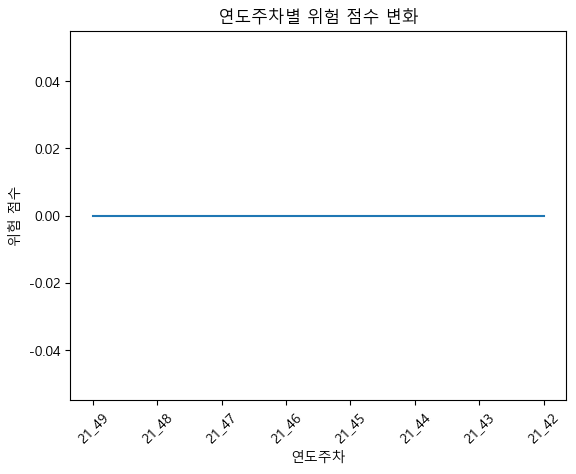

HS Code : 8536509090
21_49주차
0    60246.861
1    59881.584
2    55862.932
3    57719.618
4    57651.495
5    62709.417
6    73432.723
7    76198.813
8    69825.888
9    61976.343
10   53589.749
11   46231.214
12   52058.659
13   53888.197
14   55729.191
15   58278.385
16   60851.425
17   63938.195
18   68966.169
19   71665.670
20   68629.845
21   66029.588
22   64549.445
23   64838.267
24   69843.178
25   73062.585
26   72054.022
27   73131.471
28   68791.433
29   70023.747
30   72755.953
31   68491.653
32   69480.282
33   66202.060
34   64791.815
35   68134.273
36   71643.812
37   70910.772
38   67100.735
39   68808.384
40   59183.688
41   63215.745
42   59622.653
43   54587.757
44   57278.682
45   52906.475
46   56257.046
47   53786.517
48   56916.038
49   56831.011
50   61160.953
51   66028.743
Name: 신고중량, dtype: float64


c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_48주차
0    61082.831
1    60246.861
2    59881.584
3    55862.932
4    57719.618
5    57651.495
6    62709.417
7    73432.723
8    76198.813
9    69825.888
10   61976.343
11   53589.749
12   46231.214
13   52058.659
14   53888.197
15   55729.191
16   58278.385
17   60851.425
18   63938.195
19   68966.169
20   71665.670
21   68629.845
22   66029.588
23   64549.445
24   64838.267
25   69843.178
26   73062.585
27   72054.022
28   73131.471
29   68791.433
30   70023.747
31   72755.953
32   68491.653
33   69480.282
34   66202.060
35   64791.815
36   68134.273
37   71643.812
38   70910.772
39   67100.735
40   68808.384
41   59183.688
42   63215.745
43   59622.653
44   54587.757
45   57278.682
46   52906.475
47   56257.046
48   53786.517
49   56916.038
50   56831.011
51   61160.953
Name: 신고중량, dtype: float64


c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_47주차
0    62214.295
1    61082.831
2    60246.861
3    59881.584
4    55862.932
5    57719.618
6    57651.495
7    62709.417
8    73432.723
9    76198.813
10   69825.888
11   61976.343
12   53589.749
13   46231.214
14   52058.659
15   53888.197
16   55729.191
17   58278.385
18   60851.425
19   63938.195
20   68966.169
21   71665.670
22   68629.845
23   66029.588
24   64549.445
25   64838.267
26   69843.178
27   73062.585
28   72054.022
29   73131.471
30   68791.433
31   70023.747
32   72755.953
33   68491.653
34   69480.282
35   66202.060
36   64791.815
37   68134.273
38   71643.812
39   70910.772
40   67100.735
41   68808.384
42   59183.688
43   63215.745
44   59622.653
45   54587.757
46   57278.682
47   52906.475
48   56257.046
49   53786.517
50   56916.038
51   56831.011
Name: 신고중량, dtype: float64
======================= 여기부터 GARCH 모델링 ================================

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_44주차
0    57472.110
1    63046.169
2    62675.256
3    62214.295
4    61082.831
5    60246.861
6    59881.584
7    55862.932
8    57719.618
9    57651.495
10   62709.417
11   73432.723
12   76198.813
13   69825.888
14   61976.343
15   53589.749
16   46231.214
17   52058.659
18   53888.197
19   55729.191
20   58278.385
21   60851.425
22   63938.195
23   68966.169
24   71665.670
25   68629.845
26   66029.588
27   64549.445
28   64838.267
29   69843.178
30   73062.585
31   72054.022
32   73131.471
33   68791.433
34   70023.747
35   72755.953
36   68491.653
37   69480.282
38   66202.060
39   64791.815
40   68134.273
41   71643.812
42   70910.772
43   67100.735
44   68808.384
45   59183.688
46   63215.745
47   59622.653
48   54587.757
49   57278.682
50   52906.475
51   56257.046
Name: 신고중량, dtype: float64


c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_43주차
0    55591.327
1    57472.110
2    63046.169
3    62675.256
4    62214.295
5    61082.831
6    60246.861
7    59881.584
8    55862.932
9    57719.618
10   57651.495
11   62709.417
12   73432.723
13   76198.813
14   69825.888
15   61976.343
16   53589.749
17   46231.214
18   52058.659
19   53888.197
20   55729.191
21   58278.385
22   60851.425
23   63938.195
24   68966.169
25   71665.670
26   68629.845
27   66029.588
28   64549.445
29   64838.267
30   69843.178
31   73062.585
32   72054.022
33   73131.471
34   68791.433
35   70023.747
36   72755.953
37   68491.653
38   69480.282
39   66202.060
40   64791.815
41   68134.273
42   71643.812
43   70910.772
44   67100.735
45   68808.384
46   59183.688
47   63215.745
48   59622.653
49   54587.757
50   57278.682
51   52906.475
Name: 신고중량, dtype: float64
======================= 여기부터 GARCH 모델링 ================================

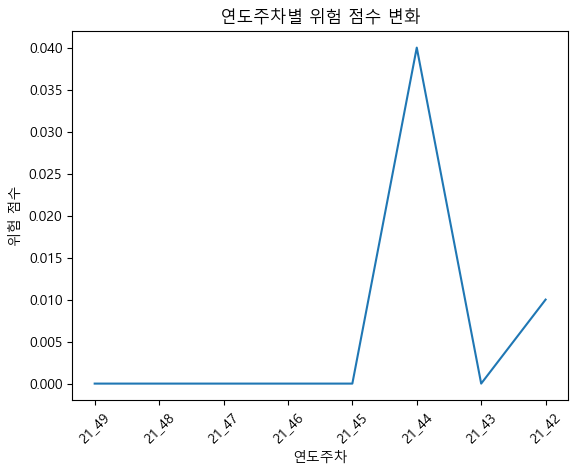

HS Code : 8538909000
21_49주차
0    199761.115
1    199441.904
2    187885.608
3    194462.358
4    191117.803
5    200038.034
6    208605.636
7    216470.493
8    197672.697
9    188647.886
10   182415.817
11   181936.029
12   198798.902
13   210688.322
14   222716.960
15   224866.703
16   221231.820
17   226015.939
18   229038.843
19   218696.898
20   224361.777
21   208650.944
22   205020.536
23   205948.316
24   198469.953
25   208272.869
26   207890.690
27   207299.203
28   211281.924
29   211696.081
30   204108.060
31   200466.252
32   199819.663
33   187307.524
34   197126.450
35   198674.106
36   195437.835
37   197533.574
38   195054.206
39   203356.068
40   191907.244
41   210783.458
42   205122.084
43   197882.973
44   217859.742
45   206634.222
46   204718.757
47   194566.177
48   190181.643
49   201268.669
50   210702.767
51   220170.011
Name: 신고중량, dtype: float64


c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_48주차
0    196392.304
1    199761.115
2    199441.904
3    187885.608
4    194462.358
5    191117.803
6    200038.034
7    208605.636
8    216470.493
9    197672.697
10   188647.886
11   182415.817
12   181936.029
13   198798.902
14   210688.322
15   222716.960
16   224866.703
17   221231.820
18   226015.939
19   229038.843
20   218696.898
21   224361.777
22   208650.944
23   205020.536
24   205948.316
25   198469.953
26   208272.869
27   207890.690
28   207299.203
29   211281.924
30   211696.081
31   204108.060
32   200466.252
33   199819.663
34   187307.524
35   197126.450
36   198674.106
37   195437.835
38   197533.574
39   195054.206
40   203356.068
41   191907.244
42   210783.458
43   205122.084
44   197882.973
45   217859.742
46   206634.222
47   204718.757
48   194566.177
49   190181.643
50   201268.669
51   210702.767
Name: 신고중량, dtype: float64


c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_47주차
0    192899.825
1    196392.304
2    199761.115
3    199441.904
4    187885.608
5    194462.358
6    191117.803
7    200038.034
8    208605.636
9    216470.493
10   197672.697
11   188647.886
12   182415.817
13   181936.029
14   198798.902
15   210688.322
16   222716.960
17   224866.703
18   221231.820
19   226015.939
20   229038.843
21   218696.898
22   224361.777
23   208650.944
24   205020.536
25   205948.316
26   198469.953
27   208272.869
28   207890.690
29   207299.203
30   211281.924
31   211696.081
32   204108.060
33   200466.252
34   199819.663
35   187307.524
36   197126.450
37   198674.106
38   195437.835
39   197533.574
40   195054.206
41   203356.068
42   191907.244
43   210783.458
44   205122.084
45   197882.973
46   217859.742
47   206634.222
48   204718.757
49   194566.177
50   190181.643
51   201268.669
Name: 신고중량, dtype: float64


c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_46주차
0    186938.005
1    192899.825
2    196392.304
3    199761.115
4    199441.904
5    187885.608
6    194462.358
7    191117.803
8    200038.034
9    208605.636
10   216470.493
11   197672.697
12   188647.886
13   182415.817
14   181936.029
15   198798.902
16   210688.322
17   222716.960
18   224866.703
19   221231.820
20   226015.939
21   229038.843
22   218696.898
23   224361.777
24   208650.944
25   205020.536
26   205948.316
27   198469.953
28   208272.869
29   207890.690
30   207299.203
31   211281.924
32   211696.081
33   204108.060
34   200466.252
35   199819.663
36   187307.524
37   197126.450
38   198674.106
39   195437.835
40   197533.574
41   195054.206
42   203356.068
43   191907.244
44   210783.458
45   205122.084
46   197882.973
47   217859.742
48   206634.222
49   204718.757
50   194566.177
51   190181.643
Name: 신고중량, dtype: float64
===================

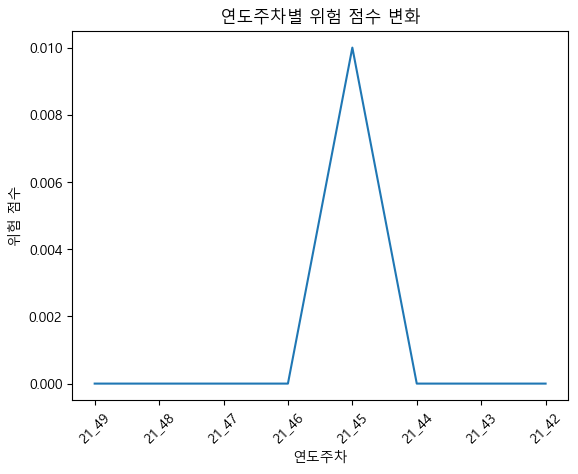

HS Code : 8479909090
21_49주차
0    112048.781
1    126766.957
2    125416.917
3    105350.832
4    100439.274
5    103018.610
6    151530.944
7    163666.752
8    160897.102
9    143558.380
10    93901.027
11    84863.768
12    82797.873
13    79444.750
14    75683.794
15   108633.485
16   128945.313
17   143757.616
18   154953.597
19   142790.867
20   203356.607
21   191812.873
22   204169.511
23   189986.617
24   115756.440
25   121356.489
26   102231.066
27   112846.854
28   114433.980
29   115168.452
30   119993.733
31   104367.571
32    96017.003
33    91278.054
34   102875.546
35   111890.800
36   155777.930
37   171014.271
38   181960.435
39   205102.444
40   163973.476
41   151471.874
42   136612.686
43   107335.853
44   105219.171
45   128521.757
46   123912.799
47   124247.103
48   133855.954
49   114923.410
50   107620.129
51   150180.005
Name: 신고중량, dtype: float64
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast ============

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_45주차
0    104970.501
1     91391.171
2     86954.512
3     97204.329
4    112048.781
5    126766.957
6    125416.917
7    105350.832
8    100439.274
9    103018.610
10   151530.944
11   163666.752
12   160897.102
13   143558.380
14    93901.027
15    84863.768
16    82797.873
17    79444.750
18    75683.794
19   108633.485
20   128945.313
21   143757.616
22   154953.597
23   142790.867
24   203356.607
25   191812.873
26   204169.511
27   189986.617
28   115756.440
29   121356.489
30   102231.066
31   112846.854
32   114433.980
33   115168.452
34   119993.733
35   104367.571
36    96017.003
37    91278.054
38   102875.546
39   111890.800
40   155777.930
41   171014.271
42   181960.435
43   205102.444
44   163973.476
45   151471.874
46   136612.686
47   107335.853
48   105219.171
49   128521.757
50   123912.799
51   124247.103
Name: 신고중량, dtype: float64


c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_44주차
0    159498.193
1    104970.501
2     91391.171
3     86954.512
4     97204.329
5    112048.781
6    126766.957
7    125416.917
8    105350.832
9    100439.274
10   103018.610
11   151530.944
12   163666.752
13   160897.102
14   143558.380
15    93901.027
16    84863.768
17    82797.873
18    79444.750
19    75683.794
20   108633.485
21   128945.313
22   143757.616
23   154953.597
24   142790.867
25   203356.607
26   191812.873
27   204169.511
28   189986.617
29   115756.440
30   121356.489
31   102231.066
32   112846.854
33   114433.980
34   115168.452
35   119993.733
36   104367.571
37    96017.003
38    91278.054
39   102875.546
40   111890.800
41   155777.930
42   171014.271
43   181960.435
44   205102.444
45   163973.476
46   151471.874
47   136612.686
48   107335.853
49   105219.171
50   128521.757
51   123912.799
Name: 신고중량, dtype: float64


c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_43주차
0    161500.258
1    159498.193
2    104970.501
3     91391.171
4     86954.512
5     97204.329
6    112048.781
7    126766.957
8    125416.917
9    105350.832
10   100439.274
11   103018.610
12   151530.944
13   163666.752
14   160897.102
15   143558.380
16    93901.027
17    84863.768
18    82797.873
19    79444.750
20    75683.794
21   108633.485
22   128945.313
23   143757.616
24   154953.597
25   142790.867
26   203356.607
27   191812.873
28   204169.511
29   189986.617
30   115756.440
31   121356.489
32   102231.066
33   112846.854
34   114433.980
35   115168.452
36   119993.733
37   104367.571
38    96017.003
39    91278.054
40   102875.546
41   111890.800
42   155777.930
43   171014.271
44   181960.435
45   205102.444
46   163973.476
47   151471.874
48   136612.686
49   107335.853
50   105219.171
51   128521.757
Name: 신고중량, dtype: float64
===================

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


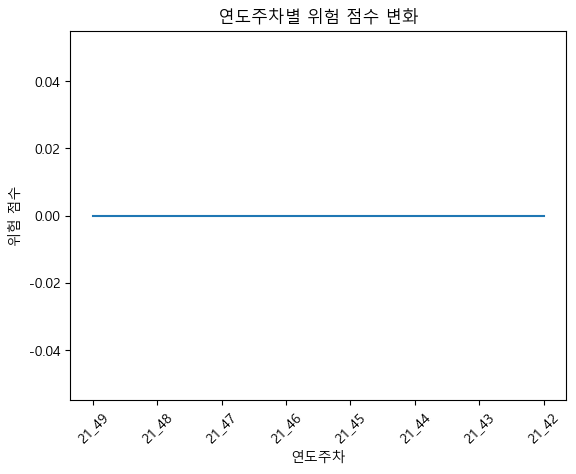

HS Code : 8504409099
21_49주차
0    216825.794
1    199827.486
2    179645.250
3    193645.123
4    196618.522
5    195558.510
6    208094.351
7    201482.680
8    171348.328
9    151900.337
10   161690.884
11   156171.154
12   168230.079
13   183337.540
14   185024.951
15   189484.781
16   206875.188
17   212747.092
18   207588.165
19   216804.356
20   205525.343
21   217407.987
22   215845.767
23   207014.077
24   205934.674
25   186686.059
26   180236.845
27   169120.167
28   171992.050
29   165689.307
30   163102.634
31   168771.955
32   161358.438
33   151891.834
34   172642.168
35   177962.378
36   189972.877
37   209534.020
38   224852.107
39   223312.774
40   202127.537
41   212087.678
42   184165.601
43   176057.471
44   199007.909
45   194586.809
46   200616.718
47   208281.764
48   208160.965
49   199726.969
50   205292.366
51   204354.150
Name: 신고중량, dtype: float64
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast ============

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_42주차
0    193093.297
1    210118.269
2    212228.189
3    200078.634
4    224052.558
5    207539.050
6    205614.339
7    216825.794
8    199827.486
9    179645.250
10   193645.123
11   196618.522
12   195558.510
13   208094.351
14   201482.680
15   171348.328
16   151900.337
17   161690.884
18   156171.154
19   168230.079
20   183337.540
21   185024.951
22   189484.781
23   206875.188
24   212747.092
25   207588.165
26   216804.356
27   205525.343
28   217407.987
29   215845.767
30   207014.077
31   205934.674
32   186686.059
33   180236.845
34   169120.167
35   171992.050
36   165689.307
37   163102.634
38   168771.955
39   161358.438
40   151891.834
41   172642.168
42   177962.378
43   189972.877
44   209534.020
45   224852.107
46   223312.774
47   202127.537
48   212087.678
49   184165.601
50   176057.471
51   199007.909
Name: 신고중량, dtype: float64
===================

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


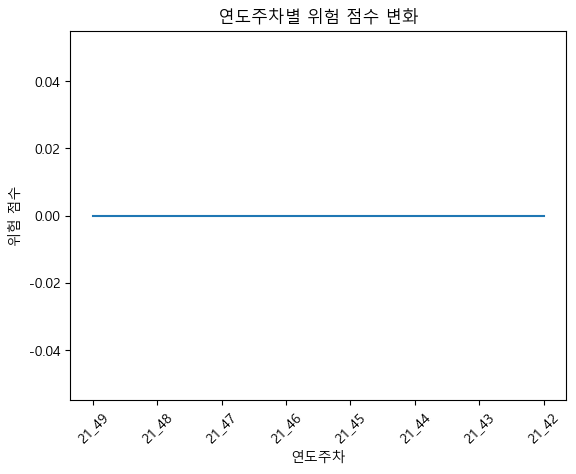

HS Code : 6110909000
21_49주차
0     8329.869
1     8464.396
2     7257.489
3     6288.368
4     6835.757
5     6779.111
6     8079.757
7     9089.175
8     8405.817
9     8296.678
10    8070.520
11    7537.493
12    7741.536
13    7979.335
14    7746.431
15    7554.070
16    7020.086
17    9755.739
18   11137.030
19   11854.092
20   11780.782
21    8407.641
22    6203.400
23    5058.238
24    4930.196
25    4734.483
26    4628.604
27    4246.866
28    4461.281
29    4800.432
30    4891.676
31    5535.059
32    5788.977
33    5688.744
34    6603.052
35    6293.580
36    6797.350
37    8019.029
38    9139.782
39   11714.179
40   12470.156
41   12586.524
42   12535.442
43   11383.473
44   10599.771
45   10235.388
46    9636.431
47    9440.897
48    9779.190
49    9376.521
50    8755.875
51    8156.627
Name: 신고중량, dtype: float64
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_48주차
0     8906.381
1     8329.869
2     8464.3

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_46주차
0     9208.502
1     8819.989
2     8906.381
3     8329.869
4     8464.396
5     7257.489
6     6288.368
7     6835.757
8     6779.111
9     8079.757
10    9089.175
11    8405.817
12    8296.678
13    8070.520
14    7537.493
15    7741.536
16    7979.335
17    7746.431
18    7554.070
19    7020.086
20    9755.739
21   11137.030
22   11854.092
23   11780.782
24    8407.641
25    6203.400
26    5058.238
27    4930.196
28    4734.483
29    4628.604
30    4246.866
31    4461.281
32    4800.432
33    4891.676
34    5535.059
35    5788.977
36    5688.744
37    6603.052
38    6293.580
39    6797.350
40    8019.029
41    9139.782
42   11714.179
43   12470.156
44   12586.524
45   12535.442
46   11383.473
47   10599.771
48   10235.388
49    9636.431
50    9440.897
51    9779.190
Name: 신고중량, dtype: float64
======================= 여기부터 GARCH 모델링 ================================

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_42주차
0    11595.303
1    11630.011
2     9821.943
3     9779.158
4     9208.502
5     8819.989
6     8906.381
7     8329.869
8     8464.396
9     7257.489
10    6288.368
11    6835.757
12    6779.111
13    8079.757
14    9089.175
15    8405.817
16    8296.678
17    8070.520
18    7537.493
19    7741.536
20    7979.335
21    7746.431
22    7554.070
23    7020.086
24    9755.739
25   11137.030
26   11854.092
27   11780.782
28    8407.641
29    6203.400
30    5058.238
31    4930.196
32    4734.483
33    4628.604
34    4246.866
35    4461.281
36    4800.432
37    4891.676
38    5535.059
39    5788.977
40    5688.744
41    6603.052
42    6293.580
43    6797.350
44    8019.029
45    9139.782
46   11714.179
47   12470.156
48   12586.524
49   12535.442
50   11383.473
51   10599.771
Name: 신고중량, dtype: float64
======================= 여기부터 GARCH 모델링 ================================

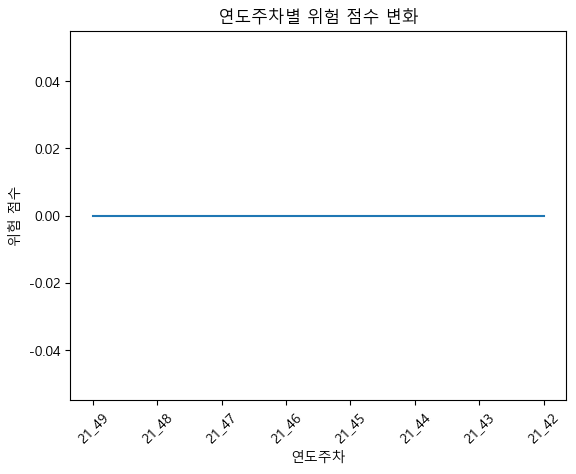

HS Code : 3923100000
21_49주차
0    2760055.509
1    2747754.836
2    2656156.484
3    2646868.933
4    2671309.609
5    2683346.298
6    2764500.299
7    2772380.321
8    2513009.629
9    2562331.680
10   2640499.349
11   2539079.478
12   2771224.359
13   2820960.400
14   2744185.470
15   2827318.585
16   2782199.998
17   2740199.480
18   2718235.256
19   2716759.946
20   2716977.223
21   2643542.802
22   2694008.953
23   2668632.471
24   2792509.116
25   2892573.942
26   2788654.483
27   2749768.365
28   2680352.248
29   2664357.786
30   2750525.043
31   2810178.279
32   2734749.803
33   2621414.039
34   2606494.357
35   2530923.871
36   2586072.799
37   2733623.846
38   2772844.732
39   2694135.490
40   2520020.841
41   2514992.634
42   2410200.205
43   2452681.530
44   2461986.009
45   2472739.614
46   2536284.745
47   2666145.525
48   2823337.816
49   2758204.996
50   2813461.301
51   2805015.637
Name: 신고중량, dtype: float64
======================= 여기부터 GARCH 모델링 =====================

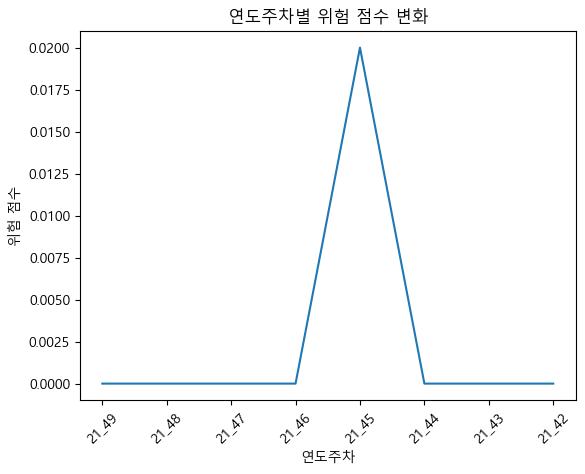

HS Code : 8544422090
21_49주차
0    592554.243
1    594159.720
2    542417.829
3    555542.468
4    575473.396
5    556596.500
6    608890.774
7    619072.457
8    596437.152
9    587936.560
10   535538.496
11   502699.259
12   529489.940
13   551338.563
14   609617.063
15   651213.323
16   662395.741
17   679611.653
18   690655.017
19   704209.197
20   708044.196
21   693730.049
22   693236.784
23   648364.668
24   651708.669
25   658263.496
26   642450.528
27   637310.535
28   641261.290
29   646440.738
30   644340.554
31   658469.509
32   623322.266
33   578704.487
34   610574.283
35   601538.838
36   613575.430
37   678850.777
38   626588.502
39   643880.257
40   592754.735
41   575369.397
42   569907.662
43   544593.456
44   562571.419
45   542053.535
46   589463.106
47   579034.367
48   608628.172
49   595439.399
50   609342.726
51   618771.152
Name: 신고중량, dtype: float64


c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_48주차
0    611372.793
1    592554.243
2    594159.720
3    542417.829
4    555542.468
5    575473.396
6    556596.500
7    608890.774
8    619072.457
9    596437.152
10   587936.560
11   535538.496
12   502699.259
13   529489.940
14   551338.563
15   609617.063
16   651213.323
17   662395.741
18   679611.653
19   690655.017
20   704209.197
21   708044.196
22   693730.049
23   693236.784
24   648364.668
25   651708.669
26   658263.496
27   642450.528
28   637310.535
29   641261.290
30   646440.738
31   644340.554
32   658469.509
33   623322.266
34   578704.487
35   610574.283
36   601538.838
37   613575.430
38   678850.777
39   626588.502
40   643880.257
41   592754.735
42   575369.397
43   569907.662
44   544593.456
45   562571.419
46   542053.535
47   589463.106
48   579034.367
49   608628.172
50   595439.399
51   609342.726
Name: 신고중량, dtype: float64
===================

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_45주차
0    607418.906
1    607132.131
2    607795.945
3    611372.793
4    592554.243
5    594159.720
6    542417.829
7    555542.468
8    575473.396
9    556596.500
10   608890.774
11   619072.457
12   596437.152
13   587936.560
14   535538.496
15   502699.259
16   529489.940
17   551338.563
18   609617.063
19   651213.323
20   662395.741
21   679611.653
22   690655.017
23   704209.197
24   708044.196
25   693730.049
26   693236.784
27   648364.668
28   651708.669
29   658263.496
30   642450.528
31   637310.535
32   641261.290
33   646440.738
34   644340.554
35   658469.509
36   623322.266
37   578704.487
38   610574.283
39   601538.838
40   613575.430
41   678850.777
42   626588.502
43   643880.257
44   592754.735
45   575369.397
46   569907.662
47   544593.456
48   562571.419
49   542053.535
50   589463.106
51   579034.367
Name: 신고중량, dtype: float64


c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_44주차
0    613763.052
1    607418.906
2    607132.131
3    607795.945
4    611372.793
5    592554.243
6    594159.720
7    542417.829
8    555542.468
9    575473.396
10   556596.500
11   608890.774
12   619072.457
13   596437.152
14   587936.560
15   535538.496
16   502699.259
17   529489.940
18   551338.563
19   609617.063
20   651213.323
21   662395.741
22   679611.653
23   690655.017
24   704209.197
25   708044.196
26   693730.049
27   693236.784
28   648364.668
29   651708.669
30   658263.496
31   642450.528
32   637310.535
33   641261.290
34   646440.738
35   644340.554
36   658469.509
37   623322.266
38   578704.487
39   610574.283
40   601538.838
41   613575.430
42   678850.777
43   626588.502
44   643880.257
45   592754.735
46   575369.397
47   569907.662
48   544593.456
49   562571.419
50   542053.535
51   589463.106
Name: 신고중량, dtype: float64
===================

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


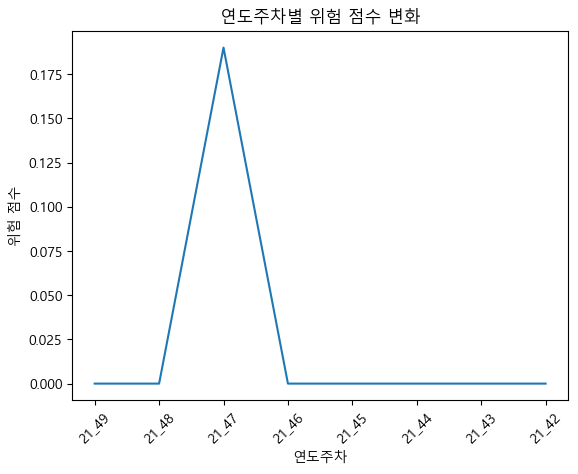

HS Code : 8537109000
21_49주차
0    74592.855
1    73949.129
2    68330.765
3    69954.558
4    68034.449
5    64513.579
6    77855.183
7    76620.841
8    77345.098
9    85454.958
10   73300.009
11   76587.261
12   78790.947
13   69704.942
14   72391.245
15   68572.360
16   64021.203
17   64935.287
18   65468.412
19   62095.634
20   77515.754
21   73790.957
22   78130.993
23   80567.066
24   67788.136
25   75763.816
26   71878.339
27   72832.569
28   67338.546
29   67918.086
30   68214.203
31   72355.603
32   69023.532
33   63995.537
34   68789.229
35   64471.302
36   65153.326
37   70452.124
38   70138.466
39   74916.758
40   72811.560
41   74958.909
42   70089.915
43   65012.782
44   75079.697
45   69888.309
46   68868.634
47   72232.854
48   65078.221
49   75083.353
50   77225.294
51   76201.032
Name: 신고중량, dtype: float64


c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_48주차
0    71109.438
1    74592.855
2    73949.129
3    68330.765
4    69954.558
5    68034.449
6    64513.579
7    77855.183
8    76620.841
9    77345.098
10   85454.958
11   73300.009
12   76587.261
13   78790.947
14   69704.942
15   72391.245
16   68572.360
17   64021.203
18   64935.287
19   65468.412
20   62095.634
21   77515.754
22   73790.957
23   78130.993
24   80567.066
25   67788.136
26   75763.816
27   71878.339
28   72832.569
29   67338.546
30   67918.086
31   68214.203
32   72355.603
33   69023.532
34   63995.537
35   68789.229
36   64471.302
37   65153.326
38   70452.124
39   70138.466
40   74916.758
41   72811.560
42   74958.909
43   70089.915
44   65012.782
45   75079.697
46   69888.309
47   68868.634
48   72232.854
49   65078.221
50   75083.353
51   77225.294
Name: 신고중량, dtype: float64


c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_47주차
0    85949.515
1    71109.438
2    74592.855
3    73949.129
4    68330.765
5    69954.558
6    68034.449
7    64513.579
8    77855.183
9    76620.841
10   77345.098
11   85454.958
12   73300.009
13   76587.261
14   78790.947
15   69704.942
16   72391.245
17   68572.360
18   64021.203
19   64935.287
20   65468.412
21   62095.634
22   77515.754
23   73790.957
24   78130.993
25   80567.066
26   67788.136
27   75763.816
28   71878.339
29   72832.569
30   67338.546
31   67918.086
32   68214.203
33   72355.603
34   69023.532
35   63995.537
36   68789.229
37   64471.302
38   65153.326
39   70452.124
40   70138.466
41   74916.758
42   72811.560
43   74958.909
44   70089.915
45   65012.782
46   75079.697
47   69888.309
48   68868.634
49   72232.854
50   65078.221
51   75083.353
Name: 신고중량, dtype: float64


c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_46주차
0    93148.357
1    85949.515
2    71109.438
3    74592.855
4    73949.129
5    68330.765
6    69954.558
7    68034.449
8    64513.579
9    77855.183
10   76620.841
11   77345.098
12   85454.958
13   73300.009
14   76587.261
15   78790.947
16   69704.942
17   72391.245
18   68572.360
19   64021.203
20   64935.287
21   65468.412
22   62095.634
23   77515.754
24   73790.957
25   78130.993
26   80567.066
27   67788.136
28   75763.816
29   71878.339
30   72832.569
31   67338.546
32   67918.086
33   68214.203
34   72355.603
35   69023.532
36   63995.537
37   68789.229
38   64471.302
39   65153.326
40   70452.124
41   70138.466
42   74916.758
43   72811.560
44   74958.909
45   70089.915
46   65012.782
47   75079.697
48   69888.309
49   68868.634
50   72232.854
51   65078.221
Name: 신고중량, dtype: float64
======================= 여기부터 GARCH 모델링 ================================

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_44주차
0    85197.806
1    89650.907
2    93148.357
3    85949.515
4    71109.438
5    74592.855
6    73949.129
7    68330.765
8    69954.558
9    68034.449
10   64513.579
11   77855.183
12   76620.841
13   77345.098
14   85454.958
15   73300.009
16   76587.261
17   78790.947
18   69704.942
19   72391.245
20   68572.360
21   64021.203
22   64935.287
23   65468.412
24   62095.634
25   77515.754
26   73790.957
27   78130.993
28   80567.066
29   67788.136
30   75763.816
31   71878.339
32   72832.569
33   67338.546
34   67918.086
35   68214.203
36   72355.603
37   69023.532
38   63995.537
39   68789.229
40   64471.302
41   65153.326
42   70452.124
43   70138.466
44   74916.758
45   72811.560
46   74958.909
47   70089.915
48   65012.782
49   75079.697
50   69888.309
51   68868.634
Name: 신고중량, dtype: float64
======================= 여기부터 GARCH 모델링 ================================

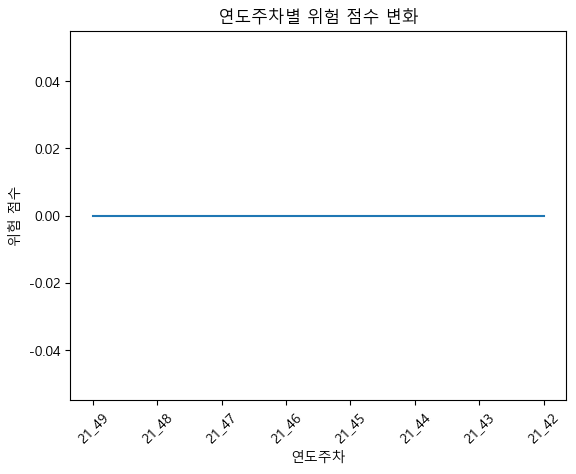

HS Code : 8536699000
21_49주차
0    128069.363
1    127105.610
2    130369.402
3    122272.494
4    137565.283
5    149963.333
6    144977.549
7    166590.883
8    159418.604
9    152072.122
10   151573.824
11   117350.798
12   116455.800
13   112737.595
14   120929.632
15   138426.899
16   146031.757
17   153382.350
18   152844.359
19   154429.435
20   140406.318
21   136227.571
22   144984.728
23   137638.730
24   145161.396
25   147985.332
26   128614.835
27   137769.859
28   149936.850
29   142002.905
30   163849.396
31   170749.419
32   153664.103
33   151614.902
34   132697.429
35   110936.073
36   123599.201
37   123768.768
38   121213.679
39   130607.708
40   116624.726
41   117256.377
42   126526.663
43   130895.728
44   129847.120
45   131199.055
46   143075.682
47   138958.040
48   146357.837
49   154058.545
50   142992.821
51   145852.479
Name: 신고중량, dtype: float64
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast ============

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_47주차
0    125078.333
1    131426.537
2    128069.363
3    127105.610
4    130369.402
5    122272.494
6    137565.283
7    149963.333
8    144977.549
9    166590.883
10   159418.604
11   152072.122
12   151573.824
13   117350.798
14   116455.800
15   112737.595
16   120929.632
17   138426.899
18   146031.757
19   153382.350
20   152844.359
21   154429.435
22   140406.318
23   136227.571
24   144984.728
25   137638.730
26   145161.396
27   147985.332
28   128614.835
29   137769.859
30   149936.850
31   142002.905
32   163849.396
33   170749.419
34   153664.103
35   151614.902
36   132697.429
37   110936.073
38   123599.201
39   123768.768
40   121213.679
41   130607.708
42   116624.726
43   117256.377
44   126526.663
45   130895.728
46   129847.120
47   131199.055
48   143075.682
49   138958.040
50   146357.837
51   154058.545
Name: 신고중량, dtype: float64


c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_46주차
0    123085.494
1    125078.333
2    131426.537
3    128069.363
4    127105.610
5    130369.402
6    122272.494
7    137565.283
8    149963.333
9    144977.549
10   166590.883
11   159418.604
12   152072.122
13   151573.824
14   117350.798
15   116455.800
16   112737.595
17   120929.632
18   138426.899
19   146031.757
20   153382.350
21   152844.359
22   154429.435
23   140406.318
24   136227.571
25   144984.728
26   137638.730
27   145161.396
28   147985.332
29   128614.835
30   137769.859
31   149936.850
32   142002.905
33   163849.396
34   170749.419
35   153664.103
36   151614.902
37   132697.429
38   110936.073
39   123599.201
40   123768.768
41   121213.679
42   130607.708
43   116624.726
44   117256.377
45   126526.663
46   130895.728
47   129847.120
48   131199.055
49   143075.682
50   138958.040
51   146357.837
Name: 신고중량, dtype: float64


...

======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_45주차
0    127436.207
1    123085.494
2    125078.333
3    131426.537
4    128069.363
5    127105.610
6    130369.402
7    122272.494
8    137565.283
9    149963.333
10   144977.549
11   166590.883
12   159418.604
13   152072.122
14   151573.824
15   117350.798
16   116455.800
17   112737.595
18   120929.632
19   138426.899
20   146031.757
21   153382.350
22   152844.359
23   154429.435
24   140406.318
25   136227.571
26   144984.728
27   137638.730
28   145161.396
29   147985.332
30   128614.835
31   137769.859
32   149936.850
33   142002.905
34   163849.396
35   170749.419
36   153664.103
37   151614.902
38   132697.429
39   110936.073
40   123599.201
41   123768.768
42   121213.679
43   130607.708
44   116624.726
45   117256.377
46   126526.663
47   130895.728
48   129847.120
49   131199.055
50   143075.682
51   138958.040
Name: 신고중량, dtype: float64
===================

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_43주차
0    132847.360
1    126357.160
2    127436.207
3    123085.494
4    125078.333
5    131426.537
6    128069.363
7    127105.610
8    130369.402
9    122272.494
10   137565.283
11   149963.333
12   144977.549
13   166590.883
14   159418.604
15   152072.122
16   151573.824
17   117350.798
18   116455.800
19   112737.595
20   120929.632
21   138426.899
22   146031.757
23   153382.350
24   152844.359
25   154429.435
26   140406.318
27   136227.571
28   144984.728
29   137638.730
30   145161.396
31   147985.332
32   128614.835
33   137769.859
34   149936.850
35   142002.905
36   163849.396
37   170749.419
38   153664.103
39   151614.902
40   132697.429
41   110936.073
42   123599.201
43   123768.768
44   121213.679
45   130607.708
46   116624.726
47   117256.377
48   126526.663
49   130895.728
50   129847.120
51   131199.055
Name: 신고중량, dtype: float64


c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_42주차
0    142575.732
1    132847.360
2    126357.160
3    127436.207
4    123085.494
5    125078.333
6    131426.537
7    128069.363
8    127105.610
9    130369.402
10   122272.494
11   137565.283
12   149963.333
13   144977.549
14   166590.883
15   159418.604
16   152072.122
17   151573.824
18   117350.798
19   116455.800
20   112737.595
21   120929.632
22   138426.899
23   146031.757
24   153382.350
25   152844.359
26   154429.435
27   140406.318
28   136227.571
29   144984.728
30   137638.730
31   145161.396
32   147985.332
33   128614.835
34   137769.859
35   149936.850
36   142002.905
37   163849.396
38   170749.419
39   153664.103
40   151614.902
41   132697.429
42   110936.073
43   123599.201
44   123768.768
45   121213.679
46   130607.708
47   116624.726
48   117256.377
49   126526.663
50   130895.728
51   129847.120
Name: 신고중량, dtype: float64
===================

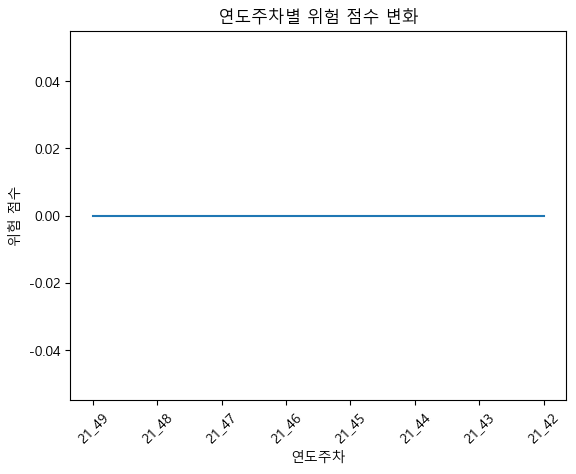

HS Code : 3102109000
21_14주차
0     7595152.514
1     6690618.513
2     4845948.741
3     5082300.688
4     6711051.035
5     6433905.144
6     7739305.729
7     8280687.614
8     8150787.332
9     8345732.808
10    7001619.634
11    5895656.384
12    5435314.991
13    5974286.142
14    7965065.094
15    9219891.994
16    9042738.254
17   11076218.961
18    8122886.807
19    6505523.432
20    5793011.707
21    3575184.192
22    2996353.069
23    3415777.144
24    2940932.594
25    4572083.900
26    5892192.336
27    8621320.361
28   10201257.261
29    8196479.362
30    6882415.227
31    8418110.158
32    7855938.056
33    8487338.055
34    8919522.904
35    4435313.673
36    6660056.188
37    6811887.337
38    7471432.525
39    7864346.467
40    5347890.630
41    7432961.455
42    8070404.966
43    8843312.073
44   10624074.923
45    8296150.698
46    8180610.250
47    8354064.775
48    8072254.700
49    8002639.450
50    8352437.450
51    8854407.613
Name: 신고중량, dtype: float64
========

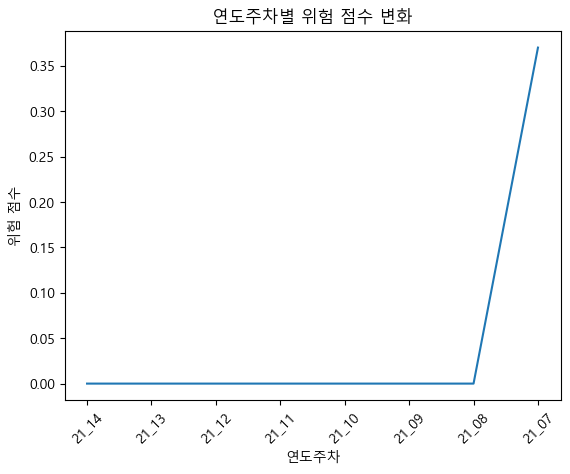

HS Code : 3707901010
19_04주차
0    20173.728
1    20496.747
2    19101.228
3    18561.987
4    19144.031
5    23132.675
6    26499.160
7    24589.869
8    24220.195
9    21052.534
10   22522.304
11   26227.010
12   24903.522
13   20615.000
14   19288.663
15   18193.278
16   18840.737
17   22285.820
18   20773.943
19   20864.880
20   20625.178
21   20649.105
22   22119.247
23   21859.940
24   24197.684
25   23064.973
26   23492.327
27   25873.863
28   23569.524
29   23905.783
30   22048.571
31   23912.596
32   22698.219
33   23856.776
34   21067.980
35   20785.282
36   27609.976
37   27166.385
38   30817.958
39   26050.878
40   22238.050
41   23637.975
42   22112.843
43   23692.447
44   24448.219
45   23265.845
46   26184.196
47   28616.635
48   23505.060
49   23269.247
50   24918.181
51   21452.173
Name: 신고중량, dtype: float64
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
19_03주차
0    15865.119
1    20173.728
2    20496.7

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
18_49주차
0    19185.575
1    22302.226
2    25647.622
3    22179.855
4    22667.052
5    18501.504
6    15865.119
7    20173.728
8    20496.747
9    19101.228
10   18561.987
11   19144.031
12   23132.675
13   26499.160
14   24589.869
15   24220.195
16   21052.534
17   22522.304
18   26227.010
19   24903.522
20   20615.000
21   19288.663
22   18193.278
23   18840.737
24   22285.820
25   20773.943
26   20864.880
27   20625.178
28   20649.105
29   22119.247
30   21859.940
31   24197.684
32   23064.973
33   23492.327
34   25873.863
35   23569.524
36   23905.783
37   22048.571
38   23912.596
39   22698.219
40   23856.776
41   21067.980
42   20785.282
43   27609.976
44   27166.385
45   30817.958
46   26050.878
47   22238.050
48   23637.975
49   22112.843
50   23692.447
51   24448.219
Name: 신고중량, dtype: float64
======================= 여기부터 GARCH 모델링 ================================

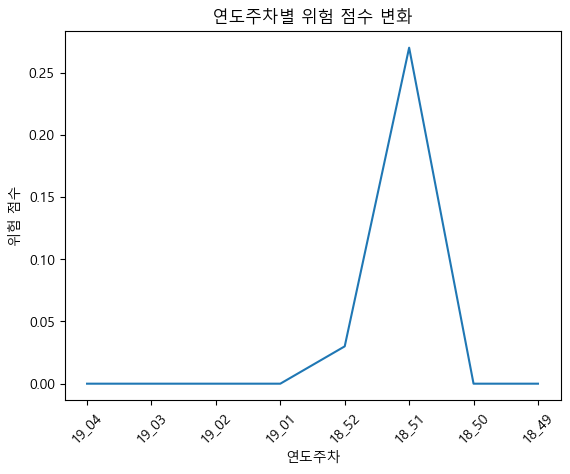

HS Code : 4407191000
20_41주차
0    142855.500
1    167602.578
2    172108.328
3    151083.578
4    195233.725
5    168487.397
6    192482.647
7    201823.397
8    183001.500
9    199930.250
10   172237.330
11   189899.330
12   200884.830
13   214903.655
14   264579.340
15   275269.840
16   236470.223
17   208230.898
18   122825.633
19    91211.383
20    94948.500
21   138382.343
22   188889.978
23   240923.167
24   245405.167
25   255033.016
26   232849.132
27   208142.443
28   212974.443
29   174660.487
30   192153.237
31   174147.462
32   208127.462
33   197927.225
34   169040.725
35   189372.250
36   165649.963
37   171324.713
38   171240.088
39   180231.838
40   141282.547
41   167364.547
42   177168.922
43   156222.672
44   213491.250
45   192786.750
46   188341.750
47   193563.500
48   174705.000
49   172996.750
50   184079.750
51   285911.500
Name: 신고중량, dtype: float64
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast ============

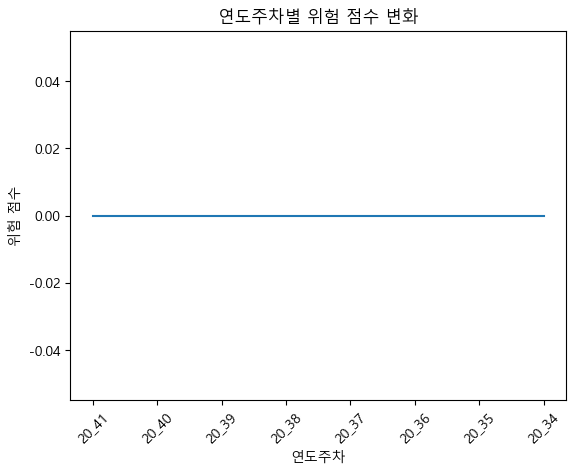

HS Code : 8111000000
21_19주차
0    2411149.567
1    2243092.258
2    2094445.660
3    1657916.090
4    1245858.371
5    1534800.232
6    1307604.550
7    1293489.455
8    1212797.974
9    1030512.490
10   1799550.890
11   1732697.468
12   1666406.519
13   1451579.890
14    881444.005
15   1486463.236
16   1926003.335
17   2151619.315
18   2236845.100
19   1560972.306
20   1526437.145
21   1216028.464
22   1503132.158
23   1716228.895
24   1499314.407
25   1864895.908
26   1838912.570
27   1881359.907
28   2331514.192
29   2123058.496
30   1726439.953
31   2127137.453
32   1450353.759
33   1715679.800
34   1913412.288
35   1845113.619
36   1992666.875
37   1927276.746
38   1775287.477
39   1647085.896
40   2087361.094
41   1930276.436
42   1892042.360
43   2327552.947
44   2080499.897
45   1978193.060
46   2013177.680
47   1261457.280
48   1229109.535
49   1599007.763
50   1391967.667
51   1454628.980
Name: 신고중량, dtype: float64
======================= 여기부터 GARCH 모델링 =====================

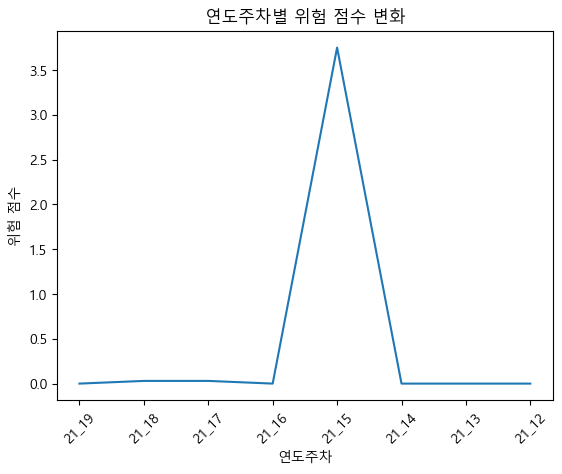

HS Code : 2701129010
21_25주차
0     77669185.200
1    120276473.100
2    144388042.100
3    164400070.350
4    169156920.350
5    155045125.750
6    173889515.750
7    152513175.000
8    157102201.460
9    174937717.460
10   158211262.460
11   222905251.404
12   226670762.444
13   186675146.444
14   187277646.444
15   156835390.000
16   162396417.250
17   158470734.750
18   206851071.829
19   200732196.329
20   230270214.079
21   244174568.017
22   200210940.938
23   189521504.668
24   157750269.985
25   219737703.548
26   225731607.798
27   183787999.567
28   224709651.750
29   202500680.500
30   217664043.000
31   242124105.935
32   234179063.435
33   209051809.935
34   270433729.435
35   246078410.135
36   236893702.635
37   274214557.385
38   221917945.020
39   306853383.385
40   279513383.385
41   233950465.885
42   161579432.000
43   130868025.000
44   197016285.000
45   204183060.500
46   221980002.213
47   208183477.213
48   153015439.713
49   199522831.713
50   238091066.250
51

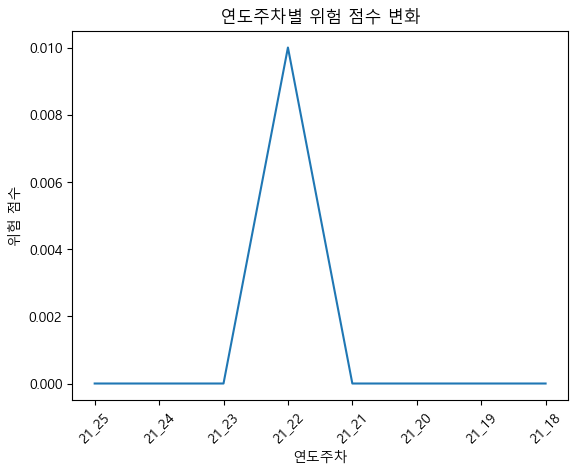

HS Code : 2804701000
21_25주차
0    202037.500
1    194845.000
2    185672.500
3    251832.500
4    203832.500
5    198382.500
6    187587.500
7    154830.000
8    172505.000
9    170010.000
10   193452.500
11   160070.000
12   140782.500
13   170230.000
14   174225.000
15   213700.000
16   257400.000
17   214935.000
18   207790.000
19   216800.000
20   149527.500
21   212565.000
22   203110.000
23   209822.500
24   240420.000
25   253835.025
26   254742.525
27   178310.470
28   196105.482
29   147182.957
30   187867.957
31   262452.513
32   280122.500
33   252057.500
34   253210.000
35   211705.000
36   222757.500
37   283655.000
38   246677.500
39   237352.500
40   224752.500
41   209272.500
42   171292.500
43   187030.000
44   150935.000
45   106027.500
46   161752.750
47   214187.750
48   202865.250
49   249897.750
50   274160.106
51   187000.106
Name: 신고중량, dtype: float64
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast ============

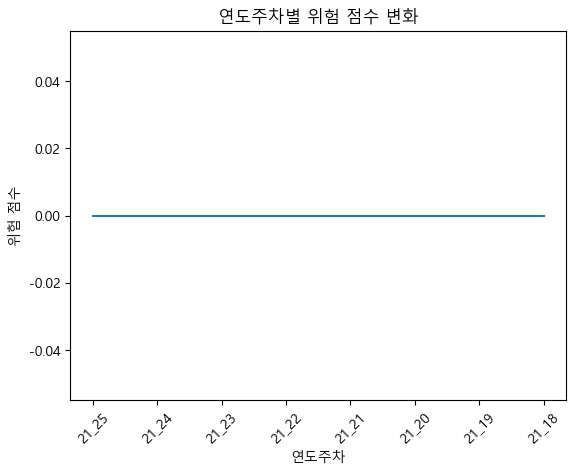

HS Code : 1511901000
21_29주차
0    1262809.750
1     149505.000
2     492634.500
3    1029870.750
4    1029830.375
5    1533380.425
6    1570067.175
7    1172577.175
8    1297327.624
9     787420.574
10    275626.824
11    622862.725
12    801885.201
13    926696.951
14   1303057.951
15   1215280.800
16   1492678.275
17   1375801.525
18    999440.631
19   1263995.631
20    963353.856
21   1457994.656
22   1457994.550
23   1537650.550
24   1535177.550
25   1032601.750
26   1655937.250
27    901391.250
28    973333.000
29   1148300.000
30   1083733.000
31   1088981.800
32    763810.916
33   1151875.166
34   1176337.916
35   1176921.116
36   1216909.500
37    654403.250
38   1242982.505
39   1237151.685
40   1172861.685
41   1246969.185
42    993985.680
43   1034286.500
44   1033762.562
45    959130.562
46    998984.062
47    958687.062
48   1065545.500
49   1065545.000
50    106864.500
51    505444.000
Name: 신고중량, dtype: float64
======================= 여기부터 GARCH 모델링 =====================

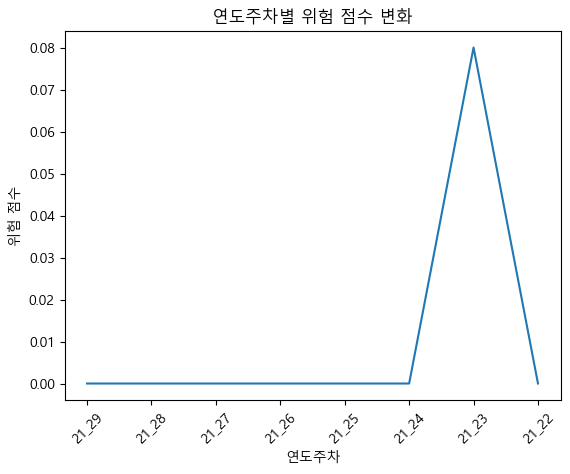

HS Code : 305531000
21_34주차
0    156099.745
1    164037.820
2    163524.378
3    155503.128
4    141043.857
5    139208.357
6    138356.500
7    163140.750
8    196490.750
9    203363.500
10   196634.500
11   166431.098
12   157746.348
13   151943.742
14   153117.812
15   168043.858
16   182001.148
17   188950.253
18   180399.433
19   177167.290
20   144132.675
21   127121.125
22   144520.875
23   123379.325
24   127691.400
25   109895.575
26    94605.349
27   119550.149
28   125476.449
29   146197.870
30   150753.546
31   140290.640
32   128867.112
33   114120.290
34   106992.423
35   101408.020
36   121817.874
37   125381.400
38   152749.953
39   164129.761
40   156312.136
41   155368.886
42   131997.200
43   147524.700
44   141420.950
45   163775.950
46   152476.650
47   135051.675
48   136310.425
49   121478.925
50   122820.025
51   123487.025
Name: 신고중량, dtype: float64
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_27주차
0    198650.110
1    186890.635
2    175611.750
3    190122.250
4    165617.925
5    167957.725
6    168123.475
7    156099.745
8    164037.820
9    163524.378
10   155503.128
11   141043.857
12   139208.357
13   138356.500
14   163140.750
15   196490.750
16   203363.500
17   196634.500
18   166431.098
19   157746.348
20   151943.742
21   153117.812
22   168043.858
23   182001.148
24   188950.253
25   180399.433
26   177167.290
27   144132.675
28   127121.125
29   144520.875
30   123379.325
31   127691.400
32   109895.575
33    94605.349
34   119550.149
35   125476.449
36   146197.870
37   150753.546
38   140290.640
39   128867.112
40   114120.290
41   106992.423
42   101408.020
43   121817.874
44   125381.400
45   152749.953
46   164129.761
47   156312.136
48   155368.886
49   131997.200
50   147524.700
51   141420.950
Name: 신고중량, dtype: float64
===================

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


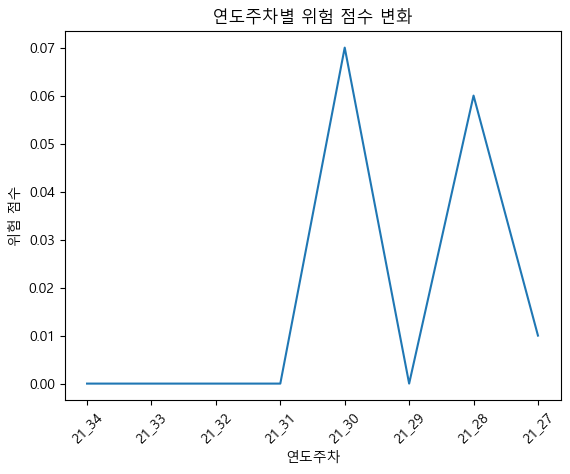

HS Code : 302140000
21_35주차
0    432161.413
1    457808.887
2    494310.018
3    518436.598
4    520939.741
5    515701.217
6    509818.949
7    509845.362
8    511369.361
9    511072.253
10   511432.891
11   516992.998
12   505040.093
13   514337.020
14   515077.465
15   554803.830
16   590383.615
17   599942.585
18   594274.117
19   564973.938
20   556900.944
21   560299.449
22   559853.442
23   567748.774
24   588090.171
25   590361.155
26   615575.662
27   615668.297
28   608740.494
29   627113.382
30   585409.915
31   590562.853
32   581756.949
33   566239.359
34   605266.935
35   607921.714
36   610291.216
37   587542.344
38   568714.768
39   554575.273
40   548016.885
41   551181.215
42   555615.528
43   545638.383
44   529042.071
45   525406.401
46   509545.128
47   500883.440
48   518561.440
49   510946.748
50   514015.178
51   528387.253
Name: 신고중량, dtype: float64
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_29주차
0    431053.489
1    430721.924
2    441177.274
3    439893.064
4    441531.940
5    429810.985
6    432161.413
7    457808.887
8    494310.018
9    518436.598
10   520939.741
11   515701.217
12   509818.949
13   509845.362
14   511369.361
15   511072.253
16   511432.891
17   516992.998
18   505040.093
19   514337.020
20   515077.465
21   554803.830
22   590383.615
23   599942.585
24   594274.117
25   564973.938
26   556900.944
27   560299.449
28   559853.442
29   567748.774
30   588090.171
31   590361.155
32   615575.662
33   615668.297
34   608740.494
35   627113.382
36   585409.915
37   590562.853
38   581756.949
39   566239.359
40   605266.935
41   607921.714
42   610291.216
43   587542.344
44   568714.768
45   554575.273
46   548016.885
47   551181.215
48   555615.528
49   545638.383
50   529042.071
51   525406.401
Name: 신고중량, dtype: float64
===================

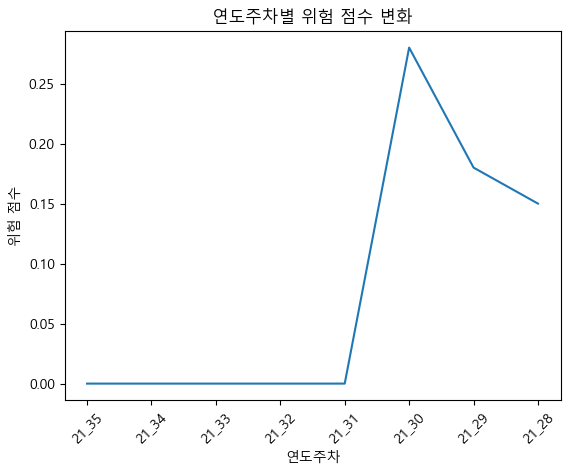

HS Code : 1003901000
21_34주차
0     540667.500
1     540667.500
2    1053037.750
3    1170537.750
4     639870.250
5     639870.250
6     117500.000
7      56103.500
8      56103.500
9     263538.500
10    528096.500
11    679440.500
12   1055146.750
13    951616.750
14    842628.525
15    947456.025
16    881299.775
17    984647.275
18    932840.000
19    620565.000
20    727777.500
21    520525.000
22    624857.500
23    833205.000
24    623622.500
25    932005.000
26    828835.000
27    717547.500
28    615187.500
29    411495.000
30    364135.000
31    267075.000
32    417842.500
33    604052.500
34    648885.000
35    808762.000
36    630552.000
37    520297.000
38    703284.500
39    697550.000
40    855198.250
41    934663.250
42    959354.500
43    805212.000
44    841536.250
45    820790.750
46    843592.000
47   1156483.500
48   1040701.000
49   1188999.000
50    856121.500
51    699435.000
Name: 신고중량, dtype: float64
======================= 여기부터 GARCH 모델링 =====================

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_30주차
0     711732.750
1     506892.750
2     214265.250
3      10000.250
4     540667.500
5     540667.500
6    1053037.750
7    1170537.750
8     639870.250
9     639870.250
10    117500.000
11     56103.500
12     56103.500
13    263538.500
14    528096.500
15    679440.500
16   1055146.750
17    951616.750
18    842628.525
19    947456.025
20    881299.775
21    984647.275
22    932840.000
23    620565.000
24    727777.500
25    520525.000
26    624857.500
27    833205.000
28    623622.500
29    932005.000
30    828835.000
31    717547.500
32    615187.500
33    411495.000
34    364135.000
35    267075.000
36    417842.500
37    604052.500
38    648885.000
39    808762.000
40    630552.000
41    520297.000
42    703284.500
43    697550.000
44    855198.250
45    934663.250
46    959354.500
47    805212.000
48    841536.250
49    820790.750
50    843592.000
51   115648

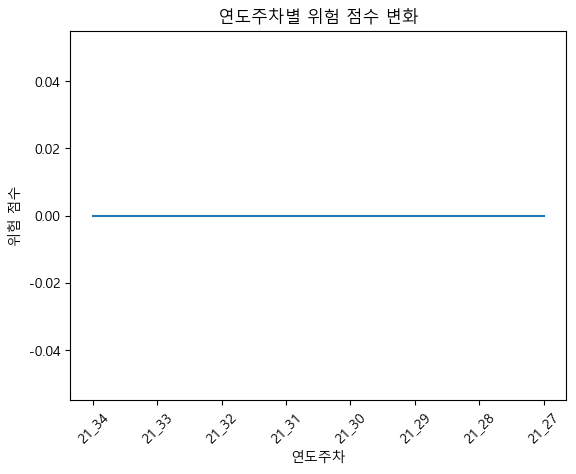

HS Code : 1003902000
21_34주차
0     108114.500
1      80120.000
2     154445.000
3     149445.000
4     100475.000
5     100450.000
6      26125.000
7      56032.500
8      83782.500
9     161507.500
10    167257.500
11    189280.000
12    161530.000
13    109610.000
14    131335.000
15    199960.000
16    227122.500
17    175192.500
18    255790.000
19    135235.000
20    153807.500
21    998147.500
22   3067715.000
23   3253485.000
24   3652617.500
25   2992217.500
26    869097.500
27    683327.500
28    269977.500
29    164995.000
30    298164.750
31    298164.750
32    266651.000
33    235016.000
34    249818.000
35    249818.000
36    249814.250
37    376146.750
38    252635.000
39    380320.000
40    380320.000
41    357498.000
42    360203.750
43    232518.975
44    232518.975
45    156960.975
46    225107.725
47    278897.500
48    278897.500
49    229272.500
50     96159.750
51     42369.750
Name: 신고중량, dtype: float64
======================= 여기부터 GARCH 모델링 =====================

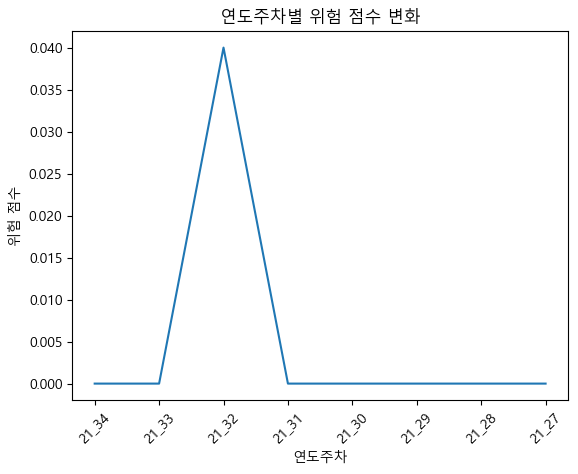

HS Code : 1104230000
21_34주차
0    294500.625
1    384750.000
2    429250.000
3    516750.612
4    491500.612
5    562650.613
6    560900.613
7    502150.000
8    432400.000
9    332750.500
10   256750.500
11   180500.500
12   217313.000
13   112812.500
14    79567.800
15    36817.800
16       12.050
17       24.725
18   365769.425
19   498780.800
20   577286.988
21   667524.312
22   368274.537
23   235263.788
24   449250.850
25   359001.392
26   432751.167
27   475500.542
28   323250.542
29   405750.000
30   345500.125
31   364500.125
32   295501.375
33   255501.375
34   341751.250
35   467001.250
36   424251.000
37   394501.000
38   285251.000
39    98251.000
40   131500.000
41   213750.000
42   237500.000
43   266000.000
44   300750.000
45   262750.000
46   206000.000
47   353250.000
48   485000.000
49   442250.000
50   418250.000
51   399250.000
Name: 신고중량, dtype: float64
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast ============

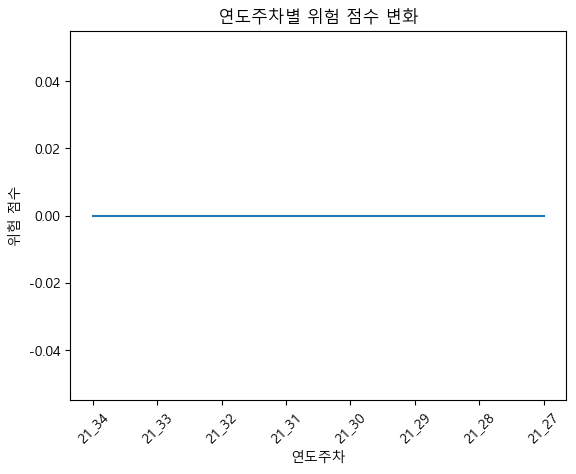

HS Code : 2710121000
21_34주차
0     2512617.750
1     3666846.750
2    10449924.250
3    11686274.025
4     9174659.025
5    10728342.025
6     6959541.775
7    10025896.500
8    10462598.000
9     7754686.000
10    6958469.125
11    4186783.455
12    6381777.955
13   10343325.705
14    9071506.830
15    7539637.250
16    4907941.250
17    1940405.750
18    3015398.500
19    3015246.500
20    7815153.500
21   10787000.250
22    8765766.000
23   15930045.000
24   11130138.000
25   12556530.250
26   12704250.250
27    5539971.250
28    5569408.000
29     177156.750
30    1138045.250
31    7136791.200
32    8301232.700
33   11013298.730
34   14520791.730
35    8523733.280
36   11248927.030
37    8536861.000
38    3920911.075
39    4805742.575
40    3517106.575
41    4965419.825
42    4965268.250
43    4274324.250
44    1866883.750
45     418570.500
46    1410867.750
47    9980065.750
48   10202026.250
49   10202026.250
50    9209729.000
51     444956.000
Name: 신고중량, dtype: float64
========

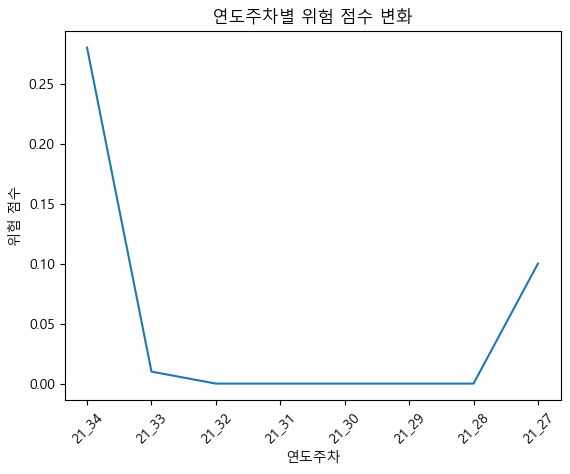

HS Code : 3104200000
21_34주차
0     7729349.763
1     7679388.240
2     8524892.264
3     8463893.514
4     8984880.827
5     9816516.402
6     8973060.845
7     8956468.158
8      841401.158
9    15676446.743
10   17504398.025
11   17535235.902
12   17657580.584
13    2015822.659
14    1023508.009
15   10098557.994
16    9985289.768
17   12138499.133
18   19295637.995
19   10245594.258
20   11439086.318
21   10078878.595
22   17623980.602
23   18941973.165
24   19154089.112
25   26388053.882
26   10848408.987
27   10939364.025
28   17474054.190
29    9429601.715
30   23952649.830
31   23754948.883
32   16850661.767
33   17458618.276
34    3554086.133
35   12218383.606
36   12107366.281
37   11516935.784
38   10898136.424
39    2380387.074
40   12491971.349
41   13279410.200
42   21462436.948
43   21448138.023
44   18889077.523
45   32493832.810
46   27363068.125
47   28248164.212
48   19755683.589
49   12855464.362
50   11266343.705
51    8980520.543
Name: 신고중량, dtype: float64
========

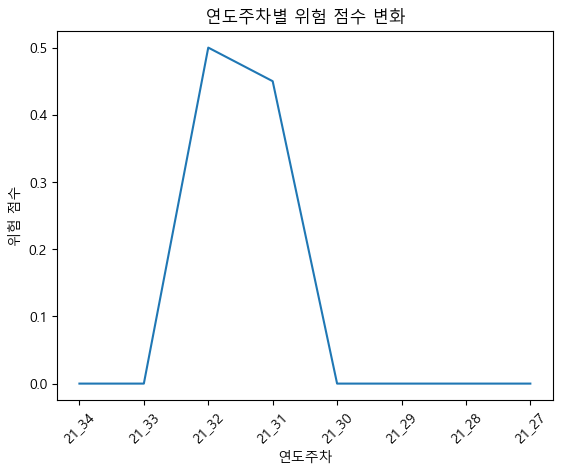

HS Code : 2905172000
21_43주차
0     96282.475
1     85889.725
2     91147.250
3     98423.050
4     81478.300
5     78796.050
6     83173.275
7     87809.250
8     68608.075
9     80663.725
10    66336.850
11    49280.600
12    73217.605
13    71739.255
14    70456.130
15    79374.883
16    70663.053
17    73585.628
18    86598.553
19   112124.425
20   114662.050
21   105335.050
22    90309.875
23    77989.250
24    59863.625
25   102581.150
26   104593.403
27   103831.328
28   105693.828
29    74423.258
30    78403.830
31    91800.905
32    79802.405
33    68082.700
34    95649.625
35    88584.375
36   110632.875
37   104293.025
38   106678.025
39    75903.300
40    97053.180
41   122183.780
42    87141.280
43   103501.257
44    70622.625
45    58022.625
46    50237.625
47    52562.625
48    61041.878
49    82435.753
50    99243.253
51    89308.001
Name: 신고중량, dtype: float64
======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast ============

c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\happyfamily\anaconda3\envs\gogo\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


======================= 여기부터 GARCH 모델링 =================================
=========== GARCH forecast =============
21_37주차
0     41353.026
1     36302.776
2     28702.776
3     29277.750
4     48503.000
5     54228.725
6     96282.475
7     85889.725
8     91147.250
9     98423.050
10    81478.300
11    78796.050
12    83173.275
13    87809.250
14    68608.075
15    80663.725
16    66336.850
17    49280.600
18    73217.605
19    71739.255
20    70456.130
21    79374.883
22    70663.053
23    73585.628
24    86598.553
25   112124.425
26   114662.050
27   105335.050
28    90309.875
29    77989.250
30    59863.625
31   102581.150
32   104593.403
33   103831.328
34   105693.828
35    74423.258
36    78403.830
37    91800.905
38    79802.405
39    68082.700
40    95649.625
41    88584.375
42   110632.875
43   104293.025
44   106678.025
45    75903.300
46    97053.180
47   122183.780
48    87141.280
49   103501.257
50    70622.625
51    58022.625
Name: 신고중량, dtype: float64
===================

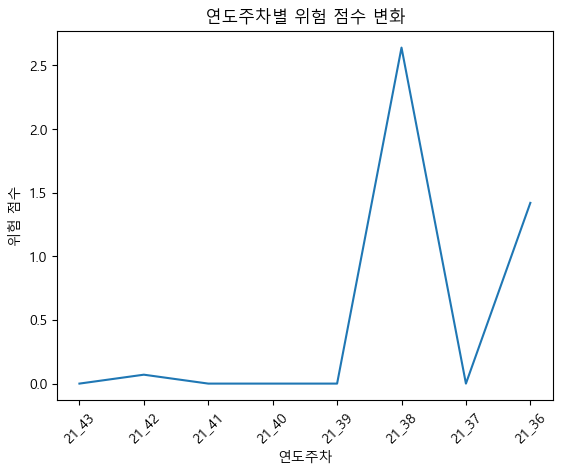

[0, 0, 0, np.float64(0.43), 0, 0, 0, np.float64(0.03), 0, np.float64(0.2), np.float64(0.05), 0, np.float64(4.29), 0, np.float64(0.05), 0, 0, np.float64(4.66), np.float64(0.1), 0, np.float64(0.12), 0, np.float64(0.56), 0, 0, 0, np.float64(0.04), np.float64(0.01), 0, 0, 0, np.float64(0.02), np.float64(0.19), 0, 0, np.float64(0.37), np.float64(0.27), 0, np.float64(3.75), np.float64(0.01), 0, np.float64(0.08), np.float64(0.07), np.float64(0.28), 0, np.float64(0.04), 0, np.float64(0.28), np.float64(0.5), np.float64(2.64)]
[0, 0, 0, 48, 0, 0, 0, 44, 0, 48, 48, 0, 45, 0, 44, 0, 0, 43, 46, 0, 43, 0, 48, 0, 0, 0, 47, 46, 0, 0, 0, 46, 44, 0, 0, 84, 197, 0, 76, 69, 0, 68, 61, 61, 0, 59, 0, 57, 59, 53]
DataFrame 길이: 15
리스트 k 길이: 50


In [3]:
리스트 = pd.read_excel('c:\python\list(m).xlsx')
추출용 = 리스트.iloc[:,0].tolist()
리스트 = pd.read_excel('c:\python\list(m1).xlsx')
b = 리스트.iloc[:,0].tolist()

z = []
c = []
e = []
k = []
o = []
z_x = []
z_y = []

for i in range(0, len(추출용)):
  z.append(0) # 품목별 Highest CV를 반영하기 위해 List 생성
  c.append(0) # 품목별 CV값이 임계값 이상인 경우의 횟수를 반영하기 위한 List 생성
  k.append(0) # 임계값을 넘는 횟수
  o.append(0) # 위험경보 여부
  z_x.append(0) # Highest CV의 X값
  z_y.append(0) # Highest CV의 y값

for i in range(0, 8):
  e.append(0) # 품목별 8주간 CV값을 반영하기 위한 List 생성성
  
j = 0

for i in 추출용:
    print(f'HS Code : {i}')
    original[original['HS10단위부호'] == str(i)].sort_values(by = '수리일자', ascending = False)
    data = pd.DataFrame(columns = use_col)
    data = pd.concat([data, original[original['HS10단위부호'] == str(i)]])
    data = data.reset_index(drop=True)

    data = data.sort_values(by='수리일자', ascending=True).reset_index(drop=True)
    
    #
    ## 최근 52주간 수입단가(직전4주평균) 추이 파악
    #
    df_price = data[['연도주차', '과세가격미화금액', '신고중량']]
    df_price_week = df_price.groupby('연도주차')[['과세가격미화금액', '신고중량']].agg(['sum']).reset_index()
    df_price_week.columns = ['연도주차', '과세가격미화금액', '신고중량']


    # 수입이 없는 주차의 값을 0으로 생성
    df_price_week_hole = pd.DataFrame(columns = df_price_week.columns)
    for wk in set(date_index) - set(df_price_week['연도주차'].unique()):
        df_price_week_hole = pd.concat([df_price_week_hole, pd.DataFrame([{'연도주차': wk, '과세가격미화금액': 0, '신고중량': 0}])], ignore_index=True)
    df_price_week_total = pd.concat([df_price_week, df_price_week_hole]).sort_values('연도주차')

    # 해당 주차의 데이터를 직전 4주간 평균으로 대체
    price_w4 = []
    kg_w4 = []
    for x in range(0, len(df_price_week_total) - 3):
        price_w4.append(df_price_week_total[['과세가격미화금액']].iloc[x : x + 4].mean().iloc[0])
        kg_w4.append(df_price_week_total[['신고중량']].iloc[x : x + 4].mean().iloc[0])
    df_price_4w = df_price_week_total[3:]
    df_price_4w['과세가격미화금액'] = price_w4
    df_price_4w['신고중량'] = kg_w4
    df_price_4w = df_price_4w.reset_index(drop = True)
    df_price_4w['과세가격미화금액'] = df_price_4w['과세가격미화금액'].replace(0, np.nan).ffill()
    df_price_4w['신고중량'] = df_price_4w['신고중량'].replace(0, np.nan).ffill()
    df_price_4w['단가'] = df_price_4w['과세가격미화금액'] / df_price_4w['신고중량']
    df_price_4w = df_price_4w[['연도주차', '단가', '신고중량']]

    

    for l in range(b[j]-8,b[j]):

        print(df_price_4w['연도주차'].iloc[-1-l] + '주차')
        #=================== 단가 percertile 구하기 ====================
        data_mean = df_price_4w.iloc[p_eriod-l:-l]['단가'].mean()
        data_std = df_price_4w.iloc[p_eriod-l:-l]['단가'].std()
        stand_quant = (df_price_4w.iloc[-1-l]['단가'] - data_mean) / data_std
        y=np.exp((scipy.stats.norm.cdf(stand_quant)*100 - 95)*np.log(5)/5)


      #=================== 신고중량 ======================
        res_resid = df_price_4w['신고중량'].iloc[p_eriod-l:-l]
        res_resid = res_resid.reset_index(drop=True)
        
        print(res_resid)
        n_test = 1
        
        train_y, test_y = res_resid[:-n_test], res_resid[-n_test:]

        model = SARIMAX(train_y, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12), 
                        enforce_stationarity=False, enforce_invertibility=False)
        model_fit = model.fit(disp=False)
        forecast1 = model_fit.forecast(steps=1)
                
        print('======================= 여기부터 GARCH 모델링 =================================')
        est_residuals = model_fit.resid
        # NaN 또는 inf가 있는 경우 제거하거나 대체
        est_residuals = est_residuals.replace([np.inf, -np.inf], np.nan)
        est_residuals = est_residuals.dropna()

        # GARCH에 적용
        if len(est_residuals) > 0:
            garch = arch.arch_model(est_residuals, vol="GARCH", p=1, q=1)
            garch_fit = garch.fit(disp="off", options={"maxiter": 1000})
        else:
            print("⚠ GARCH 입력 데이터가 부족합니다. 모델링 생략")
        
        print('=========== GARCH forecast =============')
        garch_forecast = garch_fit.forecast(horizon = n_test, reindex=True)
        garch_std = np.sqrt(garch_forecast.variance.iloc[-1,0])
        stand_quant = (test_y.iloc[0] - forecast1.iloc[0])/ garch_std

        if(scipy.stats.norm.cdf(stand_quant)>0.5):
            x=np.exp((scipy.stats.norm.cdf(stand_quant)*100 - 95)*np.log(5)/5)
        else:
            x=np.exp(((1-scipy.stats.norm.cdf(stand_quant))*100 - 95)*np.log(5)/5)
        
        e[(l-b[j]+8)] = round(2/(1/y+1/x), 2)
        if(round(2/(1/y+1/x), 2)>1.85):
            k[j] += 1
        if(z[j] < round(2/(1/y+1/x), 2)):
            z[j] = round(2/(1/y+1/x), 2)
            c[j] = l
            
        if(z_x[j] < x):
            z_x[j] = x
            
        if(z_y[j] < y):
            z_y[j] = y
      
    if(z[j]<1.85):
        o[j] = 1
 
    import matplotlib.font_manager as fm

    plt.rc('font', family='Malgun Gothic')  # Windows (맑은 고딕)
    plt.rc('axes', unicode_minus=False)  # 마이너스(-) 기호 깨짐 방지
    
    x_labels = [df_price_4w['연도주차'].iloc[-1-l] for l in range(b[j]-8,b[j])]  # x축 라벨 생성
    plt.plot(x_labels, e)  # x축을 연도주차 값으로 설정
    plt.xticks(rotation=45)  # x축 라벨 회전 (가독성 개선)
    plt.xlabel("연도주차")  # x축 제목 추가
    plt.ylabel("위험 점수")  # y축 제목 추가
    plt.title("연도주차별 위험 점수 변화")  # 그래프 제목 추가
    plt.show()
    
    j += 1
print(z)
print(c)

print("DataFrame 길이:", len(collect['Model0(1)'].iloc[:-1]))
print("리스트 k 길이:", len(k))

# 구글드라이브에 있는 엑셀 파일을 불러와서 점수결과 저장하기
collect = pd.read_excel('c:\python\Compare_Models50.xlsx', sheet_name="점수")
collect = pd.DataFrame(collect)
collect.loc[:49, 'Model17(1)'] = o
collect.loc[50, 'Model17(1)'] = np.sum(o)
collect.loc[:49, 'Model17(2)'] = z
collect.loc[50, 'Model17(2)'] = np.mean(z)
collect.to_excel('c:\python\Compare_Models50.xlsx', sheet_name="점수", index=False)

collect1 = pd.read_excel('c:\python\Collectroc(t).xlsx', sheet_name="점수")
collect1 = pd.DataFrame(collect1)
collect1.loc[15:65, 'y_scores[18]'] = z
collect1.to_excel('c:\python\Collectroc(t).xlsx', sheet_name="점수", index=False)

collect2 = pd.read_excel('c:\python\Collectroc(x).xlsx', sheet_name="점수")
collect2 = pd.DataFrame(collect2)
collect2.loc[15:65, 'y_scores[18]'] = z_x
collect2.to_excel('c:\python\Collectroc(x).xlsx', sheet_name="점수", index=False)

collect3 = pd.read_excel('c:\python\Collectroc(y).xlsx', sheet_name="점수")
collect3 = pd.DataFrame(collect3)
collect3.loc[15:65, 'y_scores[18]'] = z_y
collect3.to_excel('c:\python\Collectroc(y).xlsx', sheet_name="점수", index=False)